In [13]:
import os
import pandas as pd
import numpy as np


In [14]:
from datetime import date

todays_date = str(date.today())
print(todays_date)

2026-09-29


In [3]:
pwd

'/Users/asjaeger/Desktop/project_source/hpai-PA/comm-pa/comm_scripts'

In [15]:
vars = pd.read_csv('../all_com_analysis_2pct/data/variants.tsv', sep = '\t')

In [16]:
vars['sample'].unique()

array(['c_com1', 'c_com2', 'c_com3', 'c_com5', 'c_com6', 'c_lbm10',
       'c_lbm11', 'c_lbm1', 'c_lbm2', 'c_lbm3', 'c_lbm5', 'c_lbm6',
       'c_lbm7', 'c_lbm8', 'c_lbm9', 'cb_com1', 'cb_com2', 'cb_com3',
       'cb_com4', 'ckr_com1', 'ckr_com2', 'ckr_com3', 'ckr_lbm1',
       'd_com1', 'd_com2', 'd_com3', 'd_lbm1', 'd_lbm2', 'd_lbm3',
       'd_lbm4', 'g_com1', 'g_com2', 'g_lbm1', 'gn_lbm1', 'kc_com1',
       'kc_com2', 'kc_com3', 'kc_com4', 'kc_com5', 'kc_com6', 'kc_com7',
       'kc_com8'], dtype=object)

In [17]:
#input gene for NA which got misread as an Nan
vars.loc[vars['segment'] == 'na', 'gene'] = 'NA'

In [18]:
vars['amino_acid'] = vars['coding_region_change'].str.extract('(\d+)')

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
/var/folders/8h/zkgpnzwj7f9d82wldp_d4h_w0000gs/T/ipykernel_26043/308163358.py:1: SyntaxWarning: invalid escape sequence '\d'
  vars['amino_acid'] = vars['coding_region_change'].str.extract('(\d+)')


In [19]:
vars

,segment,position,allele,coding_region_change,gene,Frequency_1,Frequency_2,sample,amino_acid
0,ha,438,C,Ser137Phe,HA,0.0298,0.0000,c_com1,137
1,ha,524,C,Leu166Ile,HA,0.0000,0.0347,c_com1,166
2,ha,622,C,Asn198Asn,HA,0.0000,0.0231,c_com1,198
3,ha,763,C,Phe245Leu,HA,0.0826,0.0000,c_com1,245
4,ha,785,G,Asp253Asn,HA,0.0000,0.0382,c_com1,253
...,...,...,...,...,...,...,...,...,...
1162,pb1,1752,G,Leu576Leu,PB1,0.0723,0.0000,kc_com8,576
1163,pb1,1905,C,Pro627Pro,PB1,0.0907,0.0000,kc_com8,627
1164,pb1,2119,T,Phe699Leu,PB1,0.1400,0.0000,kc_com8,699
1165,pb2,1101,G,Glu358Glu,PB2,0.0319,0.0000,kc_com8,358


In [20]:
##for removing any variants associated with potential contamination in NCs
##for these samples, that is: c_com1, c_com2, c_com3 in the PA segment region 999-2233
mask = (
    vars["sample"].isin(["c_com1", "c_com2", "c_com3"]) &
    (vars["segment"] == "pa") &
    vars["position"].between(999, 2233)
)

vars = vars[~mask]

##print to see that this should've excluded 8 rows
vars

,segment,position,allele,coding_region_change,gene,Frequency_1,Frequency_2,sample,amino_acid
0,ha,438,C,Ser137Phe,HA,0.0298,0.0000,c_com1,137
1,ha,524,C,Leu166Ile,HA,0.0000,0.0347,c_com1,166
2,ha,622,C,Asn198Asn,HA,0.0000,0.0231,c_com1,198
3,ha,763,C,Phe245Leu,HA,0.0826,0.0000,c_com1,245
4,ha,785,G,Asp253Asn,HA,0.0000,0.0382,c_com1,253
...,...,...,...,...,...,...,...,...,...
1162,pb1,1752,G,Leu576Leu,PB1,0.0723,0.0000,kc_com8,576
1163,pb1,1905,C,Pro627Pro,PB1,0.0907,0.0000,kc_com8,627
1164,pb1,2119,T,Phe699Leu,PB1,0.1400,0.0000,kc_com8,699
1165,pb2,1101,G,Glu358Glu,PB2,0.0319,0.0000,kc_com8,358


In [21]:
# #make merged column for gene and its position
vars['gene_pos'] = vars['gene'] + "_" + vars['amino_acid'].astype(str)


/var/folders/8h/zkgpnzwj7f9d82wldp_d4h_w0000gs/T/ipykernel_26043/147877009.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  vars['gene_pos'] = vars['gene'] + "_" + vars['amino_acid'].astype(str)


In [22]:
vars['sample_var'] = vars['sample'] + "_" + vars['gene_pos'].astype(str)


/var/folders/8h/zkgpnzwj7f9d82wldp_d4h_w0000gs/T/ipykernel_26043/3735607045.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  vars['sample_var'] = vars['sample'] + "_" + vars['gene_pos'].astype(str)


In [23]:
vars['syn_non'] = vars['coding_region_change'].apply(
    lambda x: 'synonymous' if x[:3] == x[-3:] else 'nonsynonymous'
)
vars

/var/folders/8h/zkgpnzwj7f9d82wldp_d4h_w0000gs/T/ipykernel_26043/3676224623.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  vars['syn_non'] = vars['coding_region_change'].apply(


,segment,position,allele,coding_region_change,gene,Frequency_1,Frequency_2,sample,amino_acid,gene_pos,sample_var,syn_non
0,ha,438,C,Ser137Phe,HA,0.0298,0.0000,c_com1,137,HA_137,c_com1_HA_137,nonsynonymous
1,ha,524,C,Leu166Ile,HA,0.0000,0.0347,c_com1,166,HA_166,c_com1_HA_166,nonsynonymous
2,ha,622,C,Asn198Asn,HA,0.0000,0.0231,c_com1,198,HA_198,c_com1_HA_198,synonymous
3,ha,763,C,Phe245Leu,HA,0.0826,0.0000,c_com1,245,HA_245,c_com1_HA_245,nonsynonymous
4,ha,785,G,Asp253Asn,HA,0.0000,0.0382,c_com1,253,HA_253,c_com1_HA_253,nonsynonymous
...,...,...,...,...,...,...,...,...,...,...,...,...
1162,pb1,1752,G,Leu576Leu,PB1,0.0723,0.0000,kc_com8,576,PB1_576,kc_com8_PB1_576,synonymous
1163,pb1,1905,C,Pro627Pro,PB1,0.0907,0.0000,kc_com8,627,PB1_627,kc_com8_PB1_627,synonymous
1164,pb1,2119,T,Phe699Leu,PB1,0.1400,0.0000,kc_com8,699,PB1_699,kc_com8_PB1_699,nonsynonymous
1165,pb2,1101,G,Glu358Glu,PB2,0.0319,0.0000,kc_com8,358,PB2_358,kc_com8_PB2_358,synonymous


In [24]:
ct_df= pd.read_csv('../sample_data/PA_samples_seqd_throughrun10.tsv', sep='\t')
# Remove '_R1' from the 'sample' column
ct_df['sample_ID'] = ct_df['sample_ID'].str.lower()

ct_df

,sample_species,domestic_status,county,date_collected,ct_value,sample_ID,seq_run1,seq_run2
0,Khaki Campbell,commercial,Chester,2/23/23,17.72,kc_com1,4,8
1,chicken broiler,commercial,Chester,2/23/23,18.76,cb_com1,4,8
2,Khaki Campbell,commercial,Chester,2/23/23,20.06,kc_com2,4,8
3,chicken broiler,commercial,Chester,2/23/23,20.28,cb_com2,4,8
4,Gray Fox,wild,unknown,4/2/23,12.91,gf_w,4,6
...,...,...,...,...,...,...,...,...
80,black vulture,wild,Lehigh,6/2/25,28.47,bv_w10,10,NaN
81,black vulture,wild,Lehigh,6/2/25,28.04,bv_w11,10,NaN
82,chicken,commercial,unknown,1/26/25,23.14,c_com4,10,NaN
83,chicken,commercial,unknown,1/26/25,22.01,c_com5,10,NaN


In [25]:
ct_df['domestic_status'] = ct_df['domestic_status'].str.replace('^commercial_', '', regex=True)
# ct_df = ct_df[ct_df['domestic_status'] != "wild"]
ct_df

,sample_species,domestic_status,county,date_collected,ct_value,sample_ID,seq_run1,seq_run2
0,Khaki Campbell,commercial,Chester,2/23/23,17.72,kc_com1,4,8
1,chicken broiler,commercial,Chester,2/23/23,18.76,cb_com1,4,8
2,Khaki Campbell,commercial,Chester,2/23/23,20.06,kc_com2,4,8
3,chicken broiler,commercial,Chester,2/23/23,20.28,cb_com2,4,8
4,Gray Fox,wild,unknown,4/2/23,12.91,gf_w,4,6
...,...,...,...,...,...,...,...,...
80,black vulture,wild,Lehigh,6/2/25,28.47,bv_w10,10,NaN
81,black vulture,wild,Lehigh,6/2/25,28.04,bv_w11,10,NaN
82,chicken,commercial,unknown,1/26/25,23.14,c_com4,10,NaN
83,chicken,commercial,unknown,1/26/25,22.01,c_com5,10,NaN


In [26]:
vars = vars.merge(ct_df[['sample_ID', 'domestic_status', 'ct_value']], 
                        left_on='sample',
                          right_on='sample_ID',
                        how='left')  
vars = vars[vars['domestic_status'] != "wild"]

vars
##need to move this code with the dom_stat up so i can filter beofre looking at shared v single variants comm only!

,segment,position,allele,coding_region_change,gene,Frequency_1,Frequency_2,sample,amino_acid,gene_pos,sample_var,syn_non,sample_ID,domestic_status,ct_value
0,ha,438,C,Ser137Phe,HA,0.0298,0.0000,c_com1,137,HA_137,c_com1_HA_137,nonsynonymous,c_com1,commercial,28.72
1,ha,524,C,Leu166Ile,HA,0.0000,0.0347,c_com1,166,HA_166,c_com1_HA_166,nonsynonymous,c_com1,commercial,28.72
2,ha,622,C,Asn198Asn,HA,0.0000,0.0231,c_com1,198,HA_198,c_com1_HA_198,synonymous,c_com1,commercial,28.72
3,ha,763,C,Phe245Leu,HA,0.0826,0.0000,c_com1,245,HA_245,c_com1_HA_245,nonsynonymous,c_com1,commercial,28.72
4,ha,785,G,Asp253Asn,HA,0.0000,0.0382,c_com1,253,HA_253,c_com1_HA_253,nonsynonymous,c_com1,commercial,28.72
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1154,pb1,1752,G,Leu576Leu,PB1,0.0723,0.0000,kc_com8,576,PB1_576,kc_com8_PB1_576,synonymous,kc_com8,commercial,27.29
1155,pb1,1905,C,Pro627Pro,PB1,0.0907,0.0000,kc_com8,627,PB1_627,kc_com8_PB1_627,synonymous,kc_com8,commercial,27.29
1156,pb1,2119,T,Phe699Leu,PB1,0.1400,0.0000,kc_com8,699,PB1_699,kc_com8_PB1_699,nonsynonymous,kc_com8,commercial,27.29
1157,pb2,1101,G,Glu358Glu,PB2,0.0319,0.0000,kc_com8,358,PB2_358,kc_com8_PB2_358,synonymous,kc_com8,commercial,27.29


In [27]:
vars['sample'].nunique()

42

In [177]:
# ##because of some misformatting of sample ids, these 2 slip through the cracks so dropping manually
# # Define the values to drop
# values_to_drop = ['be_w1', 'gf_w1']

# # Drop rows where 'column_name' is in the values_to_drop list
# # The tilde (~) operator negates the condition, keeping rows NOT in the list
# vars = vars[~vars['sample'].isin(values_to_drop)]

In [178]:
# vars['sample'].unique()

array(['c_com1', 'c_com2', 'c_com3', 'c_com5', 'c_com6', 'c_lbm10',
       'c_lbm11', 'c_lbm1', 'c_lbm2', 'c_lbm3', 'c_lbm5', 'c_lbm6',
       'c_lbm7', 'c_lbm8', 'c_lbm9', 'cb_com1', 'cb_com2', 'cb_com3',
       'cb_com4', 'ckr_com1', 'ckr_com2', 'ckr_com3', 'ckr_lbm1',
       'd_com1', 'd_com2', 'd_com3', 'd_lbm1', 'd_lbm2', 'd_lbm3',
       'd_lbm4', 'g_com1', 'g_com2', 'g_lbm1', 'gn_lbm1', 'kc_com1',
       'kc_com2', 'kc_com3', 'kc_com4', 'kc_com5', 'kc_com6', 'kc_com7',
       'kc_com8'], dtype=object)

In [28]:
vars['rep_shared'] = np.where(
    (vars['Frequency_1'].fillna(0) > 0) & (vars['Frequency_2'].fillna(0) > 0),
    'shared',
    'single'
)
# vars

In [29]:
vars = vars[(vars['Frequency_1'] < 0.5) & (vars['Frequency_2'] < 0.5)]
##there are a couple instances of remapping that resulted in frequencies abover 50%, so dropping

In [30]:
vars['rep_shared'].value_counts()

rep_shared
single    816
shared    307
Name: count, dtype: int64

In [31]:
result = vars.groupby('gene')['rep_shared'].value_counts()
result

gene  rep_shared
HA    single         95
      shared         31
M1    single         13
      shared          2
M2    shared          3
      single          1
NA    single         92
      shared         48
NEP   single          7
      shared          2
NP    single         86
      shared         50
NS1   single         31
      shared         18
PA    single        133
      shared         48
PB1   single        154
      shared         52
PB2   single        204
      shared         53
Name: count, dtype: int64

In [32]:
vars['rep_shared'].value_counts()

rep_shared
single    816
shared    307
Name: count, dtype: int64

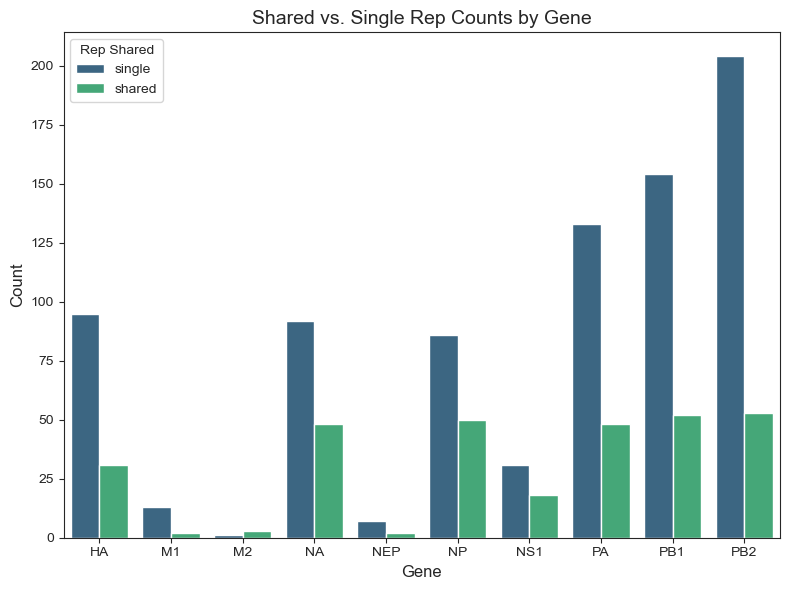

In [56]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Group by 'gene' and count unique values in 'rep_shared'
result = vars.groupby('gene')['rep_shared'].value_counts().reset_index(name='count')

# Create a bar plot using seaborn
plt.figure(figsize=(8, 6))
sns.barplot(data=result, x='gene', y='count', hue='rep_shared', palette='viridis')

# Add labels and title
plt.xlabel('Gene', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Shared vs. Single Rep Counts by Gene', fontsize=14)
plt.legend(title='Rep Shared', fontsize=10)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Show the plot
plt.tight_layout()

# filename = "../seq/analysis/figures/shared_vs_singlerep_countsbygene_"+todays_date+".pdf"

# plt.savefig(filename, bbox_inches='tight', dpi=300)

plt.show()


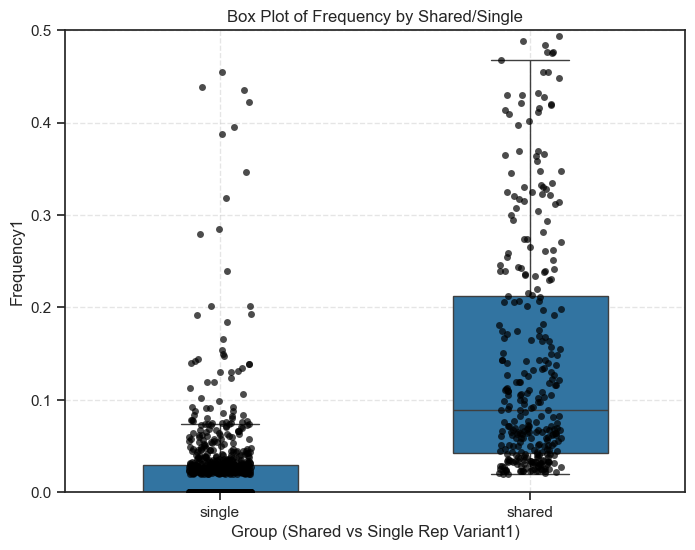

In [416]:
# Create box plot with individual data points
plt.figure(figsize=(8, 6))
sns.boxplot(x='rep_shared', y='Frequency_1', data=vars, width=0.5, showfliers=False)  # Box plot
sns.stripplot(x='rep_shared', y='Frequency_1', data=vars, jitter=True, color='black', alpha=0.7)  # Individual points

# Customize plot
plt.xlabel("Group (Shared vs Single Rep Variant1)")
plt.ylabel("Frequency1")
plt.title("Box Plot of Frequency by Shared/Single")
plt.grid(True, linestyle="--", alpha=0.5)
# plt.yscale('logit')
plt.ylim(0, 0.5)

# Show plot
plt.show()

In [417]:
import scipy.stats as stats

# Calculate means
vars = vars.dropna(subset=["Frequency_1"])

means = vars.groupby("rep_shared")["Frequency_1"].mean()
print("Mean Frequency1 by Group:")
print(means)

# Perform independent t-test
shared = vars[vars["rep_shared"] == "shared"]["rep_shared"]
single = vars[vars["rep_shared"] == "single"]["rep_shared"]

##just some gut check looking at some results comparing single and shared rep


Mean Frequency1 by Group:
rep_shared
shared    0.141668
single    0.025532
Name: Frequency_1, dtype: float64


In [22]:
pwd

'/Users/asjaeger/Desktop/project_source/hpai-PA/within_host_scripts'

In [33]:
##read in full meta for these seqs
# meta = pd.read_csv('../../phylo/2026-01-27_fullgenome_PAtree/data/2026_01_27_hpai_PA_meta_for_nextstrain.tsv', sep='\t')
meta = pd.read_csv('../sample_data/2026_02_20_hpai_PA_meta_for_nextstrain.tsv', sep='\t')

meta

,strain,region,country,division,location,host,subtype,originating_lab,h5_label_clade,submitting_lab,...,Run_number,date,sample_species,domestic_status,county,date_collected,ct_value,sample_ID,seq_run1,seq_run2
0,A/baldeagle/Pennsylvania/be_w1/2022,North America,Usa,Pennsylvania,Pennsylvania,Avian,h5n1,UPENN,2.3.4.4b,UPENN,...,4.0,2022-09-28,bald eagle,wild,Crawford,2022-09-28,26.95,be_w1,4,6
1,A/baldeagle/Pennsylvania/be_w2/2023,North America,Usa,Pennsylvania,Pennsylvania,Avian,h5n1,UPENN,2.3.4.4b,UPENN,...,6.0,2023-03-20,bald eagle,wild,Lancaster,2023-03-20,26.95,be_w2,6,NaN
2,A/baldeagle/Pennsylvania/be_w3/2024,North America,Usa,Pennsylvania,Pennsylvania,Avian,h5n1,UPENN,2.3.4.4b,UPENN,...,6.0,2024-02-02,bald eagle,wild,Mehoopany,2024-02-02,27.07,be_w3,6,NaN
3,A/baldeagle/Pennsylvania/be_w4/2025,North America,Usa,Pennsylvania,Pennsylvania,Avian,h5n1,UPENN,2.3.4.4b,UPENN,...,NaN,2025-01-17,bald eagle,wild,Northumberland,2025-01-17,20.06,be_w4,10,NaN
4,A/blackvulture/Pennsylvania/blvu_adams/2022,North America,Usa,Pennsylvania,Pennsylvania,Avian,h5n2,UPENN,2.3.4.4b,UPENN,...,3.0,2022-10-10,black vulture,wild,Adams,2022-10-10,15.94,blvu_adams,2,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80,A/snowyowl/Pennsylvania/so_w1/2025,North America,Usa,Pennsylvania,Pennsylvania,Avian,h5n1,UPENN,2.3.4.4b,UPENN,...,NaN,2025-03-06,snowy owl,wild,Erie,2025-03-06,20.89,so_w1,10,NaN
81,A/turkeyvulture/Pennsylvania/tv_w1/2023,North America,Usa,Pennsylvania,Pennsylvania,Avian,h5n1,UPENN,2.3.4.4b,UPENN,...,4.0,2023-03-17,turkey vulture,wild,Lancaster,2023-03-17,19.95,tv_w1,4,NaN
82,A/turkeyvulture/Pennsylvania/tv_w2/2025,North America,Usa,Pennsylvania,Pennsylvania,Avian,h5n1,UPENN,2.3.4.4b,UPENN,...,NaN,2025-03-05,turkey vulture,wild,Erie,2025-03-05,18.77,tv_w2,10,NaN
83,A/turkeyvulture/Pennsylvania/tv_w3/2025,North America,Usa,Pennsylvania,Pennsylvania,Avian,h5n1,UPENN,2.3.4.4b,UPENN,...,NaN,2025-03-24,turkey vulture,wild,Cumberland,2025-03-24,20.00,tv_w3,10,NaN


In [27]:
# meta['sample_ID'] = meta['sample_ID'].replace({'be_w': 'be_w1', 'gf_w': 'gf_w1'})


In [34]:
vars.columns

Index(['segment', 'position', 'allele', 'coding_region_change', 'gene',
       'Frequency_1', 'Frequency_2', 'sample', 'amino_acid', 'gene_pos',
       'sample_var', 'syn_non', 'sample_ID', 'domestic_status', 'ct_value',
       'rep_shared'],
      dtype='object')

In [35]:
meta.columns = meta.columns.str.lower()

meta.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85 entries, 0 to 84
Data columns (total 28 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   strain           85 non-null     object 
 1   region           85 non-null     object 
 2   country          85 non-null     object 
 3   division         85 non-null     object 
 4   location         85 non-null     object 
 5   host             85 non-null     object 
 6   subtype          85 non-null     object 
 7   originating_lab  85 non-null     object 
 8   h5_label_clade   85 non-null     object 
 9   submitting_lab   85 non-null     object 
 10  animal           85 non-null     object 
 11  order            85 non-null     object 
 12  flyway           85 non-null     object 
 13  geo_region_na    85 non-null     object 
 14  id               85 non-null     object 
 15  country          85 non-null     object 
 16  species          44 non-null     object 
 17  species_group    7

In [36]:
meta.rename(columns={'sample_id':'sample_ID'}, inplace=True)


In [37]:
vars = vars.merge(meta[['sample_ID', 'order', 'county', 'date', 'species', 'species_group']], 
                        on='sample_ID',
                        how='left')  
# vars = vars.rename(columns={"County": "county"})

vars

,segment,position,allele,coding_region_change,gene,Frequency_1,Frequency_2,sample,amino_acid,gene_pos,...,syn_non,sample_ID,domestic_status,ct_value,rep_shared,order,county,date,species,species_group
0,ha,438,C,Ser137Phe,HA,0.0298,0.0000,c_com1,137,HA_137,...,nonsynonymous,c_com1,commercial,28.72,single,galliformes,Lebanon,2025-03-16,NaN,Galliformes
1,ha,524,C,Leu166Ile,HA,0.0000,0.0347,c_com1,166,HA_166,...,nonsynonymous,c_com1,commercial,28.72,single,galliformes,Lebanon,2025-03-16,NaN,Galliformes
2,ha,622,C,Asn198Asn,HA,0.0000,0.0231,c_com1,198,HA_198,...,synonymous,c_com1,commercial,28.72,single,galliformes,Lebanon,2025-03-16,NaN,Galliformes
3,ha,763,C,Phe245Leu,HA,0.0826,0.0000,c_com1,245,HA_245,...,nonsynonymous,c_com1,commercial,28.72,single,galliformes,Lebanon,2025-03-16,NaN,Galliformes
4,ha,785,G,Asp253Asn,HA,0.0000,0.0382,c_com1,253,HA_253,...,nonsynonymous,c_com1,commercial,28.72,single,galliformes,Lebanon,2025-03-16,NaN,Galliformes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1118,pb1,1752,G,Leu576Leu,PB1,0.0723,0.0000,kc_com8,576,PB1_576,...,synonymous,kc_com8,commercial,27.29,single,anseriformes,Lancaster,2023-02-24,duck,Anseriformes
1119,pb1,1905,C,Pro627Pro,PB1,0.0907,0.0000,kc_com8,627,PB1_627,...,synonymous,kc_com8,commercial,27.29,single,anseriformes,Lancaster,2023-02-24,duck,Anseriformes
1120,pb1,2119,T,Phe699Leu,PB1,0.1400,0.0000,kc_com8,699,PB1_699,...,nonsynonymous,kc_com8,commercial,27.29,single,anseriformes,Lancaster,2023-02-24,duck,Anseriformes
1121,pb2,1101,G,Glu358Glu,PB2,0.0319,0.0000,kc_com8,358,PB2_358,...,synonymous,kc_com8,commercial,27.29,single,anseriformes,Lancaster,2023-02-24,duck,Anseriformes


In [38]:
vars['color'] = vars['domestic_status'] + "_" + vars['syn_non']
vars

,segment,position,allele,coding_region_change,gene,Frequency_1,Frequency_2,sample,amino_acid,gene_pos,...,sample_ID,domestic_status,ct_value,rep_shared,order,county,date,species,species_group,color
0,ha,438,C,Ser137Phe,HA,0.0298,0.0000,c_com1,137,HA_137,...,c_com1,commercial,28.72,single,galliformes,Lebanon,2025-03-16,NaN,Galliformes,commercial_nonsynonymous
1,ha,524,C,Leu166Ile,HA,0.0000,0.0347,c_com1,166,HA_166,...,c_com1,commercial,28.72,single,galliformes,Lebanon,2025-03-16,NaN,Galliformes,commercial_nonsynonymous
2,ha,622,C,Asn198Asn,HA,0.0000,0.0231,c_com1,198,HA_198,...,c_com1,commercial,28.72,single,galliformes,Lebanon,2025-03-16,NaN,Galliformes,commercial_synonymous
3,ha,763,C,Phe245Leu,HA,0.0826,0.0000,c_com1,245,HA_245,...,c_com1,commercial,28.72,single,galliformes,Lebanon,2025-03-16,NaN,Galliformes,commercial_nonsynonymous
4,ha,785,G,Asp253Asn,HA,0.0000,0.0382,c_com1,253,HA_253,...,c_com1,commercial,28.72,single,galliformes,Lebanon,2025-03-16,NaN,Galliformes,commercial_nonsynonymous
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1118,pb1,1752,G,Leu576Leu,PB1,0.0723,0.0000,kc_com8,576,PB1_576,...,kc_com8,commercial,27.29,single,anseriformes,Lancaster,2023-02-24,duck,Anseriformes,commercial_synonymous
1119,pb1,1905,C,Pro627Pro,PB1,0.0907,0.0000,kc_com8,627,PB1_627,...,kc_com8,commercial,27.29,single,anseriformes,Lancaster,2023-02-24,duck,Anseriformes,commercial_synonymous
1120,pb1,2119,T,Phe699Leu,PB1,0.1400,0.0000,kc_com8,699,PB1_699,...,kc_com8,commercial,27.29,single,anseriformes,Lancaster,2023-02-24,duck,Anseriformes,commercial_nonsynonymous
1121,pb2,1101,G,Glu358Glu,PB2,0.0319,0.0000,kc_com8,358,PB2_358,...,kc_com8,commercial,27.29,single,anseriformes,Lancaster,2023-02-24,duck,Anseriformes,commercial_synonymous


In [39]:
single_rep_vars = vars[vars['rep_shared'] == 'single']

In [40]:
# single_rep_vars['avg_freq'] = single_rep_vars['frequency']
single_rep_vars['avg_freq'] = single_rep_vars['Frequency_1'] + single_rep_vars['Frequency_2']

single_rep_vars

/var/folders/8h/zkgpnzwj7f9d82wldp_d4h_w0000gs/T/ipykernel_26043/3374936531.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  single_rep_vars['avg_freq'] = single_rep_vars['Frequency_1'] + single_rep_vars['Frequency_2']


,segment,position,allele,coding_region_change,gene,Frequency_1,Frequency_2,sample,amino_acid,gene_pos,...,domestic_status,ct_value,rep_shared,order,county,date,species,species_group,color,avg_freq
0,ha,438,C,Ser137Phe,HA,0.0298,0.0000,c_com1,137,HA_137,...,commercial,28.72,single,galliformes,Lebanon,2025-03-16,NaN,Galliformes,commercial_nonsynonymous,0.0298
1,ha,524,C,Leu166Ile,HA,0.0000,0.0347,c_com1,166,HA_166,...,commercial,28.72,single,galliformes,Lebanon,2025-03-16,NaN,Galliformes,commercial_nonsynonymous,0.0347
2,ha,622,C,Asn198Asn,HA,0.0000,0.0231,c_com1,198,HA_198,...,commercial,28.72,single,galliformes,Lebanon,2025-03-16,NaN,Galliformes,commercial_synonymous,0.0231
3,ha,763,C,Phe245Leu,HA,0.0826,0.0000,c_com1,245,HA_245,...,commercial,28.72,single,galliformes,Lebanon,2025-03-16,NaN,Galliformes,commercial_nonsynonymous,0.0826
4,ha,785,G,Asp253Asn,HA,0.0000,0.0382,c_com1,253,HA_253,...,commercial,28.72,single,galliformes,Lebanon,2025-03-16,NaN,Galliformes,commercial_nonsynonymous,0.0382
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1118,pb1,1752,G,Leu576Leu,PB1,0.0723,0.0000,kc_com8,576,PB1_576,...,commercial,27.29,single,anseriformes,Lancaster,2023-02-24,duck,Anseriformes,commercial_synonymous,0.0723
1119,pb1,1905,C,Pro627Pro,PB1,0.0907,0.0000,kc_com8,627,PB1_627,...,commercial,27.29,single,anseriformes,Lancaster,2023-02-24,duck,Anseriformes,commercial_synonymous,0.0907
1120,pb1,2119,T,Phe699Leu,PB1,0.1400,0.0000,kc_com8,699,PB1_699,...,commercial,27.29,single,anseriformes,Lancaster,2023-02-24,duck,Anseriformes,commercial_nonsynonymous,0.1400
1121,pb2,1101,G,Glu358Glu,PB2,0.0319,0.0000,kc_com8,358,PB2_358,...,commercial,27.29,single,anseriformes,Lancaster,2023-02-24,duck,Anseriformes,commercial_synonymous,0.0319


In [41]:
shared_vars = vars[vars['rep_shared'] == 'shared']
# shared_vars = shared_vars.sort_values(by=['sample_ID', 'gene', 'reference_position'], ascending=[True, True, True])
shared_vars['avg_freq'] = shared_vars[['Frequency_1', 'Frequency_2']].mean(axis=1)

shared_vars

/var/folders/8h/zkgpnzwj7f9d82wldp_d4h_w0000gs/T/ipykernel_26043/2824890257.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  shared_vars['avg_freq'] = shared_vars[['Frequency_1', 'Frequency_2']].mean(axis=1)


,segment,position,allele,coding_region_change,gene,Frequency_1,Frequency_2,sample,amino_acid,gene_pos,...,domestic_status,ct_value,rep_shared,order,county,date,species,species_group,color,avg_freq
33,na,43,T,Ile8Thr,NA,0.3326,0.3412,c_com5,8,NA_8,...,commercial,22.01,shared,galliformes,unknown,2025-01-26,NaN,Galliformes,commercial_nonsynonymous,0.33690
34,na,67,T,Val16Ala,NA,0.2439,0.2890,c_com5,16,NA_16,...,commercial,22.01,shared,galliformes,unknown,2025-01-26,NaN,Galliformes,commercial_nonsynonymous,0.26645
35,na,76,T,Ile19Thr,NA,0.2454,0.2615,c_com5,19,NA_19,...,commercial,22.01,shared,galliformes,unknown,2025-01-26,NaN,Galliformes,commercial_nonsynonymous,0.25345
36,na,79,T,Ile20Thr,NA,0.2392,0.2624,c_com5,20,NA_20,...,commercial,22.01,shared,galliformes,unknown,2025-01-26,NaN,Galliformes,commercial_nonsynonymous,0.25080
39,pa,1173,C,Asp383Asp,PA,0.1338,0.1468,c_com5,383,PA_383,...,commercial,22.01,shared,galliformes,unknown,2025-01-26,NaN,Galliformes,commercial_synonymous,0.14030
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1057,pb2,1560,A,Val511Val,PB2,0.0869,0.0918,kc_com6,511,PB2_511,...,commercial,21.93,shared,anseriformes,Chester,2023-02-23,duck,Anseriformes,commercial_synonymous,0.08935
1058,pb2,1659,A,Ser544Ser,PB2,0.4205,0.4155,kc_com6,544,PB2_544,...,commercial,21.93,shared,anseriformes,Chester,2023-02-23,duck,Anseriformes,commercial_synonymous,0.41800
1067,np,1023,T,Ser326Ser,NP,0.1652,0.0818,kc_com7,326,NP_326,...,commercial,22.13,shared,anseriformes,Chester,2023-02-23,duck,Anseriformes,commercial_synonymous,0.12350
1081,pb2,1659,A,Ser544Ser,PB2,0.3472,0.3537,kc_com7,544,PB2_544,...,commercial,22.13,shared,anseriformes,Chester,2023-02-23,duck,Anseriformes,commercial_synonymous,0.35045


In [177]:
# ####filtering both of these down to 3# freq or above now!- already filtered by illumina-pipeline
# shared_vars = shared_vars[(shared_vars['Frequency_1'] >= 0.02) & (shared_vars['Frequency_2'] >= 0.02)]
# single_rep_vars = single_rep_vars[(single_rep_vars['avg_freq'] >= 0.02)]


In [42]:
##since i needed to get avg vars differently for single and shared, did that now will concat together for big vars df
vars = pd.concat([single_rep_vars, shared_vars], ignore_index=True)
vars

,segment,position,allele,coding_region_change,gene,Frequency_1,Frequency_2,sample,amino_acid,gene_pos,...,domestic_status,ct_value,rep_shared,order,county,date,species,species_group,color,avg_freq
0,ha,438,C,Ser137Phe,HA,0.0298,0.0000,c_com1,137,HA_137,...,commercial,28.72,single,galliformes,Lebanon,2025-03-16,NaN,Galliformes,commercial_nonsynonymous,0.02980
1,ha,524,C,Leu166Ile,HA,0.0000,0.0347,c_com1,166,HA_166,...,commercial,28.72,single,galliformes,Lebanon,2025-03-16,NaN,Galliformes,commercial_nonsynonymous,0.03470
2,ha,622,C,Asn198Asn,HA,0.0000,0.0231,c_com1,198,HA_198,...,commercial,28.72,single,galliformes,Lebanon,2025-03-16,NaN,Galliformes,commercial_synonymous,0.02310
3,ha,763,C,Phe245Leu,HA,0.0826,0.0000,c_com1,245,HA_245,...,commercial,28.72,single,galliformes,Lebanon,2025-03-16,NaN,Galliformes,commercial_nonsynonymous,0.08260
4,ha,785,G,Asp253Asn,HA,0.0000,0.0382,c_com1,253,HA_253,...,commercial,28.72,single,galliformes,Lebanon,2025-03-16,NaN,Galliformes,commercial_nonsynonymous,0.03820
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1118,pb2,1560,A,Val511Val,PB2,0.0869,0.0918,kc_com6,511,PB2_511,...,commercial,21.93,shared,anseriformes,Chester,2023-02-23,duck,Anseriformes,commercial_synonymous,0.08935
1119,pb2,1659,A,Ser544Ser,PB2,0.4205,0.4155,kc_com6,544,PB2_544,...,commercial,21.93,shared,anseriformes,Chester,2023-02-23,duck,Anseriformes,commercial_synonymous,0.41800
1120,np,1023,T,Ser326Ser,NP,0.1652,0.0818,kc_com7,326,NP_326,...,commercial,22.13,shared,anseriformes,Chester,2023-02-23,duck,Anseriformes,commercial_synonymous,0.12350
1121,pb2,1659,A,Ser544Ser,PB2,0.3472,0.3537,kc_com7,544,PB2_544,...,commercial,22.13,shared,anseriformes,Chester,2023-02-23,duck,Anseriformes,commercial_synonymous,0.35045


In [43]:
vars['sample_var'] = vars['sample_ID'] + "_" + vars['gene_pos'].astype(str)


In [44]:
vars['sample_ID'].unique()

array(['c_com1', 'c_com2', 'c_com3', 'c_com5', 'c_com6', 'c_lbm10',
       'c_lbm11', 'c_lbm1', 'c_lbm2', 'c_lbm3', 'c_lbm5', 'c_lbm6',
       'c_lbm7', 'c_lbm8', 'c_lbm9', 'cb_com1', 'cb_com2', 'cb_com3',
       'cb_com4', 'ckr_com1', 'ckr_com2', 'ckr_com3', 'ckr_lbm1',
       'd_com1', 'd_com2', 'd_com3', 'd_lbm1', 'd_lbm2', 'd_lbm3',
       'd_lbm4', 'g_com1', 'g_com2', 'g_lbm1', 'gn_lbm1', 'kc_com1',
       'kc_com2', 'kc_com3', 'kc_com4', 'kc_com5', 'kc_com6', 'kc_com7',
       'kc_com8'], dtype=object)

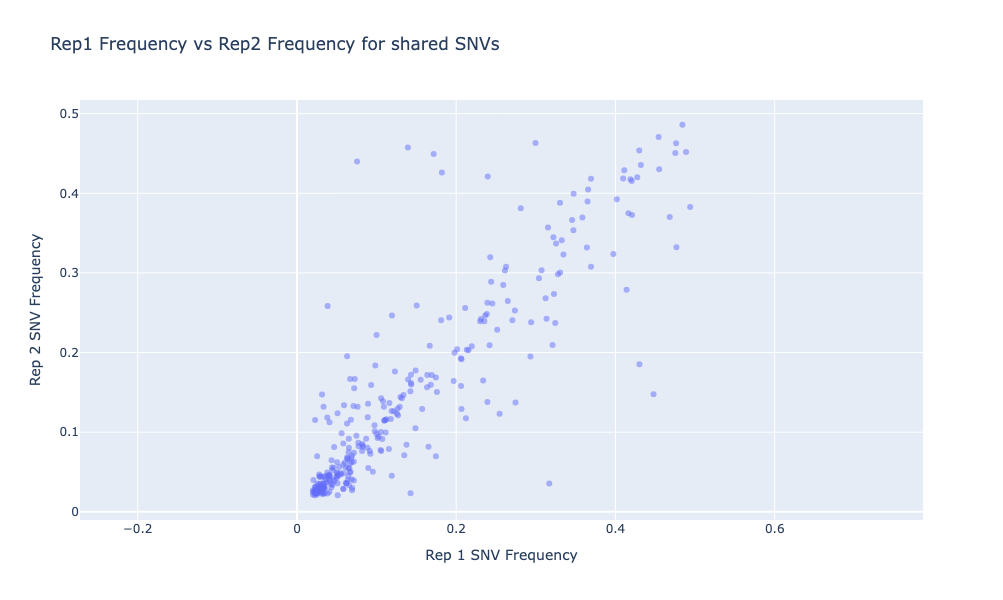

In [69]:
import plotly.express as px

# Scatter plot of rep1_freq vs rep2_freq
fig = px.scatter(shared_vars, 
                 x="Frequency_1", 
                 y="Frequency_2", 
                 title="Rep1 Frequency vs Rep2 Frequency for shared SNVs",
                 labels={"Frequency_1": "Rep 1 SNV Frequency", "Frequency_2": "Rep 2 SNV Frequency"},
                 opacity=0.5,
                 hover_data=["ct_value", 'sample_ID'])

fig.update_layout(
    width=600,  # Set width
    height=600,  # Set height (same as width for square shape)
    xaxis=dict(scaleanchor="y")  # Ensures 1:1 aspect ratio
)

# Show the plot
fig.show()
# fig.savefig("seq/analysis/figures/rep1_rep2_freq_SNVs.pdf", bbox_inches='tight', dpi=300)
# fig.write_image("seq/analysis/figures/rep1_rep2_freq_SNVs.pdf")

In [39]:
shared_vars['species_group'].nunique()

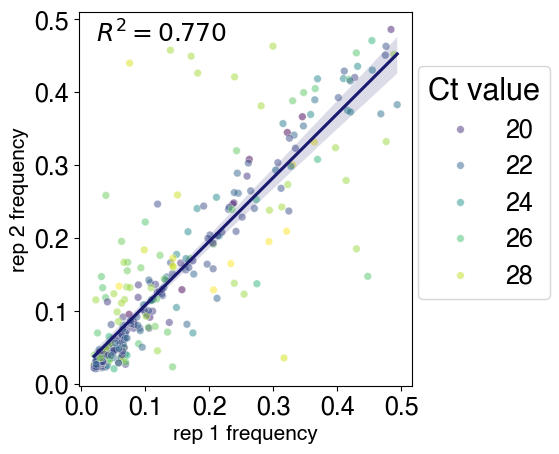

In [45]:
import seaborn as sns 
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as tkr
from scipy.stats import linregress


plt.rc('font',**{'family':'sans-serif','sans-serif':['Helvetica']})
plt.rc('text', usetex='false') 
plt.rcParams.update({'font.size': 22})
plt.figure(figsize=(7, 5))  # Adjust figure size


# fig, ax = plt.subplots(figsize=(6,5))

sns.scatterplot(data=shared_vars, x="Frequency_1", y="Frequency_2", s=30, alpha=.5, hue='ct_value', palette='viridis')

##adding in regression/rsquare

sns.regplot(data=shared_vars, x='Frequency_1', y='Frequency_2', scatter=False, line_kws={'color': 'midnightblue'})


# Calculate regression stats
slope, intercept, r_value, p_value, std_err = linregress(
    shared_vars['Frequency_1'],
    shared_vars['Frequency_2']
)

r2 = r_value**2

plt.text(
    0.05, 0.98,
    f'$R^2 = {r2:.3f}$',
    # f'$R^2 = {r2:.3f}$\n$slope = {slope:.3f}$', ##can add slope here too, slope is .883
    transform=plt.gca().transAxes,
    fontsize=18,
    verticalalignment='top'
)

#######

# plt.ylim(0, 0.51)
# plt.xlim(0, 0.51)
plt.xticks([0, .1, .2, .3, .4, .5], fontsize=18)
plt.yticks([0, .1, .2, .3, .4, .5], fontsize=18)


# plt.title('shared variant frequencies between replicates', y=1.05, fontsize=16)
plt.legend(loc='lower right', bbox_to_anchor=[1.45, 0.2],fontsize=18, title="Ct value")
# ax.set(xlabel='Rep 1 Frequency', ylabel='Rep 2 Frequency')

plt.xlabel('rep 1 frequency', fontsize=15)
plt.ylabel('rep 2 frequency', fontsize=15)

plt.tight_layout()

filename = "../output_plots/"+todays_date+"-sharedvars-repfreqs-com.pdf"
# plt.savefig(filename, format='pdf', bbox_inches='tight', dpi=300)


plt.show()


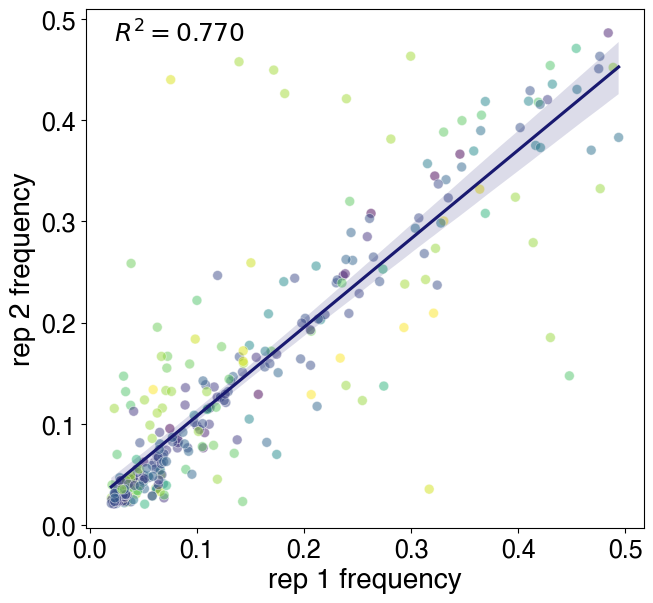

In [40]:
##plot with no legend for final fig formatting!

plt.rc('font',**{'family':'sans-serif','sans-serif':['Helvetica']})
plt.rc('text', usetex='false') 
plt.rcParams.update({'font.size': 22})
plt.figure(figsize=(7, 6.5))  # Adjust figure size


# fig, ax = plt.subplots(figsize=(6,5))

sns.scatterplot(data=shared_vars, x="Frequency_1", y="Frequency_2", s=50, alpha=.5, hue='ct_value', palette='viridis', legend=False)

##adding in regression/rsquare

sns.regplot(data=shared_vars, x='Frequency_1', y='Frequency_2', scatter=False, line_kws={'color': 'midnightblue'})


# Calculate regression stats
slope, intercept, r_value, p_value, std_err = linregress(
    shared_vars['Frequency_1'],
    shared_vars['Frequency_2']
)

r2 = r_value**2

plt.text(
    0.05, 0.98,
    f'$R^2 = {r2:.3f}$',
    # f'$R^2 = {r2:.3f}$\n$slope = {slope:.3f}$', ##can add slope here too, slope is .883
    transform=plt.gca().transAxes,
    fontsize=18,
    verticalalignment='top'
)

#######

# plt.ylim(0, 0.51)
# plt.xlim(0, 0.51)
plt.xticks([0, .1, .2, .3, .4, .5], fontsize=18)
plt.yticks([0, .1, .2, .3, .4, .5], fontsize=18)


# plt.title('shared variant frequencies between replicates', y=1.05, fontsize=16)
# plt.legend(loc='lower right', bbox_to_anchor=[1.3, 0.2],fontsize=13, title="Ct value")

# ax.set(xlabel='Rep 1 Frequency', ylabel='Rep 2 Frequency')

plt.xlabel('rep 1 frequency', fontsize=20)
plt.ylabel('rep 2 frequency', fontsize=20)

plt.tight_layout()

filename = "../output_plots/"+todays_date+"-sharedvars-repfreqs-com-nolegend.pdf"
plt.savefig(filename, format='pdf', bbox_inches='tight', dpi=300)


plt.show()


In [144]:
slope, intercept, r_value, p_value, std_err = linregress(
    shared_vars['Frequency_1'],
    shared_vars['Frequency_2']
)
print(slope)

0.8749400836725505


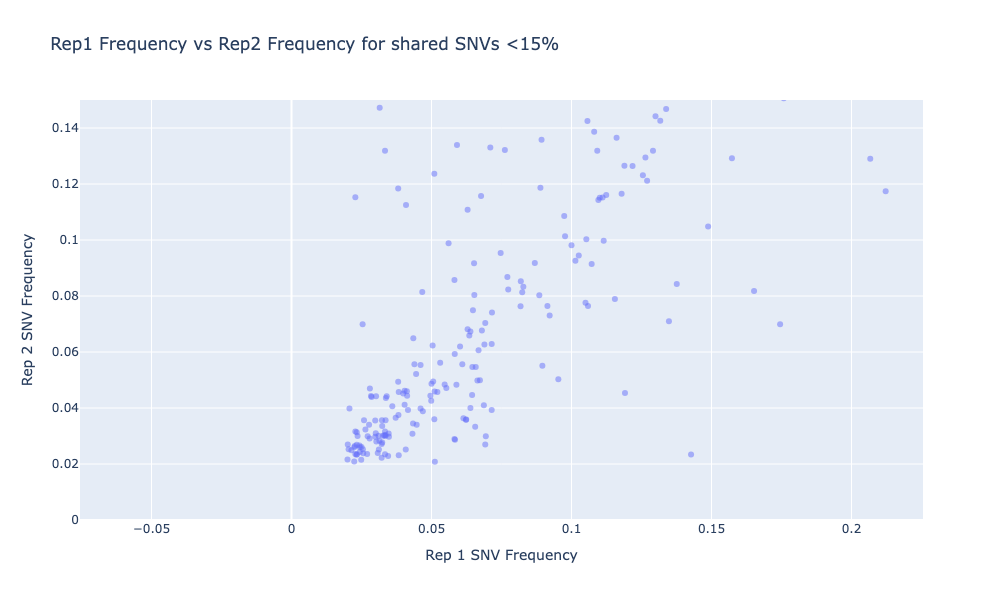

In [429]:
import plotly.express as px

# Scatter plot of rep1_freq vs rep2_freq
fig = px.scatter(shared_vars, 
                 x="Frequency_1", 
                 y="Frequency_2", 
                 title="Rep1 Frequency vs Rep2 Frequency for shared SNVs <15%",
                 labels={"Frequency_1": "Rep 1 SNV Frequency", "Frequency_2": "Rep 2 SNV Frequency"},
                 opacity=0.5,
                 hover_data=["sample_var", 'ct_value'])

# Define axis limits
x_min, x_max = 0, 0.15  # Adjust as needed
y_min, y_max = 0, 0.15  # Adjust as needed

# Make the plot square and set axis limits
fig.update_layout(
    width=600,  
    height=600,  
    xaxis=dict(scaleanchor="y", range=[x_min, x_max]),  
    yaxis=dict(range=[y_min, y_max])
)

# Show the plot
fig.show()


In [46]:
valcts_sampleIDs = shared_vars['sample_ID'].value_counts()
print(valcts_sampleIDs)

sample_ID
ckr_com1    21
ckr_com3    18
c_lbm5      16
ckr_com2    15
kc_com6     13
kc_com3     13
gn_lbm1     13
d_lbm2      13
d_lbm3      12
d_com2      12
d_com1      12
c_lbm7      11
cb_com1     11
d_lbm4      10
c_lbm8      10
d_lbm1      10
c_com5       9
cb_com2      8
c_lbm2       8
kc_com5      8
c_lbm10      7
cb_com3      7
c_lbm6       7
c_lbm9       6
c_lbm11      6
g_lbm1       5
c_lbm1       5
kc_com4      5
d_com3       3
c_com6       3
g_com2       3
g_com1       2
kc_com7      2
cb_com4      1
c_lbm3       1
kc_com8      1
Name: count, dtype: int64


In [47]:
# define colors 

# blue/red scheme 1 (desaturated)
dom_color = "#C75643"
lbm_color = "#545AB7"


# blue/red scheme 1 (desaturated)
dom_nonsyn_color = "#545AB7"
dom_syn_color = "#98B4DA"
lbm_nonsyn_color = "#C75643"
lbm_syn_color = "#E6B692"

In [ ]:
# shared_vars['color'] = shared_vars['dom_status'] + "_" + shared_vars['synonymous/nonsynonymous']
# shared_vars.head()

In [48]:
shared_vars['order_domstat'] = shared_vars['order'] + "_" + shared_vars['domestic_status']
shared_vars.head()

/var/folders/8h/zkgpnzwj7f9d82wldp_d4h_w0000gs/T/ipykernel_26043/2258759835.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  shared_vars['order_domstat'] = shared_vars['order'] + "_" + shared_vars['domestic_status']


,segment,position,allele,coding_region_change,gene,Frequency_1,Frequency_2,sample,amino_acid,gene_pos,...,ct_value,rep_shared,order,county,date,species,species_group,color,avg_freq,order_domstat
33,na,43,T,Ile8Thr,NA,0.3326,0.3412,c_com5,8,NA_8,...,22.01,shared,galliformes,unknown,2025-01-26,NaN,Galliformes,commercial_nonsynonymous,0.33690,galliformes_commercial
34,na,67,T,Val16Ala,NA,0.2439,0.2890,c_com5,16,NA_16,...,22.01,shared,galliformes,unknown,2025-01-26,NaN,Galliformes,commercial_nonsynonymous,0.26645,galliformes_commercial
35,na,76,T,Ile19Thr,NA,0.2454,0.2615,c_com5,19,NA_19,...,22.01,shared,galliformes,unknown,2025-01-26,NaN,Galliformes,commercial_nonsynonymous,0.25345,galliformes_commercial
36,na,79,T,Ile20Thr,NA,0.2392,0.2624,c_com5,20,NA_20,...,22.01,shared,galliformes,unknown,2025-01-26,NaN,Galliformes,commercial_nonsynonymous,0.25080,galliformes_commercial
39,pa,1173,C,Asp383Asp,PA,0.1338,0.1468,c_com5,383,PA_383,...,22.01,shared,galliformes,unknown,2025-01-26,NaN,Galliformes,commercial_synonymous,0.14030,galliformes_commercial


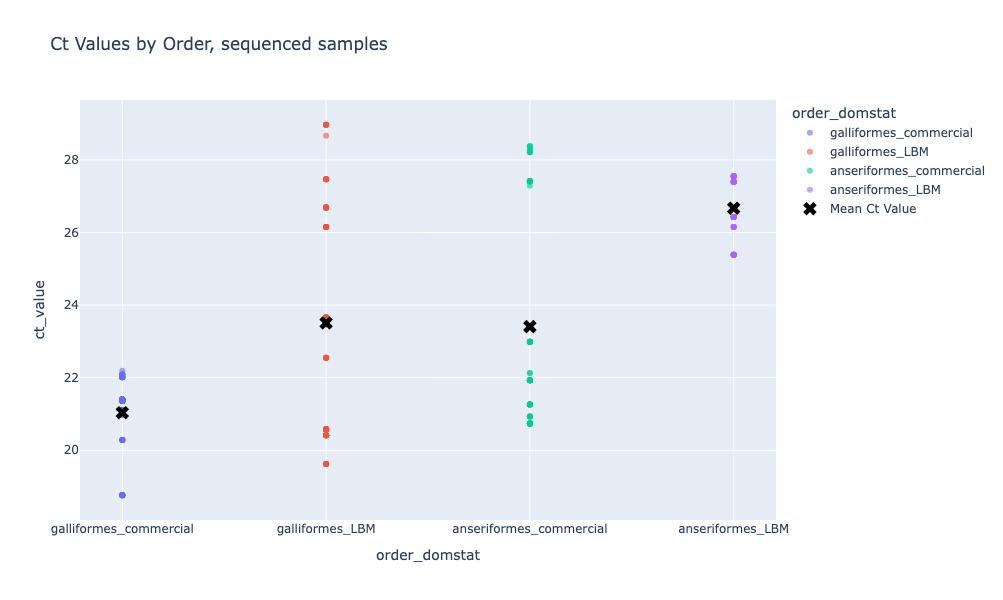

In [433]:
import plotly.express as px
import plotly.graph_objects as go
import pandas as pd

# Compute mean values for each category
mean_ct = shared_vars.groupby('order_domstat', as_index=False)['ct_value'].mean()

# Create scatter plot for individual values
fig = px.scatter(
    shared_vars,
    x='order_domstat',
    y='ct_value',
    color='order_domstat',
    title="Ct Values by Order, sequenced samples",
    hover_data=['sample_ID'],
    opacity=0.6,  # Make points slightly transparent
    width=950, height=600
)

# Add scatter plot for mean values
fig.add_trace(
    go.Scatter(
        x=mean_ct['order_domstat'],
        y=mean_ct['ct_value'],
        mode='markers',
        marker=dict(size=12, color='black', symbol='x'),  # Larger black X markers for means
        name='Mean Ct Value'
    )
)

# Show the plot
fig.show()


In [37]:
SNVsCounts_by_group = shared_vars.groupby('color').size()
print(SNVsCounts_by_group)
shared_vars.groupby('domestic_status')['sample_ID'].nunique()


color
LBM_nonsynonymous            52
LBM_synonymous               88
commercial_nonsynonymous     67
commercial_synonymous       100
dtype: int64


domestic_status
LBM           16
commercial    20
Name: sample_ID, dtype: int64

In [49]:
plt.rc('font',**{'family':'sans-serif','sans-serif':['Helvetica']})
plt.rc('text', usetex='false') 
plt.rcParams.update({'font.size': 22})

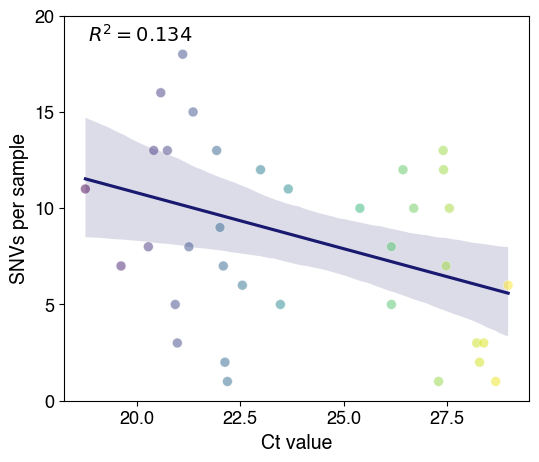

In [50]:
# Count occurrences of each sample_ID
sample_counts = shared_vars['sample_ID'].value_counts().reset_index()
sample_counts.columns = ['sample_ID', 'count']

# Merge with Ct values (assuming each sample_ID has a unique Ct value)
merged_df = shared_vars[['sample_ID', 'ct_value']].drop_duplicates().merge(sample_counts, on='sample_ID')

from scipy.stats import linregress

# Calculate regression stats
slope, intercept, r_value, p_value, std_err = linregress(
    merged_df['ct_value'],
    merged_df['count']
)

r2 = r_value**2

# Scatter plot
plt.figure(figsize=(6,5))

sns.regplot(data=merged_df, x='ct_value', y='count', scatter=False, line_kws={'color': 'midnightblue'})

sns.scatterplot(data=merged_df, x='ct_value', y='count',  s=50, alpha=.5, hue='ct_value', palette='viridis', legend=False)

# Labels and title
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)

plt.xlabel('Ct value', fontsize=14)
plt.ylabel('SNVs per sample', fontsize=14)
# plt.title('Ct value vs. SNV count',  y=1.02, fontsize=16)
plt.ylim(0,20)
# plt.legend(loc='center right')
# plt.legend(loc='lower right', bbox_to_anchor=[1.27, 0.2],fontsize=13, title="Ct value")


plt.text(
    0.05, 0.98,
    f'$R^2 = {r2:.3f}$',
    # f'$R^2 = {r2:.3f}$\n$slope = {slope:.3f}$', ##can add slope here too, slope is -.690
    transform=plt.gca().transAxes,
    fontsize=14,
    verticalalignment='top'
)
filename = "../output_plots/"+todays_date+"-repshared-snvs-by-ct-com.pdf"
# plt.savefig(filename, format='pdf', bbox_inches='tight', dpi=300)
plt.show()


In [51]:
sample_counts

,sample_ID,count
0,ckr_com1,21
1,ckr_com3,18
2,c_lbm5,16
3,ckr_com2,15
4,kc_com6,13
5,kc_com3,13
6,gn_lbm1,13
7,d_lbm2,13
8,d_lbm3,12
9,d_com2,12


In [54]:
mean_val = sample_counts["count"].mean()
std_val = sample_counts["count"].std()

print(f"Mean: {mean_val}, SD: {std_val}")

Mean: 8.527777777777779, SD: 5.022726130078941


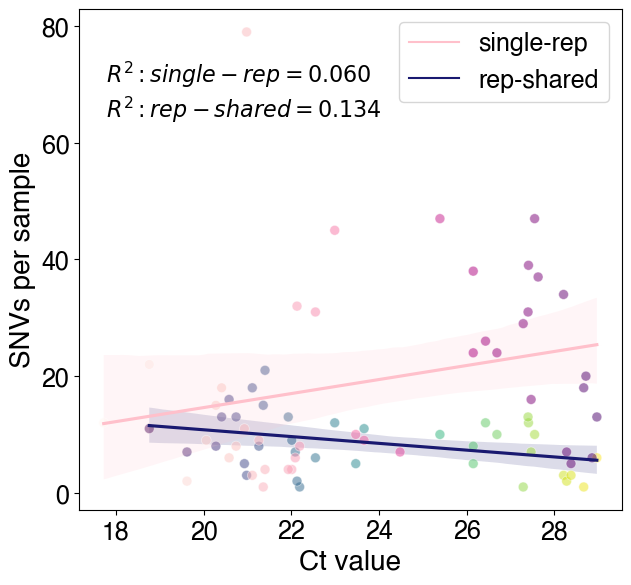

In [44]:
# Count occurrences of each sample_ID in singlerep vars 
sample_counts2 = single_rep_vars['sample_ID'].value_counts().reset_index()
sample_counts2.columns = ['sample_ID', 'count']

##testing removing ccom6 since it's a crazy outlier with loads of single rep snvs
# sample_counts2 = sample_counts2[sample_counts2['sample_ID'] != 'c_com6']
# sample_counts2 = sample_counts2[sample_counts2['sample_ID'] != 'c_lbm9']


# Merge with Ct values (assuming each sample_ID has a unique Ct value)
merged_df2 = single_rep_vars[['sample_ID', 'ct_value']].drop_duplicates().merge(sample_counts2, on='sample_ID')

from scipy.stats import linregress
from matplotlib.lines import Line2D


# Calculate regression stats
slope, intercept, r_value, p_value, std_err = linregress(
    merged_df2['ct_value'],
    merged_df2['count']
)

r2_singlerep = r_value**2

# Scatter plot
plt.figure(figsize=(7,6.5))

sns.regplot(data=merged_df, x='ct_value', y='count', scatter=False, line_kws={'color': 'midnightblue'})

sns.scatterplot(data=merged_df, x='ct_value', y='count',  s=50, alpha=.5, hue='ct_value', palette='viridis')

sns.regplot(data=merged_df2, x='ct_value', y='count', scatter=False, line_kws={'color': 'pink'})

sns.scatterplot(data=merged_df2, x='ct_value', y='count',  s=50, alpha=.5, hue='ct_value', palette='RdPu')

# Labels and title
plt.xlabel('Ct value', fontsize=20)
plt.ylabel('SNVs per sample', fontsize=20)

# plt.xticks(fontsize=18)
plt.xticks(range(18, 29, 2), fontsize=18)

plt.yticks(fontsize=18)
# plt.title('Ct value vs. SNV count, single rep SNVs',  y=1.02, fontsize=18)
# plt.yscale('log')
# plt.xlim(17,29)
# plt.legend(loc='center right')

legend_elements = [Line2D([0], [0], color='pink', label='single-rep'),
                   Line2D([0], [0], color='midnightblue', label='rep-shared')]
plt.legend(handles=legend_elements, loc='upper right', fontsize=18)

plt.text(
    0.05, 0.9,
    f'$R^2: single-rep = {r2_singlerep:.3f}$\n$R^2: rep-shared = {r2:.3f}$',
    transform=plt.gca().transAxes,
    fontsize=16,
    verticalalignment='top'
)

filename = "../output_plots/"+todays_date+"-repshared_singlerep-snvs-by-ct-com.pdf"
# plt.savefig(filename, format='pdf', bbox_inches='tight', dpi=300)
plt.show()


In [438]:
slope1, intercept, r_value, p_value1, std_err = linregress(
    merged_df['ct_value'],
    merged_df['count']
)
slope, intercept, r_value, p_value, std_err = linregress(
    merged_df2['ct_value'],
    merged_df2['count']
)
print(slope)
print(p_value)

print(slope1)
print(p_value1)


1.2023256937123024
0.11698241666052969
-0.5817556464906782
0.02790808331085314


In [45]:
sample_counts2

,sample_ID,count
0,c_com6,79
1,d_lbm4,47
2,d_lbm1,47
3,d_com2,45
4,d_com1,39
5,c_lbm2,38
6,ckr_lbm1,37
7,d_com3,34
8,kc_com7,32
9,d_lbm2,31


In [72]:
sample_counts

,sample_ID,count
0,ckr_com1,21
1,ckr_com3,18
2,c_lbm5,16
3,ckr_com2,15
4,kc_com6,13
5,kc_com3,13
6,gn_lbm1,13
7,d_lbm2,13
8,d_lbm3,12
9,d_com2,12


In [46]:
ct_df['domestic_status'].value_counts()

domestic_status
wild          39
commercial    28
LBM           18
Name: count, dtype: int64

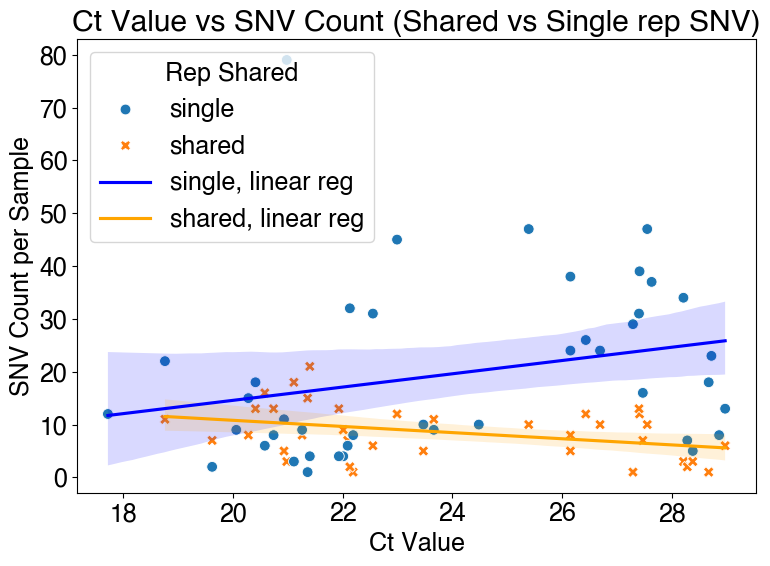

In [74]:
# Group by sample_ID and rep_shared to count SNVs
rep_counts = vars.groupby(['sample_ID', 'rep_shared']).size().reset_index(name='count')

# Merge in Ct values (assuming unique per sample_ID)
sample_metadata = vars[['sample_ID', 'ct_value']].drop_duplicates()
rep_counts = rep_counts.merge(sample_metadata, on='sample_ID')


plt.figure(figsize=(8, 6))

# Scatterplot and regression per group
sns.scatterplot(data=rep_counts, x='ct_value', y='count', hue='rep_shared', style='rep_shared', s=60)
sns.regplot(data=rep_counts[rep_counts['rep_shared'] == 'single'], 
            x='ct_value', y='count', scatter=False, label='single, linear reg', color='blue')
sns.regplot(data=rep_counts[rep_counts['rep_shared'] == 'shared'], 
            x='ct_value', y='count', scatter=False, label='shared, linear reg', color='orange')

# Labels and formatting
plt.xlabel('Ct Value')
plt.ylabel('SNV Count per Sample')
plt.title('Ct Value vs SNV Count (Shared vs Single rep SNV)')
# plt.ylim(1,325)
# plt.yscale('log')
plt.legend(title='Rep Shared')
plt.tight_layout()

# plt.savefig("seq/analysis/figures/ctval_snvcount_regress.pdf", bbox_inches='tight', dpi=300)
plt.show()


In [47]:
vars['gene_pos_nt'] = vars['gene'] + "_" + vars['position'].astype(str)
vars.head(5)

,segment,position,allele,coding_region_change,gene,Frequency_1,Frequency_2,sample,amino_acid,gene_pos,...,ct_value,rep_shared,order,county,date,species,species_group,color,avg_freq,gene_pos_nt
0,ha,438,C,Ser137Phe,HA,0.0298,0.0000,c_com1,137,HA_137,...,28.72,single,galliformes,Lebanon,2025-03-16,NaN,Galliformes,commercial_nonsynonymous,0.0298,HA_438
1,ha,524,C,Leu166Ile,HA,0.0000,0.0347,c_com1,166,HA_166,...,28.72,single,galliformes,Lebanon,2025-03-16,NaN,Galliformes,commercial_nonsynonymous,0.0347,HA_524
2,ha,622,C,Asn198Asn,HA,0.0000,0.0231,c_com1,198,HA_198,...,28.72,single,galliformes,Lebanon,2025-03-16,NaN,Galliformes,commercial_synonymous,0.0231,HA_622
3,ha,763,C,Phe245Leu,HA,0.0826,0.0000,c_com1,245,HA_245,...,28.72,single,galliformes,Lebanon,2025-03-16,NaN,Galliformes,commercial_nonsynonymous,0.0826,HA_763
4,ha,785,G,Asp253Asn,HA,0.0000,0.0382,c_com1,253,HA_253,...,28.72,single,galliformes,Lebanon,2025-03-16,NaN,Galliformes,commercial_nonsynonymous,0.0382,HA_785


In [63]:
shared_vars.columns

Index(['segment', 'position', 'allele', 'coding_region_change', 'gene',
       'Frequency_1', 'Frequency_2', 'sample', 'amino_acid', 'gene_pos',
       'sample_var', 'syn_non', 'sample_ID', 'domestic_status', 'ct_value',
       'rep_shared', 'order', 'county', 'date', 'species', 'species_group',
       'color', 'avg_freq', 'order_domstat'],
      dtype='object')

In [48]:
shared_vars['rep_shared'].value_counts()

rep_shared
shared    307
Name: count, dtype: int64

In [65]:
import matplotlib.font_manager as fm
fm._load_fontmanager(try_read_cache=False)

[f.name for f in fm.fontManager.ttflist if "Helvetica" in f.name]


plt.rc('font',**{'family':'sans-serif','sans-serif':['Helvetica']})
plt.rc('text', usetex='false') 
plt.rcParams.update({'font.size': 20})

# plt.rcParams.update({
#     "font.family": "sans-serif",
#     "font.sans-serif": ["Helvetica"],
#     "font.size": 20,
#     "text.usetex": False
# })
sns.set_theme()  # if you're using seaborn styling
plt.style.use("default")

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica"],
    "font.size": 20,
    "axes.titlesize": 20,
    "axes.labelsize": 18,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 14,
    "text.usetex": False
})

Matplotlib is building the font cache; this may take a moment.


/var/folders/8h/zkgpnzwj7f9d82wldp_d4h_w0000gs/T/ipykernel_27762/1360226432.py:8: UserWarning:

The palette list has more values (5) than needed (4), which may not be intended.



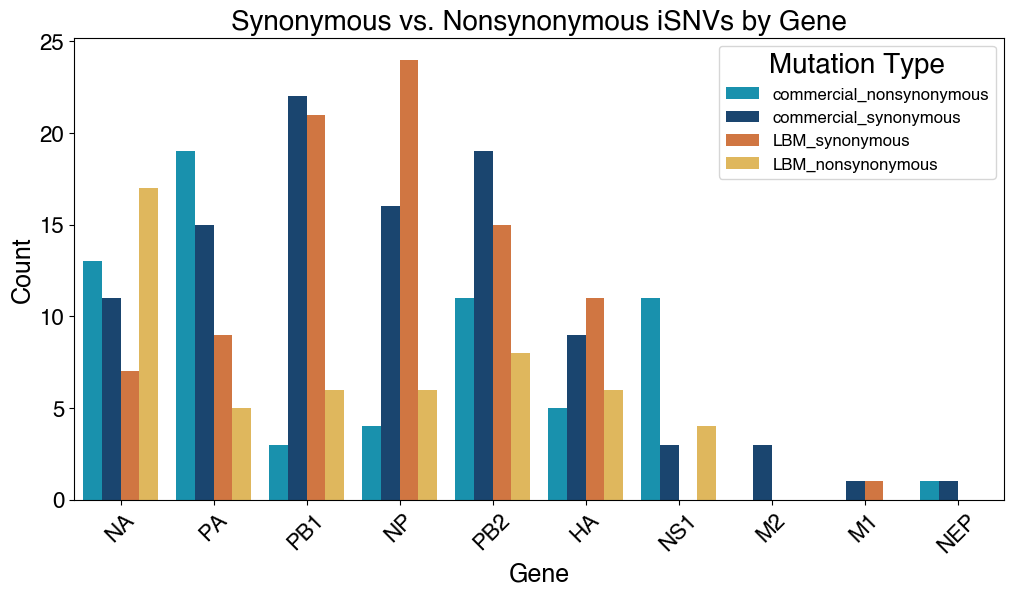

In [79]:
# import pandas as pd
# import seaborn as sns
# import matplotlib.pyplot as plt

# Example: If your dataframe is named df
plt.figure(figsize=(12, 6))  # Adjust figure size

sns.countplot(data=shared_vars, x="gene", hue="color", palette=["#00A1C6", "#0c457d", "#e8702a","#F5BF47", "#6bd2db" ])

# Labels and title
plt.xlabel("Gene")
plt.ylabel("Count")
plt.title("Synonymous vs. Nonsynonymous iSNVs by Gene")
plt.xticks(rotation=45)  # Rotate gene names if necessary
plt.legend(title="Mutation Type", fontsize=12, loc='best')

# plt.savefig("seq/analysis/figures/synnon_wildcom_SNVs_bygene.pdf", bbox_inches='tight', dpi=300)
plt.show()


In [66]:
shared_vars['gene_pos_nt'] = shared_vars['gene'] + "_" + shared_vars['position'].astype(str)
shared_vars.head(5)

/var/folders/8h/zkgpnzwj7f9d82wldp_d4h_w0000gs/T/ipykernel_6982/839993218.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  shared_vars['gene_pos_nt'] = shared_vars['gene'] + "_" + shared_vars['position'].astype(str)


,segment,position,allele,coding_region_change,gene,Frequency_1,Frequency_2,sample,amino_acid,gene_pos,...,rep_shared,order,county,date,species,species_group,color,avg_freq,order_domstat,gene_pos_nt
33,na,43,T,Ile8Thr,NA,0.3326,0.3412,c_com5,8,NA_8,...,shared,galliformes,unknown,2025-01-26,NaN,Galliformes,commercial_nonsynonymous,0.33690,galliformes_commercial,NA_43
34,na,67,T,Val16Ala,NA,0.2439,0.2890,c_com5,16,NA_16,...,shared,galliformes,unknown,2025-01-26,NaN,Galliformes,commercial_nonsynonymous,0.26645,galliformes_commercial,NA_67
35,na,76,T,Ile19Thr,NA,0.2454,0.2615,c_com5,19,NA_19,...,shared,galliformes,unknown,2025-01-26,NaN,Galliformes,commercial_nonsynonymous,0.25345,galliformes_commercial,NA_76
36,na,79,T,Ile20Thr,NA,0.2392,0.2624,c_com5,20,NA_20,...,shared,galliformes,unknown,2025-01-26,NaN,Galliformes,commercial_nonsynonymous,0.25080,galliformes_commercial,NA_79
39,pa,1173,C,Asp383Asp,PA,0.1338,0.1468,c_com5,383,PA_383,...,shared,galliformes,unknown,2025-01-26,NaN,Galliformes,commercial_synonymous,0.14030,galliformes_commercial,PA_1173


In [67]:
# shared_vars['sample_ID'].nunique()
shared_vars.groupby('order')['sample_ID'].nunique()

order
anseriformes    16
galliformes     20
Name: sample_ID, dtype: int64

In [51]:
shared_vars['date'] = pd.to_datetime(shared_vars['date'])

shared_vars['genotype'] = shared_vars['date'].dt.year.apply(lambda y: 'D1.1' if y == 2025 else 'B3.3')
shared_vars

/var/folders/8h/zkgpnzwj7f9d82wldp_d4h_w0000gs/T/ipykernel_96433/4277854008.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  shared_vars['date'] = pd.to_datetime(shared_vars['date'])
/var/folders/8h/zkgpnzwj7f9d82wldp_d4h_w0000gs/T/ipykernel_96433/4277854008.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  shared_vars['genotype'] = shared_vars['date'].dt.year.apply(lambda y: 'D1.1' if y == 2025 else 'B3.3')


,segment,position,allele,coding_region_change,gene,Frequency_1,Frequency_2,sample,amino_acid,gene_pos,...,rep_shared,order,county,date,species,species_group,color,avg_freq,order_domstat,genotype
33,na,43,T,Ile8Thr,NA,0.3326,0.3412,c_com5,8,NA_8,...,shared,galliformes,unknown,2025-01-26,NaN,Galliformes,commercial_nonsynonymous,0.33690,galliformes_commercial,D1.1
34,na,67,T,Val16Ala,NA,0.2439,0.2890,c_com5,16,NA_16,...,shared,galliformes,unknown,2025-01-26,NaN,Galliformes,commercial_nonsynonymous,0.26645,galliformes_commercial,D1.1
35,na,76,T,Ile19Thr,NA,0.2454,0.2615,c_com5,19,NA_19,...,shared,galliformes,unknown,2025-01-26,NaN,Galliformes,commercial_nonsynonymous,0.25345,galliformes_commercial,D1.1
36,na,79,T,Ile20Thr,NA,0.2392,0.2624,c_com5,20,NA_20,...,shared,galliformes,unknown,2025-01-26,NaN,Galliformes,commercial_nonsynonymous,0.25080,galliformes_commercial,D1.1
39,pa,1173,C,Asp383Asp,PA,0.1338,0.1468,c_com5,383,PA_383,...,shared,galliformes,unknown,2025-01-26,NaN,Galliformes,commercial_synonymous,0.14030,galliformes_commercial,D1.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1057,pb2,1560,A,Val511Val,PB2,0.0869,0.0918,kc_com6,511,PB2_511,...,shared,anseriformes,Chester,2023-02-23,duck,Anseriformes,commercial_synonymous,0.08935,anseriformes_commercial,B3.3
1058,pb2,1659,A,Ser544Ser,PB2,0.4205,0.4155,kc_com6,544,PB2_544,...,shared,anseriformes,Chester,2023-02-23,duck,Anseriformes,commercial_synonymous,0.41800,anseriformes_commercial,B3.3
1067,np,1023,T,Ser326Ser,NP,0.1652,0.0818,kc_com7,326,NP_326,...,shared,anseriformes,Chester,2023-02-23,duck,Anseriformes,commercial_synonymous,0.12350,anseriformes_commercial,B3.3
1081,pb2,1659,A,Ser544Ser,PB2,0.3472,0.3537,kc_com7,544,PB2_544,...,shared,anseriformes,Chester,2023-02-23,duck,Anseriformes,commercial_synonymous,0.35045,anseriformes_commercial,B3.3


In [86]:
# shared_vars.to_csv('../../seq/analysis/output_dfs/2026_02_20_repshared_SNVs_allcom_lbm.tsv', sep='\t', index=False)
# shared_vars.to_csv('../../seq/analysis/output_dfs/2026_04_08_repshared_SNVs_allcom_lbm_2pct.tsv', sep='\t', index=False)

filename = "../output_dfs/"+todays_date+"_repshared_SNVs_allcom_lbm_2pct.tsv"
shared_vars.to_csv(filename, sep='\t', index=False)


In [87]:
filename = "../output_dfs/"+todays_date+"_allSNVs_allcom_lbm.tsv"
vars.to_csv(filename, sep='\t', index=False)


In [49]:
plt.rc('font',**{'family':'sans-serif','sans-serif':['Arial']})
plt.rc('text', usetex='false') 
plt.rcParams.update({'font.size': 22})

/var/folders/8h/zkgpnzwj7f9d82wldp_d4h_w0000gs/T/ipykernel_6982/1640672788.py:66: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


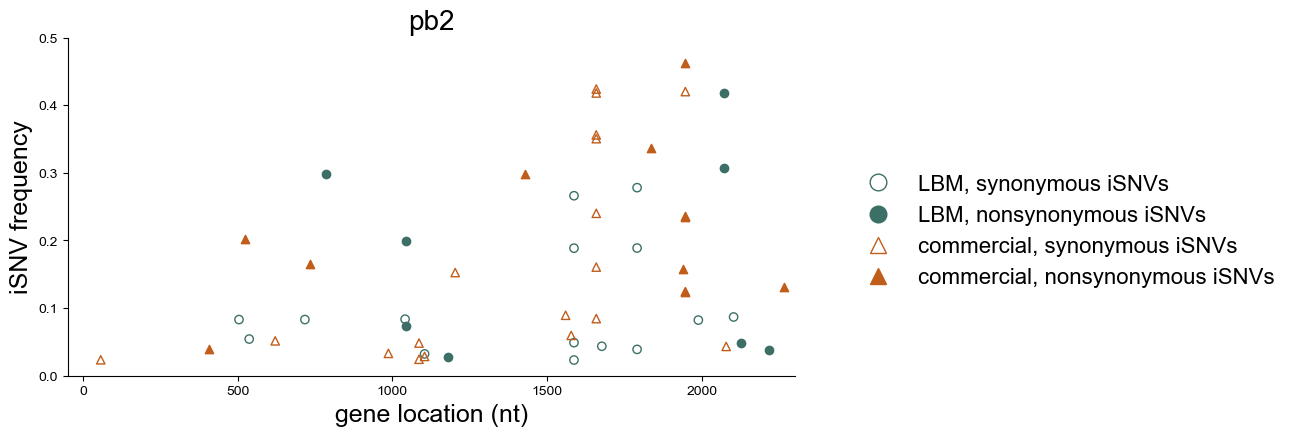

In [70]:
##define subset dfs by gene and category
pb2 = shared_vars[shared_vars["gene"] == "PB2"]
l_syn_pb2 = pb2[pb2["color"] == "LBM_synonymous"]
l_nonsyn_pb2 = pb2[pb2["color"] == "LBM_nonsynonymous"]
c_syn_pb2 = pb2[pb2["color"] == "commercial_synonymous"]
c_nonsyn_pb2 = pb2[pb2["color"] == "commercial_nonsynonymous"]

import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib as mpl
from matplotlib import gridspec

lbm_clr = '#3C7067'
comm_clr = '#C15D1A'


# pb2['color'] = pb2['color'].map(color_map)

# Create figure
fig = plt.figure(figsize=(10, 8), facecolor='w')
plt.style.use('default')
plt.rc('font', family='Arial')
gs = gridspec.GridSpec(2, 10)

ax1 = fig.add_subplot(gs[0, 0:8])  # PB2

# Set plot style
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['bottom'].set_visible(True)
ax1.spines['left'].set_visible(True)
ax1.tick_params(axis='both', which='major', labelsize=10)
ax1.tick_params(axis='both', which='minor', labelsize=10)

# Set axis labels and title
ax1.set_title('pb2', fontname='Arial', fontsize=20)
ax1.set_facecolor('white')
ax1.set_ylabel('iSNV frequency', fontname='Arial', fontsize=18)
ax1.set_xlabel('gene location (nt)', fontname='Arial', fontsize=18)

# Set axis limits and ticks
ax1.set_ylim(0, 0.5)
ax1.set_xlim(-50, 2300)
ax1.set_xticks([0, 500, 1000, 1500, 2000])


ax1.scatter(x=l_syn_pb2['position'], y=l_syn_pb2['avg_freq'], marker='o', facecolors='none', edgecolors=lbm_clr)
ax1.scatter(x=l_nonsyn_pb2['position'], y=l_nonsyn_pb2['avg_freq'], marker='o', facecolors=lbm_clr, edgecolors=lbm_clr)
ax1.scatter(x=c_syn_pb2['position'], y=c_syn_pb2['avg_freq'], marker='^', facecolors='none', edgecolors=comm_clr)
ax1.scatter(x=c_nonsyn_pb2['position'], y=c_nonsyn_pb2['avg_freq'], marker='^', facecolors=comm_clr, edgecolors=comm_clr)


# add a legend to this plot
l_syn = mlines.Line2D([], [], marker='o', markerfacecolor='None', markeredgecolor=lbm_clr, linestyle='None', markersize=12, label='LBM, synonymous iSNVs')
l_nonsyn = mlines.Line2D([], [], marker='o', markerfacecolor=lbm_clr, markeredgecolor=lbm_clr, linestyle='None', markersize=12, label='LBM, nonsynonymous iSNVs')
c_syn = mlines.Line2D([], [], marker='^', markerfacecolor='None', markeredgecolor=comm_clr, linestyle='None', markersize=12, label='commercial, synonymous iSNVs')
c_nonsyn = mlines.Line2D([], [], marker='^', markerfacecolor=comm_clr, markeredgecolor=comm_clr, linestyle='None', markersize=12, label='commercial, nonsynonymous iSNVs')

# Add the legend to the figure
fig.legend(handles=[l_syn, l_nonsyn, c_syn, c_nonsyn], frameon=False, fontsize=16, bbox_to_anchor=(1.3,0.8))



# Adjust layout and show plot
fig.tight_layout()
fig.show()

# Save plot
# fig.savefig("seq/analysis/figures/PB2.pdf", bbox_inches='tight', dpi=300)


/var/folders/8h/zkgpnzwj7f9d82wldp_d4h_w0000gs/T/ipykernel_27762/2037823075.py:66: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



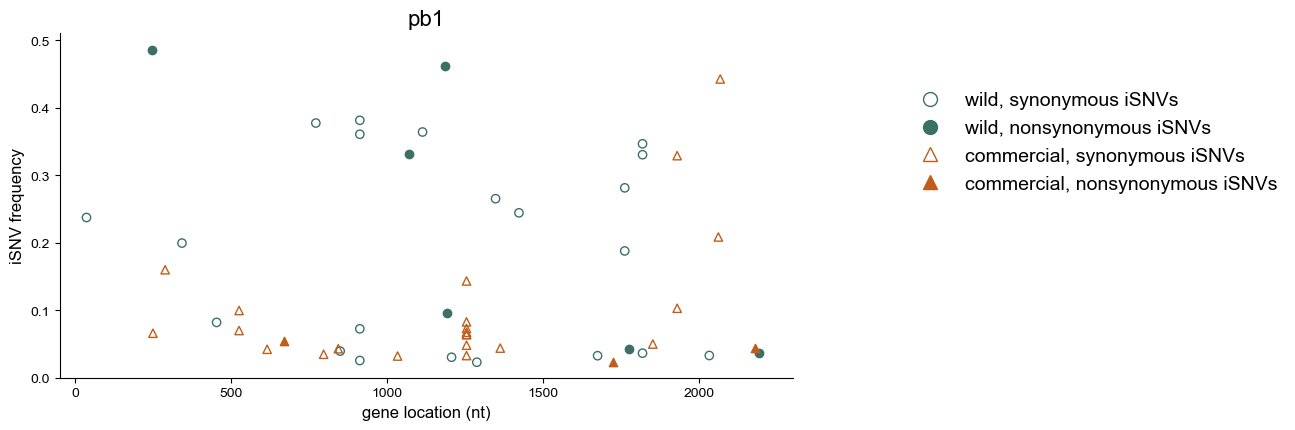

In [220]:
##define subset dfs by gene and category
pb1 = shared_vars[shared_vars["gene"] == "PB1"]
w_syn_pb1 = pb1[pb1["color"] == "LBM_synonymous"]
w_nonsyn_pb1 = pb1[pb1["color"] == "LBM_nonsynonymous"]
c_syn_pb1 = pb1[pb1["color"] == "commercial_synonymous"]
c_nonsyn_pb1 = pb1[pb1["color"] == "commercial_nonsynonymous"]

import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib as mpl
from matplotlib import gridspec

lbm_clr = '#3C7067'
comm_clr = '#C15D1A'


# pb1['color'] = pb1['color'].map(color_map)

# Create figure
fig = plt.figure(figsize=(10, 8), facecolor='w')
plt.style.use('default')
mpl.rc('font', family='Arial')
gs = gridspec.GridSpec(2, 10)

ax1 = fig.add_subplot(gs[0, 0:8])  # pb1

# Set plot style
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['bottom'].set_visible(True)
ax1.spines['left'].set_visible(True)
ax1.tick_params(axis='both', which='major', labelsize=10)
ax1.tick_params(axis='both', which='minor', labelsize=10)

# Set axis labels and title
ax1.set_title('pb1', fontname='Arial', fontsize=16)
ax1.set_facecolor('white')
ax1.set_ylabel('iSNV frequency', fontname='Arial', fontsize=12)
ax1.set_xlabel('gene location (nt)', fontname='Arial', fontsize=12)

# Set axis limits and ticks
ax1.set_ylim(0, 0.51)
ax1.set_xlim(-50, 2300)
ax1.set_xticks([0, 500, 1000, 1500, 2000])


ax1.scatter(x=w_syn_pb1['position'], y=w_syn_pb1['avg_freq'], marker='o', facecolors='none', edgecolors=lbm_clr)
ax1.scatter(x=w_nonsyn_pb1['position'], y=w_nonsyn_pb1['avg_freq'], marker='o', facecolors=lbm_clr, edgecolors=lbm_clr)
ax1.scatter(x=c_syn_pb1['position'], y=c_syn_pb1['avg_freq'], marker='^', facecolors='none', edgecolors=comm_clr)
ax1.scatter(x=c_nonsyn_pb1['position'], y=c_nonsyn_pb1['avg_freq'], marker='^', facecolors=comm_clr, edgecolors=comm_clr)


# add a legend to this plot
w_syn = mlines.Line2D([], [], marker='o', markerfacecolor='None', markeredgecolor=lbm_clr, linestyle='None', markersize=10, label='wild, synonymous iSNVs')
w_nonsyn = mlines.Line2D([], [], marker='o', markerfacecolor=lbm_clr, markeredgecolor=lbm_clr, linestyle='None', markersize=10, label='wild, nonsynonymous iSNVs')
c_syn = mlines.Line2D([], [], marker='^', markerfacecolor='None', markeredgecolor=comm_clr, linestyle='None', markersize=10, label='commercial, synonymous iSNVs')
c_nonsyn = mlines.Line2D([], [], marker='^', markerfacecolor=comm_clr, markeredgecolor=comm_clr, linestyle='None', markersize=10, label='commercial, nonsynonymous iSNVs')

# Add the legend to the figure
fig.legend(handles=[w_syn, w_nonsyn, c_syn, c_nonsyn], frameon=False, fontsize=14, bbox_to_anchor=(1.3,0.9))



# Adjust layout and show plot
fig.tight_layout()
fig.show()

# Save plot
# fig.savefig("seq/analysis/figures/pb1.pdf", bbox_inches='tight', dpi=300)


/var/folders/8h/zkgpnzwj7f9d82wldp_d4h_w0000gs/T/ipykernel_27762/4212356486.py:66: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



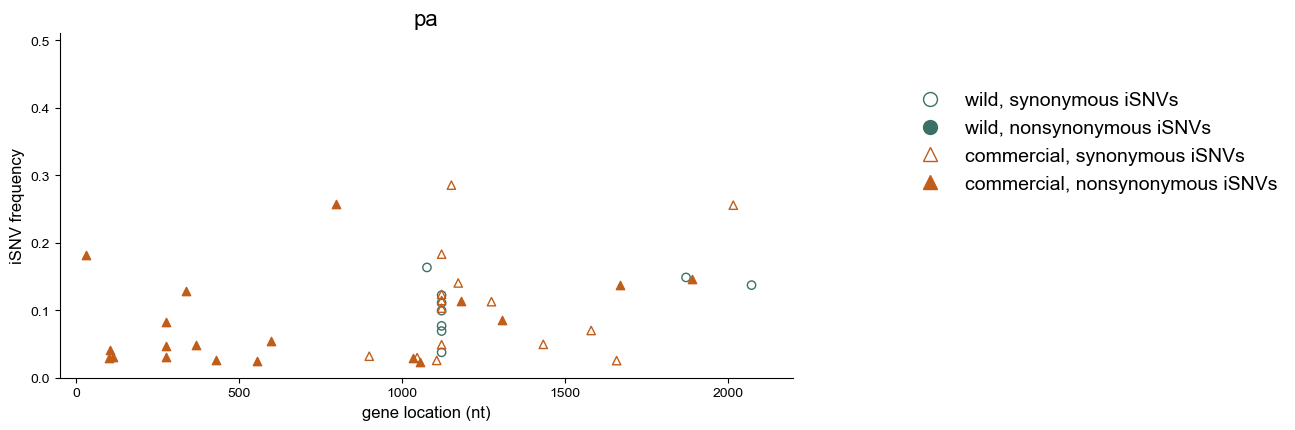

In [221]:
##define subset dfs by gene and category
pa = shared_vars[shared_vars["gene"] == "PA"]
w_syn_pa = pa[pa["color"] == "LBM_synonymous"]
w_nonsyn_pa = pa[pa["color"] == "wild_nonsynonymous"]
c_syn_pa = pa[pa["color"] == "commercial_synonymous"]
c_nonsyn_pa = pa[pa["color"] == "commercial_nonsynonymous"]

import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib as mpl
from matplotlib import gridspec

wild_clr = '#3C7067'
comm_clr = '#C15D1A'


# pa['color'] = pa['color'].map(color_map)

# Create figure
fig = plt.figure(figsize=(10, 8), facecolor='w')
plt.style.use('default')
mpl.rc('font', family='Arial')
gs = gridspec.GridSpec(2, 10)

ax1 = fig.add_subplot(gs[0, 0:8])  # pa

# Set plot style
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['bottom'].set_visible(True)
ax1.spines['left'].set_visible(True)
ax1.tick_params(axis='both', which='major', labelsize=10)
ax1.tick_params(axis='both', which='minor', labelsize=10)

# Set axis labels and title
ax1.set_title('pa', fontname='Arial', fontsize=16)
ax1.set_facecolor('white')
ax1.set_ylabel('iSNV frequency', fontname='Arial', fontsize=12)
ax1.set_xlabel('gene location (nt)', fontname='Arial', fontsize=12)

# Set axis limits and ticks
ax1.set_ylim(0, 0.51)
ax1.set_xlim(-50, 2200)
ax1.set_xticks([0, 500, 1000, 1500, 2000])


ax1.scatter(x=w_syn_pa['position'], y=w_syn_pa['avg_freq'], marker='o', facecolors='none', edgecolors=wild_clr)
ax1.scatter(x=w_nonsyn_pa['position'], y=w_nonsyn_pa['avg_freq'], marker='o', facecolors=wild_clr, edgecolors=wild_clr)
ax1.scatter(x=c_syn_pa['position'], y=c_syn_pa['avg_freq'], marker='^', facecolors='none', edgecolors=comm_clr)
ax1.scatter(x=c_nonsyn_pa['position'], y=c_nonsyn_pa['avg_freq'], marker='^', facecolors=comm_clr, edgecolors=comm_clr)


# add a legend to this plot
w_syn = mlines.Line2D([], [], marker='o', markerfacecolor='None', markeredgecolor=wild_clr, linestyle='None', markersize=10, label='wild, synonymous iSNVs')
w_nonsyn = mlines.Line2D([], [], marker='o', markerfacecolor=wild_clr, markeredgecolor=wild_clr, linestyle='None', markersize=10, label='wild, nonsynonymous iSNVs')
c_syn = mlines.Line2D([], [], marker='^', markerfacecolor='None', markeredgecolor=comm_clr, linestyle='None', markersize=10, label='commercial, synonymous iSNVs')
c_nonsyn = mlines.Line2D([], [], marker='^', markerfacecolor=comm_clr, markeredgecolor=comm_clr, linestyle='None', markersize=10, label='commercial, nonsynonymous iSNVs')

# Add the legend to the figure
fig.legend(handles=[w_syn, w_nonsyn, c_syn, c_nonsyn], frameon=False, fontsize=14, bbox_to_anchor=(1.3,0.9))



# Adjust layout and show plot
fig.tight_layout()
fig.show()

# Save plot
# fig.savefig("seq/analysis/figures/pa.pdf", bbox_inches='tight', dpi=300)


/var/folders/8h/zkgpnzwj7f9d82wldp_d4h_w0000gs/T/ipykernel_27762/3645012817.py:67: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



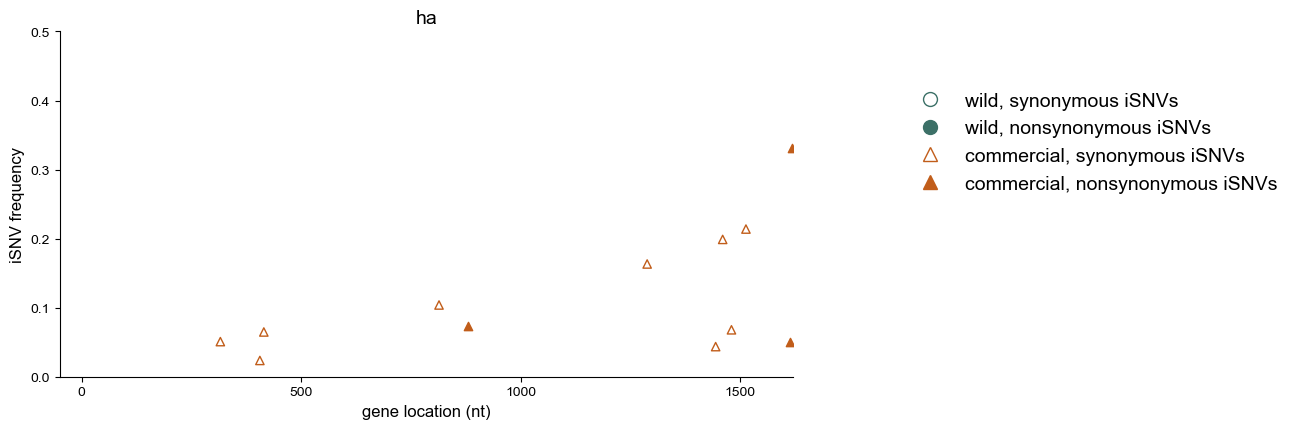

In [222]:
##define subset dfs by gene and category
ha = shared_vars[shared_vars["gene"] == "HA"]
w_syn_ha = ha[ha["color"] == "wild_synonymous"]
w_nonsyn_ha = ha[ha["color"] == "wild_nonsynonymous"]
c_syn_ha = ha[ha["color"] == "commercial_synonymous"]
c_nonsyn_ha = ha[ha["color"] == "commercial_nonsynonymous"]

import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib as mpl
from matplotlib import gridspec

wild_clr = '#3C7067'
comm_clr = '#C15D1A'


# ha['color'] = ha['color'].map(color_map)

# Create figure
fig = plt.figure(figsize=(10, 8), facecolor='w')
plt.style.use('default')
mpl.rc('font', family='Arial')
gs = gridspec.GridSpec(2, 10)

ax1 = fig.add_subplot(gs[0, 0:8])  # ha

# Set plot style
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['bottom'].set_visible(True)
ax1.spines['left'].set_visible(True)
ax1.tick_params(axis='both', which='major', labelsize=10)
ax1.tick_params(axis='both', which='minor', labelsize=10)

# Set axis labels and title
ax1.set_title('ha', fontname='Arial', fontsize=14)
ax1.set_facecolor('white')
ax1.set_ylabel('iSNV frequency', fontname='Arial', fontsize=12)
ax1.set_xlabel('gene location (nt)', fontname='Arial', fontsize=12)

# Set axis limits and ticks
ax1.set_ylim(0, 0.5)
ax1.set_xlim(-50,1620)
ax1.set_xticks([0, 500, 1000, 1500])



ax1.scatter(x=w_syn_ha['position'], y=w_syn_ha['avg_freq'], marker='o', facecolors='none', edgecolors=wild_clr)
ax1.scatter(x=w_nonsyn_ha['position'], y=w_nonsyn_ha['avg_freq'], marker='o', facecolors=wild_clr, edgecolors=wild_clr)
ax1.scatter(x=c_syn_ha['position'], y=c_syn_ha['avg_freq'], marker='^', facecolors='none', edgecolors=comm_clr)
ax1.scatter(x=c_nonsyn_ha['position'], y=c_nonsyn_ha['avg_freq'], marker='^', facecolors=comm_clr, edgecolors=comm_clr)


# add a legend to this plot
w_syn = mlines.Line2D([], [], marker='o', markerfacecolor='None', markeredgecolor=wild_clr, linestyle='None', markersize=10, label='wild, synonymous iSNVs')
w_nonsyn = mlines.Line2D([], [], marker='o', markerfacecolor=wild_clr, markeredgecolor=wild_clr, linestyle='None', markersize=10, label='wild, nonsynonymous iSNVs')
c_syn = mlines.Line2D([], [], marker='^', markerfacecolor='None', markeredgecolor=comm_clr, linestyle='None', markersize=10, label='commercial, synonymous iSNVs')
c_nonsyn = mlines.Line2D([], [], marker='^', markerfacecolor=comm_clr, markeredgecolor=comm_clr, linestyle='None', markersize=10, label='commercial, nonsynonymous iSNVs')

# Add the legend to the figure
fig.legend(handles=[w_syn, w_nonsyn, c_syn, c_nonsyn], frameon=False, fontsize=14, bbox_to_anchor=(1.3,0.9))



# Adjust layout and show plot
fig.tight_layout()
fig.show()

# Save plot
# fig.savefig("seq/analysis/figures/ha.pdf", bbox_inches='tight', dpi=300)


/var/folders/8h/zkgpnzwj7f9d82wldp_d4h_w0000gs/T/ipykernel_27762/132715313.py:66: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



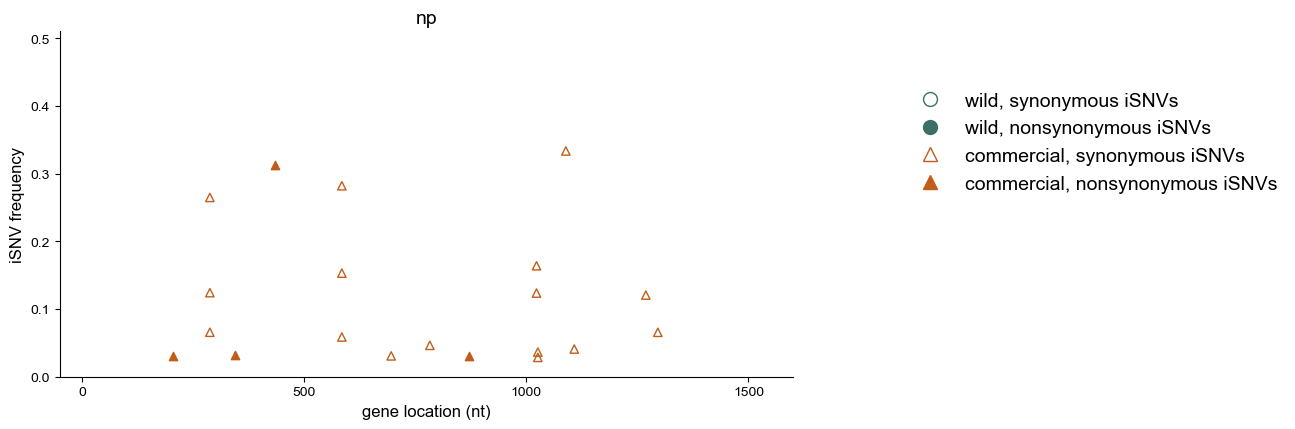

In [223]:
##define subset dfs by gene and category
np = shared_vars[shared_vars["gene"] == "NP"]
w_syn_np = np[np["color"] == "wild_synonymous"]
w_nonsyn_np = np[np["color"] == "wild_nonsynonymous"]
c_syn_np = np[np["color"] == "commercial_synonymous"]
c_nonsyn_np = np[np["color"] == "commercial_nonsynonymous"]

import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib as mpl
from matplotlib import gridspec

wild_clr = '#3C7067'
comm_clr = '#C15D1A'


# np['color'] = np['color'].map(color_map)

# Create figure
fig = plt.figure(figsize=(10, 8), facecolor='w')
plt.style.use('default')
mpl.rc('font', family='Arial')
gs = gridspec.GridSpec(2, 10)

ax1 = fig.add_subplot(gs[0, 0:8])  # np

# Set plot style
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['bottom'].set_visible(True)
ax1.spines['left'].set_visible(True)
ax1.tick_params(axis='both', which='major', labelsize=10)
ax1.tick_params(axis='both', which='minor', labelsize=10)

# Set axis labels and title
ax1.set_title('np', fontname='Arial', fontsize=14)
ax1.set_facecolor('white')
ax1.set_ylabel('iSNV frequency', fontname='Arial', fontsize=12)
ax1.set_xlabel('gene location (nt)', fontname='Arial', fontsize=12)

# Set axis limits and ticks
ax1.set_ylim(0, 0.51)
ax1.set_xlim(-50, 1600)
ax1.set_xticks([0, 500, 1000, 1500])


ax1.scatter(x=w_syn_np['position'], y=w_syn_np['avg_freq'], marker='o', facecolors='none', edgecolors=wild_clr)
ax1.scatter(x=w_nonsyn_np['position'], y=w_nonsyn_np['avg_freq'], marker='o', facecolors=wild_clr, edgecolors=wild_clr)
ax1.scatter(x=c_syn_np['position'], y=c_syn_np['avg_freq'], marker='^', facecolors='none', edgecolors=comm_clr)
ax1.scatter(x=c_nonsyn_np['position'], y=c_nonsyn_np['avg_freq'], marker='^', facecolors=comm_clr, edgecolors=comm_clr)


# add a legend to this plot
w_syn = mlines.Line2D([], [], marker='o', markerfacecolor='None', markeredgecolor=wild_clr, linestyle='None', markersize=10, label='wild, synonymous iSNVs')
w_nonsyn = mlines.Line2D([], [], marker='o', markerfacecolor=wild_clr, markeredgecolor=wild_clr, linestyle='None', markersize=10, label='wild, nonsynonymous iSNVs')
c_syn = mlines.Line2D([], [], marker='^', markerfacecolor='None', markeredgecolor=comm_clr, linestyle='None', markersize=10, label='commercial, synonymous iSNVs')
c_nonsyn = mlines.Line2D([], [], marker='^', markerfacecolor=comm_clr, markeredgecolor=comm_clr, linestyle='None', markersize=10, label='commercial, nonsynonymous iSNVs')

# Add the legend to the figure
fig.legend(handles=[w_syn, w_nonsyn, c_syn, c_nonsyn], frameon=False, fontsize=14, bbox_to_anchor=(1.3,0.9))



# Adjust layout and show plot
fig.tight_layout()
fig.show()

# Save plot
# fig.savefig("seq/analysis/figures/np.pdf", bbox_inches='tight', dpi=300)


/var/folders/8h/zkgpnzwj7f9d82wldp_d4h_w0000gs/T/ipykernel_27762/559469694.py:66: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



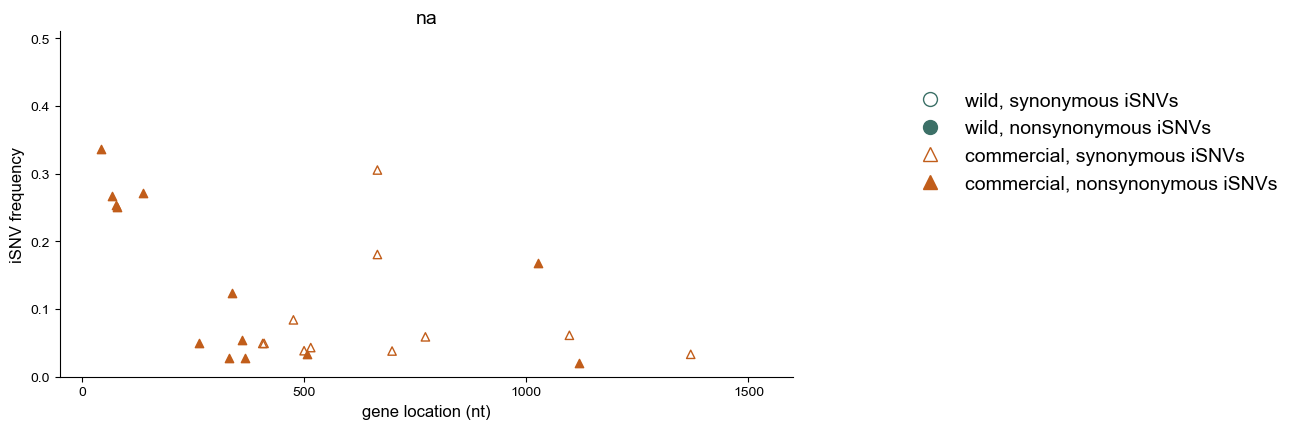

In [224]:
##define subset dfs by gene and category
na = shared_vars[shared_vars["gene"] == "NA"]
w_syn_na = na[na["color"] == "wild_synonymous"]
w_nonsyn_na = na[na["color"] == "wild_nonsynonymous"]
c_syn_na = na[na["color"] == "commercial_synonymous"]
c_nonsyn_na = na[na["color"] == "commercial_nonsynonymous"]

import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib as mpl
from matplotlib import gridspec

wild_clr = '#3C7067'
comm_clr = '#C15D1A'


# na['color'] = na['color'].map(color_map)

# Create figure
fig = plt.figure(figsize=(10, 8), facecolor='w')
plt.style.use('default')
mpl.rc('font', family='Arial')
gs = gridspec.GridSpec(2, 10)

ax1 = fig.add_subplot(gs[0, 0:8])  # na

# Set plot style
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['bottom'].set_visible(True)
ax1.spines['left'].set_visible(True)
ax1.tick_params(axis='both', which='major', labelsize=10)
ax1.tick_params(axis='both', which='minor', labelsize=10)

# Set axis labels and title
ax1.set_title('na', fontname='Arial', fontsize=14)
ax1.set_facecolor('white')
ax1.set_ylabel('iSNV frequency', fontname='Arial', fontsize=12)
ax1.set_xlabel('gene location (nt)', fontname='Arial', fontsize=12)

# Set axis limits and ticks
ax1.set_ylim(0, 0.51)
ax1.set_xlim(-50, 1600)
ax1.set_xticks([0, 500, 1000, 1500])


ax1.scatter(x=w_syn_na['position'], y=w_syn_na['avg_freq'], marker='o', facecolors='none', edgecolors=wild_clr)
ax1.scatter(x=w_nonsyn_na['position'], y=w_nonsyn_na['avg_freq'], marker='o', facecolors=wild_clr, edgecolors=wild_clr)
ax1.scatter(x=c_syn_na['position'], y=c_syn_na['avg_freq'], marker='^', facecolors='none', edgecolors=comm_clr)
ax1.scatter(x=c_nonsyn_na['position'], y=c_nonsyn_na['avg_freq'], marker='^', facecolors=comm_clr, edgecolors=comm_clr)


# add a legend to this plot
w_syn = mlines.Line2D([], [], marker='o', markerfacecolor='None', markeredgecolor=wild_clr, linestyle='None', markersize=10, label='wild, synonymous iSNVs')
w_nonsyn = mlines.Line2D([], [], marker='o', markerfacecolor=wild_clr, markeredgecolor=wild_clr, linestyle='None', markersize=10, label='wild, nonsynonymous iSNVs')
c_syn = mlines.Line2D([], [], marker='^', markerfacecolor='None', markeredgecolor=comm_clr, linestyle='None', markersize=10, label='commercial, synonymous iSNVs')
c_nonsyn = mlines.Line2D([], [], marker='^', markerfacecolor=comm_clr, markeredgecolor=comm_clr, linestyle='None', markersize=10, label='commercial, nonsynonymous iSNVs')

# Add the legend to the figure
fig.legend(handles=[w_syn, w_nonsyn, c_syn, c_nonsyn], frameon=False, fontsize=14, bbox_to_anchor=(1.3,0.9))



# Adjust layout and show plot
fig.tight_layout()
fig.show()

# Save plot
# fig.savefig("seq/analysis/figures/na.pdf", bbox_inches='tight', dpi=300)


/var/folders/8h/zkgpnzwj7f9d82wldp_d4h_w0000gs/T/ipykernel_27762/4052062938.py:61: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



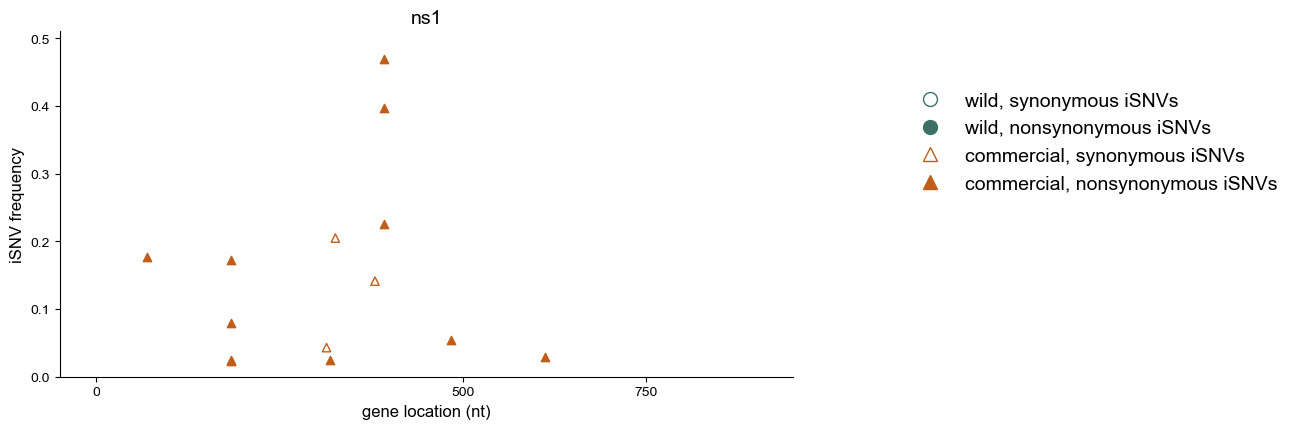

In [225]:
##define subset dfs by gene and category
ns1 = shared_vars[shared_vars["gene"] == "NS1"]
w_syn_ns1 = ns1[ns1["color"] == "wild_synonymous"]
w_nonsyn_ns1 = ns1[ns1["color"] == "wild_nonsynonymous"]
c_syn_ns1 = ns1[ns1["color"] == "commercial_synonymous"]
c_nonsyn_ns1 = ns1[ns1["color"] == "commercial_nonsynonymous"]

wild_clr = '#3C7067'
comm_clr = '#C15D1A'


# ns1['color'] = ns1['color'].map(color_map)

# Create figure
fig = plt.figure(figsize=(10, 8), facecolor='w')
plt.style.use('default')
mpl.rc('font', family='Arial')
gs = gridspec.GridSpec(2, 10)

ax1 = fig.add_subplot(gs[0, 0:8])  # ns1

# Set plot style
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['bottom'].set_visible(True)
ax1.spines['left'].set_visible(True)
ax1.tick_params(axis='both', which='major', labelsize=10)
ax1.tick_params(axis='both', which='minor', labelsize=10)

# Set axis labels and title
ax1.set_title('ns1', fontname='Arial', fontsize=14)
ax1.set_facecolor('white')
ax1.set_ylabel('iSNV frequency', fontname='Arial', fontsize=12)
ax1.set_xlabel('gene location (nt)', fontname='Arial', fontsize=12)

# Set axis limits and ticks
ax1.set_ylim(0, 0.51)
ax1.set_xlim(-50, 950)
ax1.set_xticks([0, 500, 750])


ax1.scatter(x=w_syn_ns1['position'], y=w_syn_ns1['avg_freq'], marker='o', facecolors='none', edgecolors=wild_clr)
ax1.scatter(x=w_nonsyn_ns1['position'], y=w_nonsyn_ns1['avg_freq'], marker='o', facecolors=wild_clr, edgecolors=wild_clr)
ax1.scatter(x=c_syn_ns1['position'], y=c_syn_ns1['avg_freq'], marker='^', facecolors='none', edgecolors=comm_clr)
ax1.scatter(x=c_nonsyn_ns1['position'], y=c_nonsyn_ns1['avg_freq'], marker='^', facecolors=comm_clr, edgecolors=comm_clr)


# add a legend to this plot
w_syn = mlines.Line2D([], [], marker='o', markerfacecolor='None', markeredgecolor=wild_clr, linestyle='None', markersize=10, label='wild, synonymous iSNVs')
w_nonsyn = mlines.Line2D([], [], marker='o', markerfacecolor=wild_clr, markeredgecolor=wild_clr, linestyle='None', markersize=10, label='wild, nonsynonymous iSNVs')
c_syn = mlines.Line2D([], [], marker='^', markerfacecolor='None', markeredgecolor=comm_clr, linestyle='None', markersize=10, label='commercial, synonymous iSNVs')
c_nonsyn = mlines.Line2D([], [], marker='^', markerfacecolor=comm_clr, markeredgecolor=comm_clr, linestyle='None', markersize=10, label='commercial, nonsynonymous iSNVs')

# Add the legend to the figure
fig.legend(handles=[w_syn, w_nonsyn, c_syn, c_nonsyn], frameon=False, fontsize=14, bbox_to_anchor=(1.3,0.9))



# Adjust layout and show plot
fig.tight_layout()
fig.show()

# Save plot
# fig.savefig("seq/analysis/figures/ns1.pdf", bbox_inches='tight', dpi=300)


/var/folders/8h/zkgpnzwj7f9d82wldp_d4h_w0000gs/T/ipykernel_27762/738485751.py:59: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



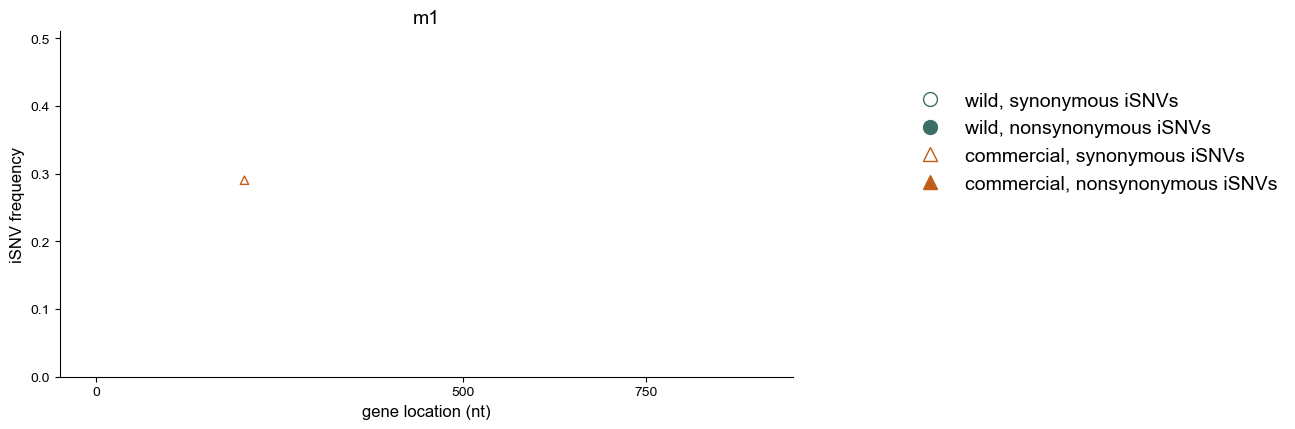

In [226]:
##define subset dfs by gene and category
m1 = shared_vars[shared_vars["gene"] == "M1"]
w_syn_m1 = m1[m1["color"] == "wild_synonymous"]
w_nonsyn_m1 = m1[m1["color"] == "wild_nonsynonymous"]
c_syn_m1 = m1[m1["color"] == "commercial_synonymous"]
c_nonsyn_m1 = m1[m1["color"] == "commercial_nonsynonymous"]

wild_clr = '#3C7067'
comm_clr = '#C15D1A'


# Create figure
fig = plt.figure(figsize=(10, 8), facecolor='w')
plt.style.use('default')
mpl.rc('font', family='Arial')
gs = gridspec.GridSpec(2, 10)

ax1 = fig.add_subplot(gs[0, 0:8])  # m1

# Set plot style
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['bottom'].set_visible(True)
ax1.spines['left'].set_visible(True)
ax1.tick_params(axis='both', which='major', labelsize=10)
ax1.tick_params(axis='both', which='minor', labelsize=10)

# Set axis labels and title
ax1.set_title('m1', fontname='Arial', fontsize=14)
ax1.set_facecolor('white')
ax1.set_ylabel('iSNV frequency', fontname='Arial', fontsize=12)
ax1.set_xlabel('gene location (nt)', fontname='Arial', fontsize=12)

# Set axis limits and ticks
ax1.set_ylim(0, 0.51)
ax1.set_xlim(-50, 950)
ax1.set_xticks([0, 500, 750])


ax1.scatter(x=w_syn_m1['position'], y=w_syn_m1['avg_freq'], marker='o', facecolors='none', edgecolors=wild_clr)
ax1.scatter(x=w_nonsyn_m1['position'], y=w_nonsyn_m1['avg_freq'], marker='o', facecolors=wild_clr, edgecolors=wild_clr)
ax1.scatter(x=c_syn_m1['position'], y=c_syn_m1['avg_freq'], marker='^', facecolors='none', edgecolors=comm_clr)
ax1.scatter(x=c_nonsyn_m1['position'], y=c_nonsyn_m1['avg_freq'], marker='^', facecolors=comm_clr, edgecolors=comm_clr)


# add a legend to this plot
w_syn = mlines.Line2D([], [], marker='o', markerfacecolor='None', markeredgecolor=wild_clr, linestyle='None', markersize=10, label='wild, synonymous iSNVs')
w_nonsyn = mlines.Line2D([], [], marker='o', markerfacecolor=wild_clr, markeredgecolor=wild_clr, linestyle='None', markersize=10, label='wild, nonsynonymous iSNVs')
c_syn = mlines.Line2D([], [], marker='^', markerfacecolor='None', markeredgecolor=comm_clr, linestyle='None', markersize=10, label='commercial, synonymous iSNVs')
c_nonsyn = mlines.Line2D([], [], marker='^', markerfacecolor=comm_clr, markeredgecolor=comm_clr, linestyle='None', markersize=10, label='commercial, nonsynonymous iSNVs')

# Add the legend to the figure
fig.legend(handles=[w_syn, w_nonsyn, c_syn, c_nonsyn], frameon=False, fontsize=14, bbox_to_anchor=(1.3,0.9))



# Adjust layout and show plot
fig.tight_layout()
fig.show()

# Save plot
# fig.savefig("seq/analysis/figures/m1.pdf", bbox_inches='tight', dpi=300)


/var/folders/8h/zkgpnzwj7f9d82wldp_d4h_w0000gs/T/ipykernel_27762/3740431628.py:59: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



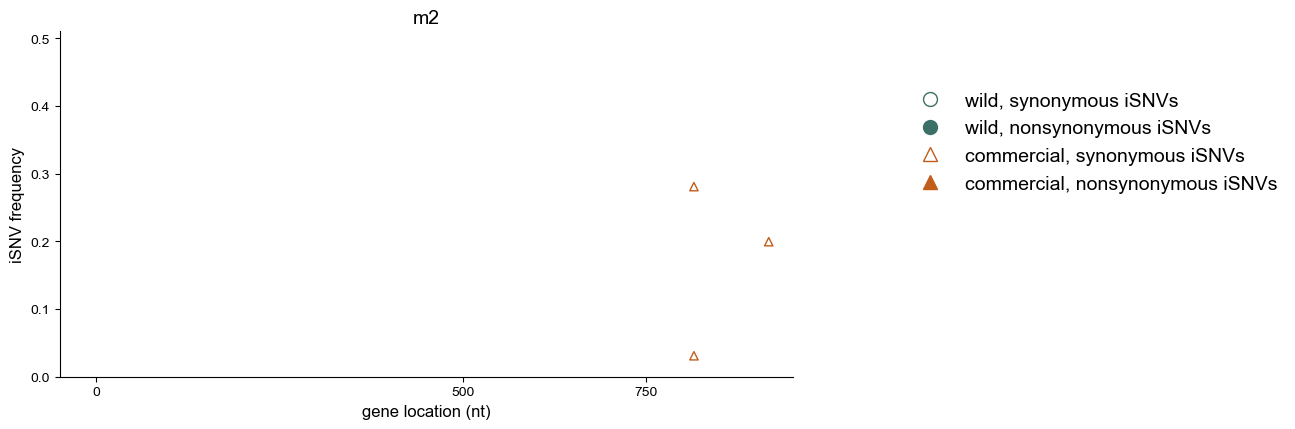

In [227]:
##define subset dfs by gene and category
m2 = shared_vars[shared_vars["gene"] == "M2"]
w_syn_m2 = m2[m2["color"] == "wild_synonymous"]
w_nonsyn_m2 = m2[m2["color"] == "wild_nonsynonymous"]
c_syn_m2 = m2[m2["color"] == "commercial_synonymous"]
c_nonsyn_m2 = m2[m2["color"] == "commercial_nonsynonymous"]

wild_clr = '#3C7067'
comm_clr = '#C15D1A'


# Create figure
fig = plt.figure(figsize=(10, 8), facecolor='w')
plt.style.use('default')
mpl.rc('font', family='Arial')
gs = gridspec.GridSpec(2, 10)

ax1 = fig.add_subplot(gs[0, 0:8])  # m2

# Set plot style
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['bottom'].set_visible(True)
ax1.spines['left'].set_visible(True)
ax1.tick_params(axis='both', which='major', labelsize=10)
ax1.tick_params(axis='both', which='minor', labelsize=10)

# Set axis labels and title
ax1.set_title('m2', fontname='Arial', fontsize=14)
ax1.set_facecolor('white')
ax1.set_ylabel('iSNV frequency', fontname='Arial', fontsize=12)
ax1.set_xlabel('gene location (nt)', fontname='Arial', fontsize=12)

# Set axis limits and ticks
ax1.set_ylim(0, 0.51)
ax1.set_xlim(-50, 950)
ax1.set_xticks([0, 500, 750])


ax1.scatter(x=w_syn_m2['position'], y=w_syn_m2['avg_freq'], marker='o', facecolors='none', edgecolors=wild_clr)
ax1.scatter(x=w_nonsyn_m2['position'], y=w_nonsyn_m2['avg_freq'], marker='o', facecolors=wild_clr, edgecolors=wild_clr)
ax1.scatter(x=c_syn_m2['position'], y=c_syn_m2['avg_freq'], marker='^', facecolors='none', edgecolors=comm_clr)
ax1.scatter(x=c_nonsyn_m2['position'], y=c_nonsyn_m2['avg_freq'], marker='^', facecolors=comm_clr, edgecolors=comm_clr)


# add a legend to this plot
w_syn = mlines.Line2D([], [], marker='o', markerfacecolor='None', markeredgecolor=wild_clr, linestyle='None', markersize=10, label='wild, synonymous iSNVs')
w_nonsyn = mlines.Line2D([], [], marker='o', markerfacecolor=wild_clr, markeredgecolor=wild_clr, linestyle='None', markersize=10, label='wild, nonsynonymous iSNVs')
c_syn = mlines.Line2D([], [], marker='^', markerfacecolor='None', markeredgecolor=comm_clr, linestyle='None', markersize=10, label='commercial, synonymous iSNVs')
c_nonsyn = mlines.Line2D([], [], marker='^', markerfacecolor=comm_clr, markeredgecolor=comm_clr, linestyle='None', markersize=10, label='commercial, nonsynonymous iSNVs')

# Add the legend to the figure
fig.legend(handles=[w_syn, w_nonsyn, c_syn, c_nonsyn], frameon=False, fontsize=14, bbox_to_anchor=(1.3,0.9))



# Adjust layout and show plot
fig.tight_layout()
fig.show()

# Save plot
# fig.savefig("seq/analysis/figures/m2.pdf", bbox_inches='tight', dpi=300)


/var/folders/8h/zkgpnzwj7f9d82wldp_d4h_w0000gs/T/ipykernel_27762/3752421598.py:59: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



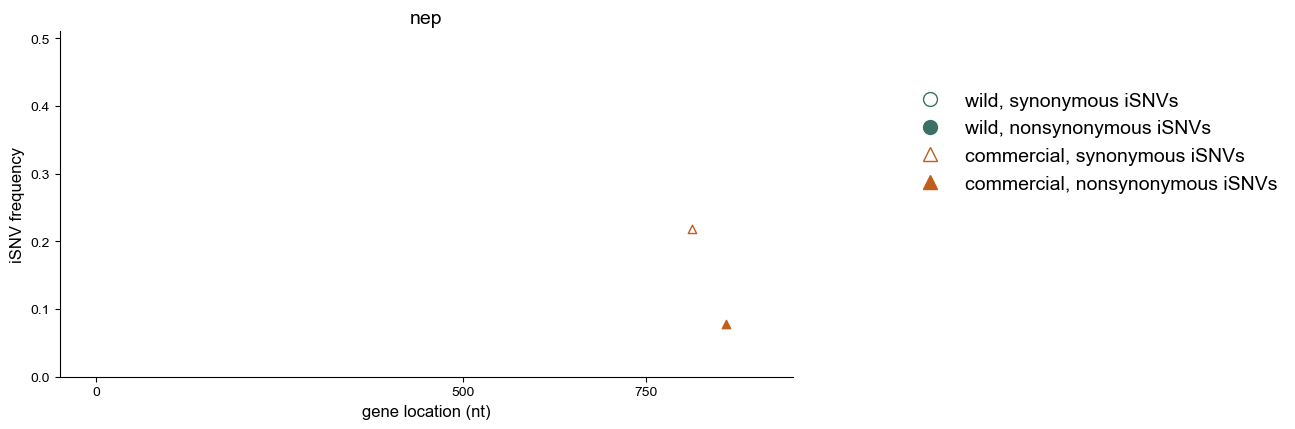

In [228]:
##define subset dfs by gene and category
nep = shared_vars[shared_vars["gene"] == "NEP"]
w_syn_nep = nep[nep["color"] == "wild_synonymous"]
w_nonsyn_nep = nep[nep["color"] == "wild_nonsynonymous"]
c_syn_nep = nep[nep["color"] == "commercial_synonymous"]
c_nonsyn_nep = nep[nep["color"] == "commercial_nonsynonymous"]

wild_clr = '#3C7067'
comm_clr = '#C15D1A'


# Create figure
fig = plt.figure(figsize=(10, 8), facecolor='w')
plt.style.use('default')
mpl.rc('font', family='Arial')
gs = gridspec.GridSpec(2, 10)

ax1 = fig.add_subplot(gs[0, 0:8])  # nep

# Set plot style
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['bottom'].set_visible(True)
ax1.spines['left'].set_visible(True)
ax1.tick_params(axis='both', which='major', labelsize=10)
ax1.tick_params(axis='both', which='minor', labelsize=10)

# Set axis labels and title
ax1.set_title('nep', fontname='Arial', fontsize=14)
ax1.set_facecolor('white')
ax1.set_ylabel('iSNV frequency', fontname='Arial', fontsize=12)
ax1.set_xlabel('gene location (nt)', fontname='Arial', fontsize=12)

# Set axis limits and ticks
ax1.set_ylim(0, 0.51)
ax1.set_xlim(-50, 950)
ax1.set_xticks([0, 500, 750])


ax1.scatter(x=w_syn_nep['position'], y=w_syn_nep['avg_freq'], marker='o', facecolors='none', edgecolors=wild_clr)
ax1.scatter(x=w_nonsyn_nep['position'], y=w_nonsyn_nep['avg_freq'], marker='o', facecolors=wild_clr, edgecolors=wild_clr)
ax1.scatter(x=c_syn_nep['position'], y=c_syn_nep['avg_freq'], marker='^', facecolors='none', edgecolors=comm_clr)
ax1.scatter(x=c_nonsyn_nep['position'], y=c_nonsyn_nep['avg_freq'], marker='^', facecolors=comm_clr, edgecolors=comm_clr)


# add a legend to this plot
w_syn = mlines.Line2D([], [], marker='o', markerfacecolor='None', markeredgecolor=wild_clr, linestyle='None', markersize=10, label='wild, synonymous iSNVs')
w_nonsyn = mlines.Line2D([], [], marker='o', markerfacecolor=wild_clr, markeredgecolor=wild_clr, linestyle='None', markersize=10, label='wild, nonsynonymous iSNVs')
c_syn = mlines.Line2D([], [], marker='^', markerfacecolor='None', markeredgecolor=comm_clr, linestyle='None', markersize=10, label='commercial, synonymous iSNVs')
c_nonsyn = mlines.Line2D([], [], marker='^', markerfacecolor=comm_clr, markeredgecolor=comm_clr, linestyle='None', markersize=10, label='commercial, nonsynonymous iSNVs')

# Add the legend to the figure
fig.legend(handles=[w_syn, w_nonsyn, c_syn, c_nonsyn], frameon=False, fontsize=14, bbox_to_anchor=(1.3,0.9))



# Adjust layout and show plot
fig.tight_layout()
fig.show()

# Save plot
# fig.savefig("seq/analysis/figures/nep.pdf", bbox_inches='tight', dpi=300)


/var/folders/8h/zkgpnzwj7f9d82wldp_d4h_w0000gs/T/ipykernel_27762/1911754324.py:89: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



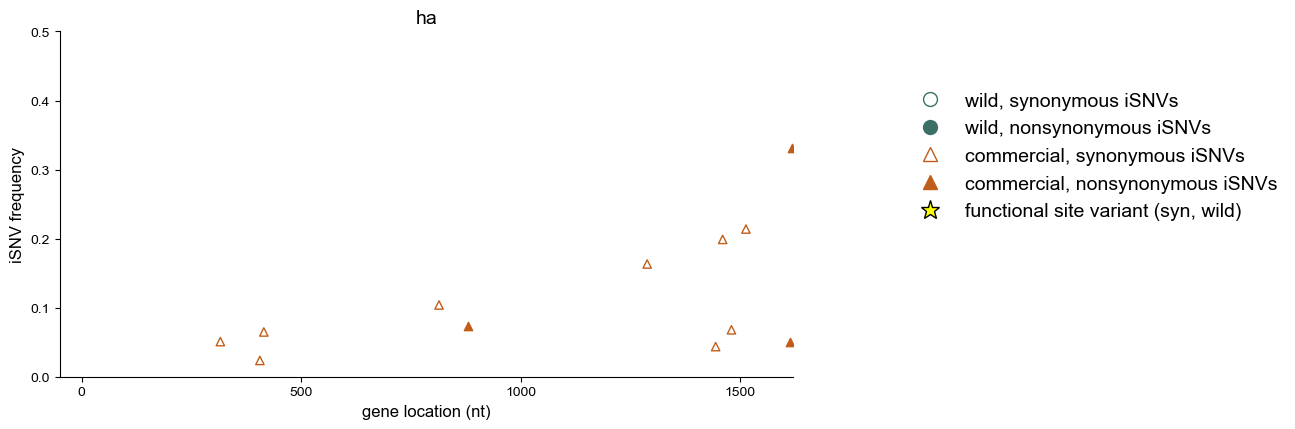

In [229]:
##version to highlihgt functional sites!!
##define subset dfs by gene and category
ha = shared_vars[shared_vars["gene"] == "HA"]
w_syn_ha = ha[ha["color"] == "wild_synonymous"]
w_nonsyn_ha = ha[ha["color"] == "wild_nonsynonymous"]
c_syn_ha = ha[ha["color"] == "commercial_synonymous"]
c_nonsyn_ha = ha[ha["color"] == "commercial_nonsynonymous"]

import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib as mpl
from matplotlib import gridspec

wild_clr = '#3C7067'
comm_clr = '#C15D1A'


# ha['color'] = ha['color'].map(color_map)

# Create figure
fig = plt.figure(figsize=(10, 8), facecolor='w')
plt.style.use('default')
mpl.rc('font', family='Arial')
gs = gridspec.GridSpec(2, 10)

ax1 = fig.add_subplot(gs[0, 0:8])  # ha

# Set plot style
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['bottom'].set_visible(True)
ax1.spines['left'].set_visible(True)
ax1.tick_params(axis='both', which='major', labelsize=10)
ax1.tick_params(axis='both', which='minor', labelsize=10)

# Set axis labels and title
ax1.set_title('ha', fontname='Arial', fontsize=14)
ax1.set_facecolor('white')
ax1.set_ylabel('iSNV frequency', fontname='Arial', fontsize=12)
ax1.set_xlabel('gene location (nt)', fontname='Arial', fontsize=12)

# Set axis limits and ticks
ax1.set_ylim(0, 0.5)
ax1.set_xlim(-50,1620)
ax1.set_xticks([0, 500, 1000, 1500])



ax1.scatter(x=w_syn_ha['position'], y=w_syn_ha['avg_freq'], marker='o', facecolors='none', edgecolors=wild_clr)
ax1.scatter(x=w_nonsyn_ha['position'], y=w_nonsyn_ha['avg_freq'], marker='o', facecolors=wild_clr, edgecolors=wild_clr)
ax1.scatter(x=c_syn_ha['position'], y=c_syn_ha['avg_freq'], marker='^', facecolors='none', edgecolors=comm_clr)
ax1.scatter(x=c_nonsyn_ha['position'], y=c_nonsyn_ha['avg_freq'], marker='^', facecolors=comm_clr, edgecolors=comm_clr)

# Define positions to highlight
highlight_positions = [625, 709]

# Extract corresponding rows
highlight_points = ha[ha["position"].isin(highlight_positions)]

# Plot yellow stars
ax1.scatter(
    x=highlight_points['position'],
    y=highlight_points['avg_freq'],
    marker='*',
    color='yellow',
    edgecolor='black',
    s=150,
    zorder=10  # ensure it's on top
)



# add a legend to this plot
w_syn = mlines.Line2D([], [], marker='o', markerfacecolor='None', markeredgecolor=wild_clr, linestyle='None', markersize=10, label='wild, synonymous iSNVs')
w_nonsyn = mlines.Line2D([], [], marker='o', markerfacecolor=wild_clr, markeredgecolor=wild_clr, linestyle='None', markersize=10, label='wild, nonsynonymous iSNVs')
c_syn = mlines.Line2D([], [], marker='^', markerfacecolor='None', markeredgecolor=comm_clr, linestyle='None', markersize=10, label='commercial, synonymous iSNVs')
c_nonsyn = mlines.Line2D([], [], marker='^', markerfacecolor=comm_clr, markeredgecolor=comm_clr, linestyle='None', markersize=10, label='commercial, nonsynonymous iSNVs')

# Add the legend to the figure
# fig.legend(handles=[w_syn, w_nonsyn, c_syn, c_nonsyn], frameon=False, fontsize=14, bbox_to_anchor=(1.3,0.9))

highlight_legend = mlines.Line2D([], [], marker='*', color='yellow', markeredgecolor='black',
                                 linestyle='None', markersize=14, label='functional site variant (syn, wild)')
fig.legend(handles=[w_syn, w_nonsyn, c_syn, c_nonsyn, highlight_legend], 
           frameon=False, fontsize=14, bbox_to_anchor=(1.3, 0.9))

# Adjust layout and show plot
fig.tight_layout()
fig.show()

# Save plot
# fig.savefig("seq/analysis/figures/ha_funcsites_highlight.pdf", bbox_inches='tight', dpi=300)


/var/folders/8h/zkgpnzwj7f9d82wldp_d4h_w0000gs/T/ipykernel_27762/4202734225.py:85: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



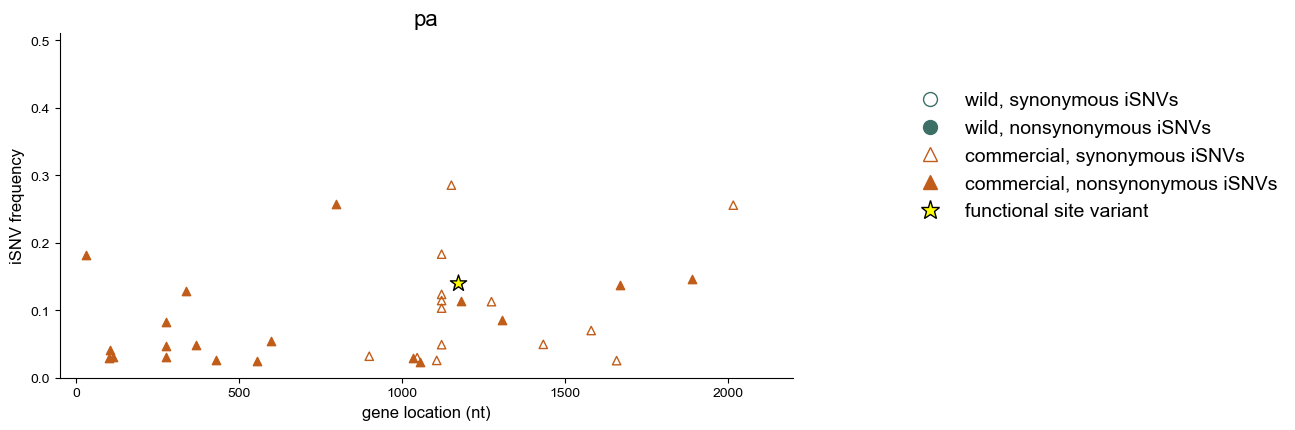

In [230]:
##define subset dfs by gene and category
pa = shared_vars[shared_vars["gene"] == "PA"]
w_syn_pa = pa[pa["color"] == "wild_synonymous"]
w_nonsyn_pa = pa[pa["color"] == "wild_nonsynonymous"]
c_syn_pa = pa[pa["color"] == "commercial_synonymous"]
c_nonsyn_pa = pa[pa["color"] == "commercial_nonsynonymous"]

import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib as mpl
from matplotlib import gridspec

wild_clr = '#3C7067'
comm_clr = '#C15D1A'


# pa['color'] = pa['color'].map(color_map)

# Create figure
fig = plt.figure(figsize=(10, 8), facecolor='w')
plt.style.use('default')
mpl.rc('font', family='Arial')
gs = gridspec.GridSpec(2, 10)

ax1 = fig.add_subplot(gs[0, 0:8])  # pa

# Set plot style
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['bottom'].set_visible(True)
ax1.spines['left'].set_visible(True)
ax1.tick_params(axis='both', which='major', labelsize=10)
ax1.tick_params(axis='both', which='minor', labelsize=10)

# Set axis labels and title
ax1.set_title('pa', fontname='Arial', fontsize=16)
ax1.set_facecolor('white')
ax1.set_ylabel('iSNV frequency', fontname='Arial', fontsize=12)
ax1.set_xlabel('gene location (nt)', fontname='Arial', fontsize=12)

# Set axis limits and ticks
ax1.set_ylim(0, 0.51)
ax1.set_xlim(-50, 2200)
ax1.set_xticks([0, 500, 1000, 1500, 2000])


ax1.scatter(x=w_syn_pa['position'], y=w_syn_pa['avg_freq'], marker='o', facecolors='none', edgecolors=wild_clr)
ax1.scatter(x=w_nonsyn_pa['position'], y=w_nonsyn_pa['avg_freq'], marker='o', facecolors=wild_clr, edgecolors=wild_clr)
ax1.scatter(x=c_syn_pa['position'], y=c_syn_pa['avg_freq'], marker='^', facecolors='none', edgecolors=comm_clr)
ax1.scatter(x=c_nonsyn_pa['position'], y=c_nonsyn_pa['avg_freq'], marker='^', facecolors=comm_clr, edgecolors=comm_clr)

# Define positions to highlight
highlight_positions = [1052, 1173]

# Extract corresponding rows
highlight_points = pa[pa["position"].isin(highlight_positions)]

# Plot yellow stars
ax1.scatter(
    x=highlight_points['position'],
    y=highlight_points['avg_freq'],
    marker='*',
    color='yellow',
    edgecolor='black',
    s=150,
    zorder=10  # ensure it's on top
)


# add a legend to this plot
w_syn = mlines.Line2D([], [], marker='o', markerfacecolor='None', markeredgecolor=wild_clr, linestyle='None', markersize=10, label='wild, synonymous iSNVs')
w_nonsyn = mlines.Line2D([], [], marker='o', markerfacecolor=wild_clr, markeredgecolor=wild_clr, linestyle='None', markersize=10, label='wild, nonsynonymous iSNVs')
c_syn = mlines.Line2D([], [], marker='^', markerfacecolor='None', markeredgecolor=comm_clr, linestyle='None', markersize=10, label='commercial, synonymous iSNVs')
c_nonsyn = mlines.Line2D([], [], marker='^', markerfacecolor=comm_clr, markeredgecolor=comm_clr, linestyle='None', markersize=10, label='commercial, nonsynonymous iSNVs')

# Add the legend to the figure
highlight_legend = mlines.Line2D([], [], marker='*', color='yellow', markeredgecolor='black',
                                 linestyle='None', markersize=14, label='functional site variant')
fig.legend(handles=[w_syn, w_nonsyn, c_syn, c_nonsyn, highlight_legend], 
           frameon=False, fontsize=14, bbox_to_anchor=(1.3, 0.9))


# Adjust layout and show plot
fig.tight_layout()
fig.show()

# Save plot
# fig.savefig("seq/analysis/figures/pa_funcsites.pdf", bbox_inches='tight', dpi=300)


/var/folders/8h/zkgpnzwj7f9d82wldp_d4h_w0000gs/T/ipykernel_27762/185927279.py:86: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



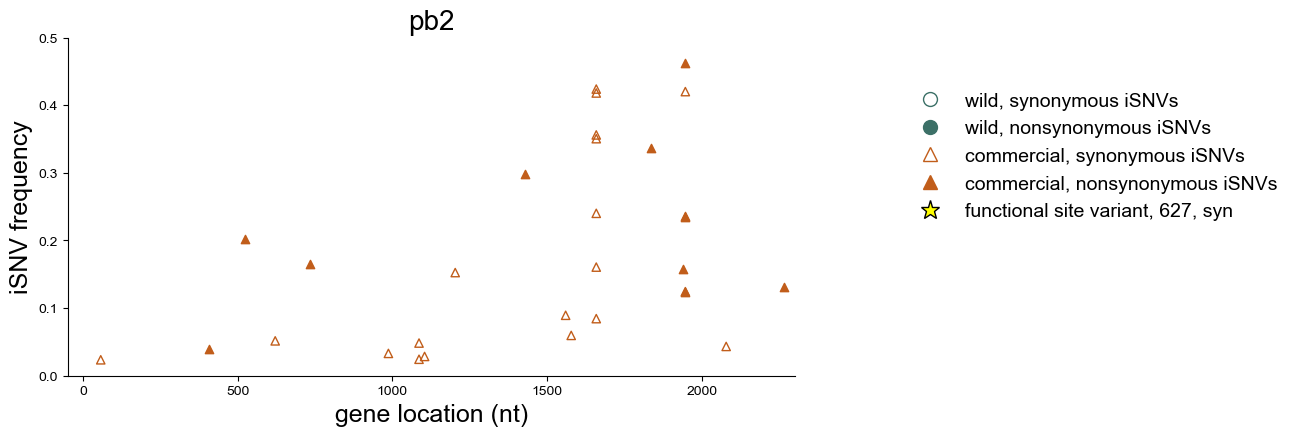

In [231]:
##define subset dfs by gene and category
pb2 = shared_vars[shared_vars["gene"] == "PB2"]
w_syn_pb2 = pb2[pb2["color"] == "wild_synonymous"]
w_nonsyn_pb2 = pb2[pb2["color"] == "wild_nonsynonymous"]
c_syn_pb2 = pb2[pb2["color"] == "commercial_synonymous"]
c_nonsyn_pb2 = pb2[pb2["color"] == "commercial_nonsynonymous"]

import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib as mpl
from matplotlib import gridspec

wild_clr = '#3C7067'
comm_clr = '#C15D1A'


# pb2['color'] = pb2['color'].map(color_map)

# Create figure
fig = plt.figure(figsize=(10, 8), facecolor='w')
plt.style.use('default')
plt.rc('font', family='Arial')
gs = gridspec.GridSpec(2, 10)

ax1 = fig.add_subplot(gs[0, 0:8])  # PB2

# Set plot style
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['bottom'].set_visible(True)
ax1.spines['left'].set_visible(True)
ax1.tick_params(axis='both', which='major', labelsize=10)
ax1.tick_params(axis='both', which='minor', labelsize=10)

# Set axis labels and title
ax1.set_title('pb2', fontname='Arial', fontsize=20)
ax1.set_facecolor('white')
ax1.set_ylabel('iSNV frequency', fontname='Arial', fontsize=18)
ax1.set_xlabel('gene location (nt)', fontname='Arial', fontsize=18)

# Set axis limits and ticks
ax1.set_ylim(0, 0.5)
ax1.set_xlim(-50, 2300)
ax1.set_xticks([0, 500, 1000, 1500, 2000])


ax1.scatter(x=w_syn_pb2['position'], y=w_syn_pb2['avg_freq'], marker='o', facecolors='none', edgecolors=wild_clr)
ax1.scatter(x=w_nonsyn_pb2['position'], y=w_nonsyn_pb2['avg_freq'], marker='o', facecolors=wild_clr, edgecolors=wild_clr)
ax1.scatter(x=c_syn_pb2['position'], y=c_syn_pb2['avg_freq'], marker='^', facecolors='none', edgecolors=comm_clr)
ax1.scatter(x=c_nonsyn_pb2['position'], y=c_nonsyn_pb2['avg_freq'], marker='^', facecolors=comm_clr, edgecolors=comm_clr)


# Define positions to highlight
highlight_positions = [1908]

# Extract corresponding rows
highlight_points = pb2[pb2["position"].isin(highlight_positions)]

# Plot yellow stars
ax1.scatter(
    x=highlight_points['position'],
    y=highlight_points['avg_freq'],
    marker='*',
    color='yellow',
    edgecolor='black',
    s=150,
    zorder=10  # ensure it's on top
)


# add a legend to this plot
w_syn = mlines.Line2D([], [], marker='o', markerfacecolor='None', markeredgecolor=wild_clr, linestyle='None', markersize=10, label='wild, synonymous iSNVs')
w_nonsyn = mlines.Line2D([], [], marker='o', markerfacecolor=wild_clr, markeredgecolor=wild_clr, linestyle='None', markersize=10, label='wild, nonsynonymous iSNVs')
c_syn = mlines.Line2D([], [], marker='^', markerfacecolor='None', markeredgecolor=comm_clr, linestyle='None', markersize=10, label='commercial, synonymous iSNVs')
c_nonsyn = mlines.Line2D([], [], marker='^', markerfacecolor=comm_clr, markeredgecolor=comm_clr, linestyle='None', markersize=10, label='commercial, nonsynonymous iSNVs')

# Add the legend to the figure
highlight_legend = mlines.Line2D([], [], marker='*', color='yellow', markeredgecolor='black',
                                 linestyle='None', markersize=14, label='functional site variant, 627, syn')
fig.legend(handles=[w_syn, w_nonsyn, c_syn, c_nonsyn, highlight_legend], 
           frameon=False, fontsize=14, bbox_to_anchor=(1.3, 0.9))


# Adjust layout and show plot
fig.tight_layout()
fig.show()

# Save plot
# fig.savefig("seq/analysis/figures/PB2_funcsite_highlight.pdf", bbox_inches='tight', dpi=300)


In [232]:
# shared_vars = pd.read_csv('../seq/analysis/output_dfs/2025_06_17_repshared_SNVs_allsamples.tsv', sep='\t')


In [233]:
# shared_vars.loc[shared_vars['segment'] == 'na', 'gene'] = 'NA'

# shared_vars

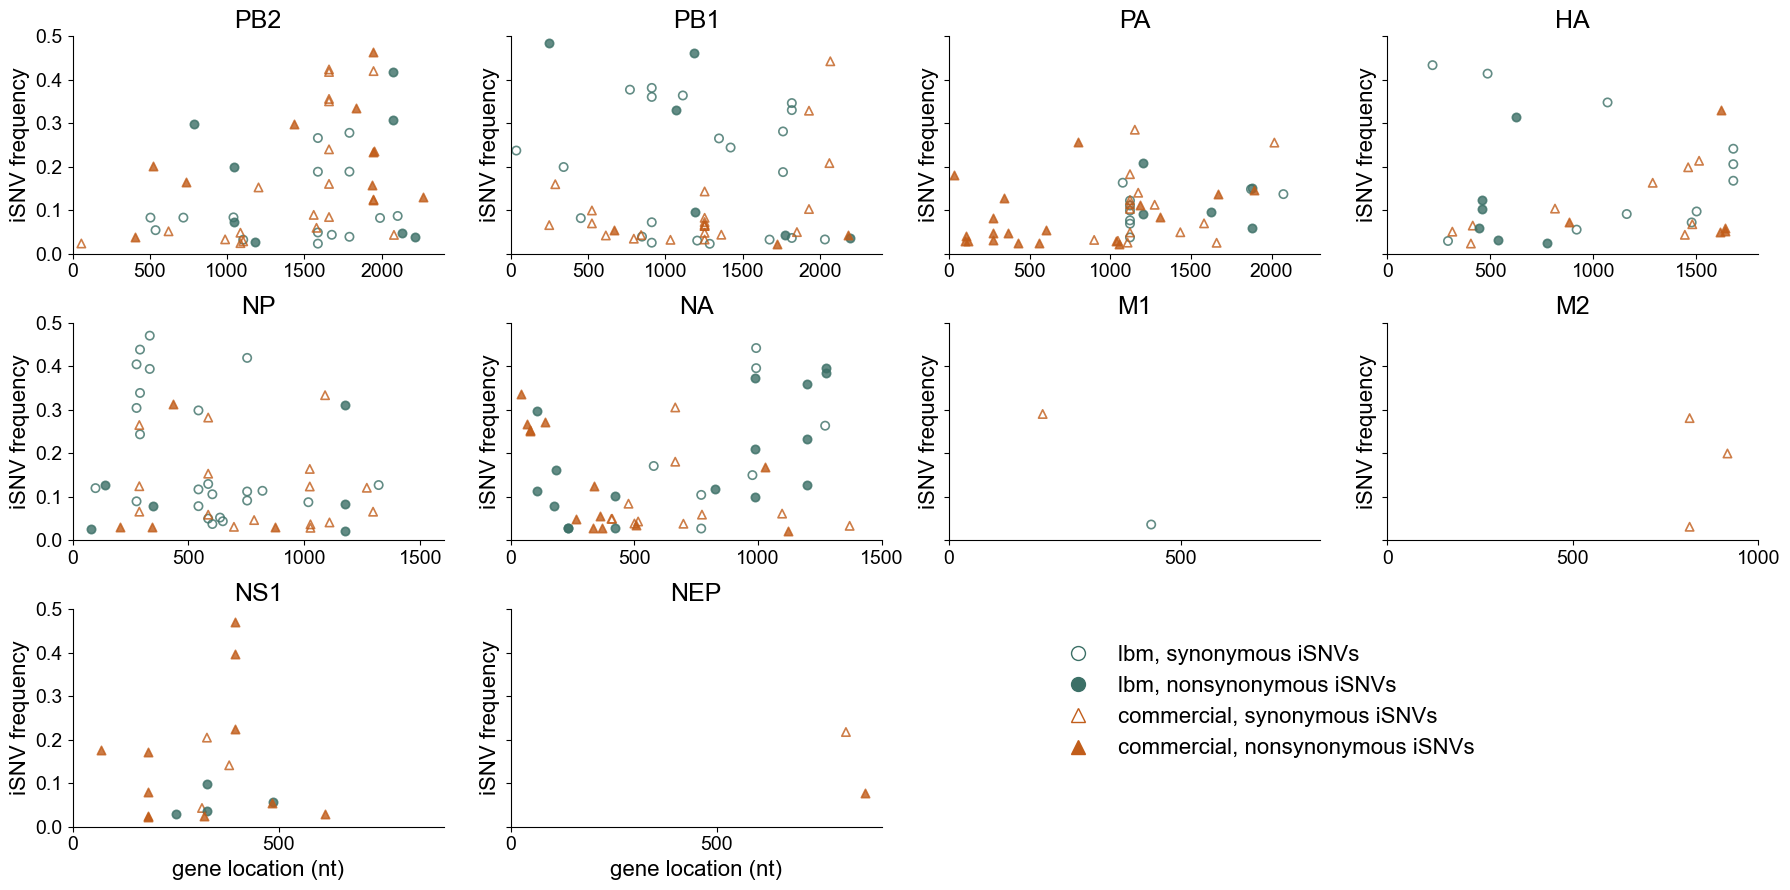

In [71]:
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import numpy as np

# Define colors
lbm_clr = '#3C7067'
comm_clr = '#C15D1A'

# Define your sample_colors dictionary
# This must map each sample_ID to either wild_clr or comm_clr
sample_colors = {
    sample: lbm_clr if "lbm" in sample else comm_clr
    for sample in shared_vars['sample'].unique()
}
########
# Define the order you want for genes
gene_order = ["PB2", "PB1", "PA", "HA", "NP", "NA", "M1", "M2", "NS1", "NEP"]  # replace with your desired order

# Example: map each gene to (xmin, xmax)
gene_xlimits = {
    "PB2": (0, 2400),
    "PB1": (0, 2400),
    "PA": (0, 2300),
    "HA": (0, 1800),
    "NP": (0, 1600),
    "NA": (0, 1500),
    "M1": (0, 800),
    "M2": (0, 1000),
    "NS1": (0, 900),
    "NEP": (0, 900)
}

# Filter out genes that aren't in your data (optional)
unique_genes = [g for g in gene_order if g in shared_vars['gene'].values]
n_genes = len(unique_genes)
#######
# shared_vars['gene'] = shared_vars['gene'].fillna('NA')  # Only if actual NaNs exist
# # Get unique genes
# unique_genes = shared_vars['gene'].dropna().unique()
# n_genes = len(unique_genes)

# Grid size based on number of genes
n_cols = 4
n_rows = int(np.ceil(n_genes / n_cols))

# Create subplots
# fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 2.5), sharex=False, sharey=True)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 3), sharex=False, sharey=True)

axes = axes.flatten()

# Loop through each gene and plot
for i, gene in enumerate(unique_genes):
    ax = axes[i]
    gene_df = shared_vars[shared_vars['gene'] == gene]

    ax.set_title(f'{gene}', fontsize=18)
    ax.set_facecolor('white')
    ax.set_ylim(0, 0.5)
    # ax.set_xlim(-50, 2300)
    ax.set_yticks(np.arange(0, 0.6, 0.1))
    ax.set_xticks([0, 500, 1000, 1500, 2000])
    
    # Set x-axis limits based on gene-specific dictionary
    if gene in gene_xlimits:
        ax.set_xlim(gene_xlimits[gene])
    # else:
    #     # fallback to dynamic limits if not defined
    #     xmin = gene_df['position'].min()
    #     xmax = gene_df['position'].max()
    #     pad = (xmax - xmin) * 0.05
    #     ax.set_xlim(xmin - pad, xmax + pad)
    # Gene-specific x-limits
        
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='both', which='major', labelsize=14)

    # Label only bottom row with x-axis
    if i // n_cols == n_rows - 1:
        ax.set_xlabel('gene location (nt)', fontsize=16)
    ax.set_ylabel('iSNV frequency', fontsize=16)

    for sample_ID, color in sample_colors.items():
        sample_df = gene_df[gene_df['sample_ID'] == sample_ID]
        is_commercial = 'comm' in sample_ID or 'commercial' in sample_ID.lower()  # adjust this logic as needed
        marker_shape = '^' if is_commercial else 'o'  # triangle for commercial, circle for wild
    
    for syn_non in ['synonymous', 'nonsynonymous']:
        for group, clr, marker in [
            ('LBM', lbm_clr, 'o'),
            ('commercial', comm_clr, '^')
        ]:
            subset = gene_df[
                (gene_df['color'].str.contains(group)) &
                (gene_df['syn_non'] == syn_non)
            ]
            if not subset.empty:
                ax.scatter(
                    x=subset['position'],
                    y=subset['avg_freq'],
                    marker=marker,
                    facecolors='none' if syn_non == 'synonymous' else clr,
                    edgecolors=clr,
                    alpha=0.8,
                    linewidth=1.2
                )


# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

# Legend
l_syn = mlines.Line2D([], [], marker='o', markerfacecolor='None', markeredgecolor=lbm_clr, linestyle='None', markersize=10, label='lbm, synonymous iSNVs')
l_nonsyn = mlines.Line2D([], [], marker='o', markerfacecolor=lbm_clr, markeredgecolor=lbm_clr, linestyle='None', markersize=10, label='lbm, nonsynonymous iSNVs')
c_syn = mlines.Line2D([], [], marker='^', markerfacecolor='None', markeredgecolor=comm_clr, linestyle='None', markersize=10, label='commercial, synonymous iSNVs')
c_nonsyn = mlines.Line2D([], [], marker='^', markerfacecolor=comm_clr, markeredgecolor=comm_clr, linestyle='None', markersize=10, label='commercial, nonsynonymous iSNVs')

fig.legend(
    handles=[l_syn, l_nonsyn, c_syn, c_nonsyn],
    frameon=False,
    fontsize=16,
    # loc='upper right',
    bbox_to_anchor=(.75, .3)
)

# Layout adjustment
fig.tight_layout(rect=[0, 0, 0.9, 1])

filename = "../output_plots/"+todays_date+"_allsnvs-bygene-allcom-lbm.pdf"
# plt.savefig(filename, format='pdf', bbox_inches='tight', dpi=300)

plt.show()


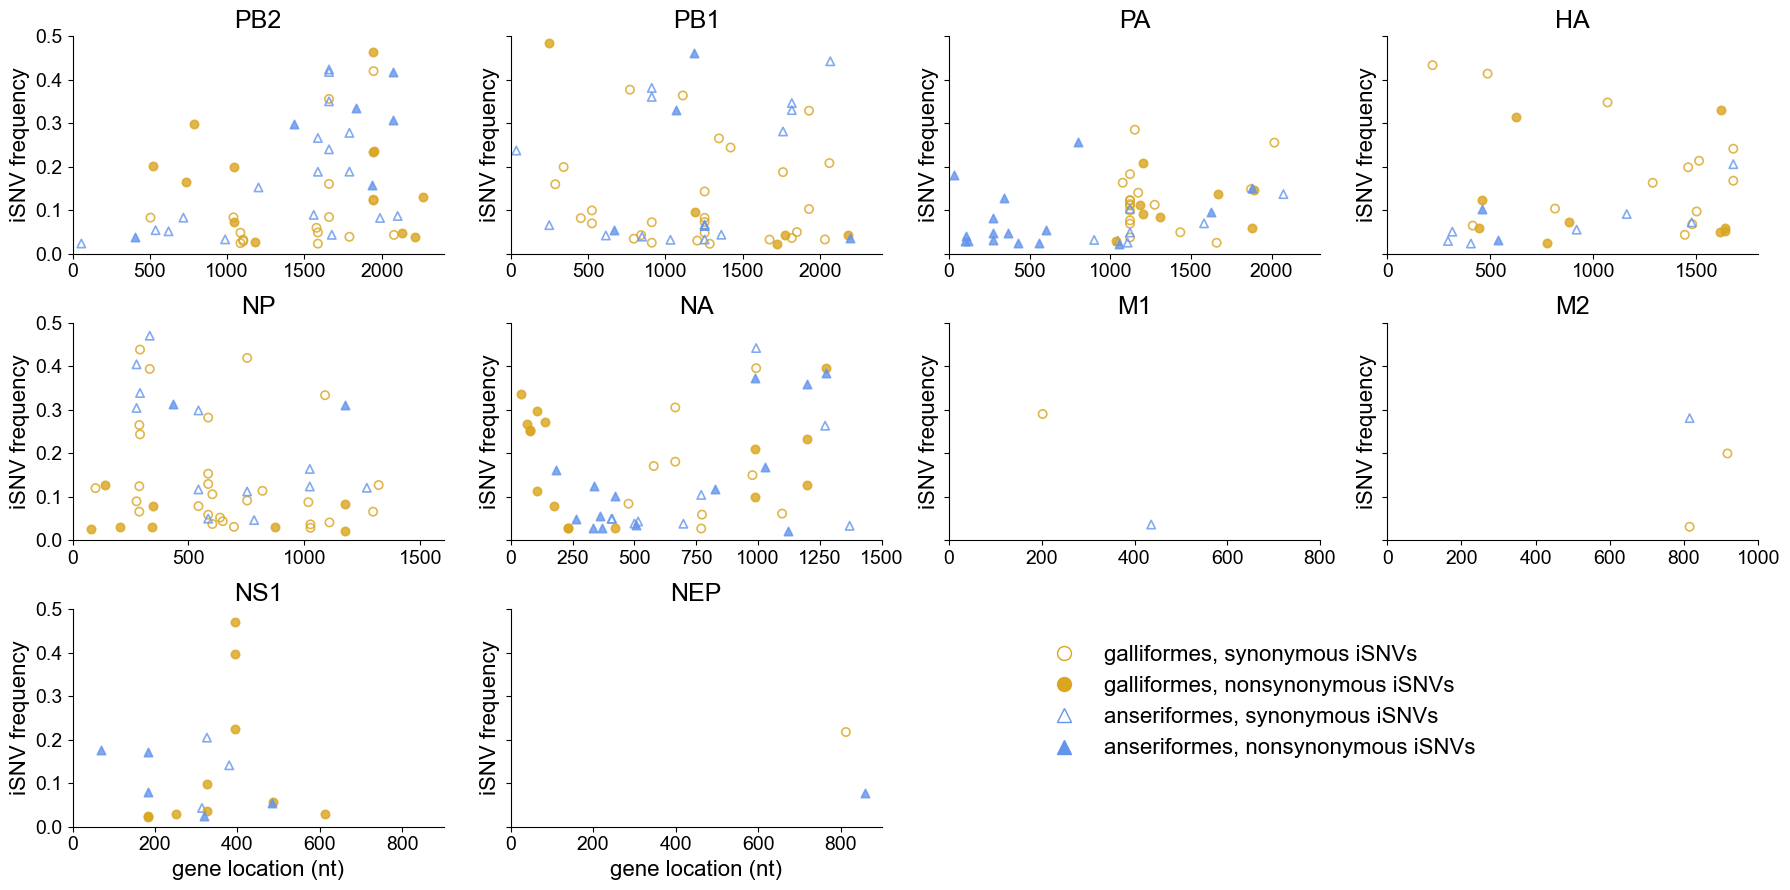

In [72]:
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import numpy as np

# Define colors and markers
order_colors = {
    'galliformes': '#daa520',  # chicken
    'anseriformes': '#6495ED'  # duck
}
order_markers = {
    'galliformes': 'o',
    'anseriformes': '^'
}

# Gene order and x-limits
gene_order = ["PB2", "PB1", "PA", "HA", "NP", "NA", "M1", "M2", "NS1", "NEP"]
gene_xlimits = {
    "PB2": (0, 2400), "PB1": (0, 2400), "PA": (0, 2300), "HA": (0, 1800),
    "NP": (0, 1600), "NA": (0, 1500), "M1": (0, 800), "M2": (0, 1000),
    "NS1": (0, 900), "NEP": (0, 900)
}

# Filter genes present in data
unique_genes = [g for g in gene_order if g in shared_vars['gene'].values]
n_genes = len(unique_genes)

# Grid size
n_cols = 4
n_rows = int(np.ceil(n_genes / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 3), sharex=False, sharey=True)
axes = axes.flatten()

# Loop through genes
for i, gene in enumerate(unique_genes):
    ax = axes[i]
    gene_df = shared_vars[shared_vars['gene'] == gene]

    ax.set_title(gene, fontsize=18)
    ax.set_facecolor('white')
    ax.set_ylim(0, 0.5)
    ax.set_yticks(np.arange(0, 0.6, 0.1))

    # Gene-specific x-limits
    if gene in gene_xlimits:
        ax.set_xlim(gene_xlimits[gene])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='both', which='major', labelsize=14)

    # X-axis only on bottom row
    if i // n_cols == n_rows - 1:
        ax.set_xlabel('gene location (nt)', fontsize=16)
    ax.set_ylabel('iSNV frequency', fontsize=16)

    # Plot points
    for syn_non in ['synonymous', 'nonsynonymous']:
        for order in ['galliformes', 'anseriformes']:
            subset = gene_df[(gene_df['order'] == order) & (gene_df['syn_non'] == syn_non)]
            if not subset.empty:
                ax.scatter(
                    x=subset['position'],
                    y=subset['avg_freq'],
                    marker=order_markers[order],
                    facecolors='none' if syn_non == 'synonymous' else order_colors[order],
                    edgecolors=order_colors[order],
                    alpha=0.8,
                    linewidth=1.2
                )

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

# Legend
l_syn = mlines.Line2D([], [], marker='o', markerfacecolor='None', markeredgecolor=order_colors['galliformes'],
                      linestyle='None', markersize=10, label='galliformes, synonymous iSNVs')
l_nonsyn = mlines.Line2D([], [], marker='o', markerfacecolor=order_colors['galliformes'], markeredgecolor=order_colors['galliformes'],
                         linestyle='None', markersize=10, label='galliformes, nonsynonymous iSNVs')
c_syn = mlines.Line2D([], [], marker='^', markerfacecolor='None', markeredgecolor=order_colors['anseriformes'],
                      linestyle='None', markersize=10, label='anseriformes, synonymous iSNVs')
c_nonsyn = mlines.Line2D([], [], marker='^', markerfacecolor=order_colors['anseriformes'], markeredgecolor=order_colors['anseriformes'],
                         linestyle='None', markersize=10, label='anseriformes, nonsynonymous iSNVs')

fig.legend(handles=[l_syn, l_nonsyn, c_syn, c_nonsyn],
           frameon=False,
           fontsize=16,
           bbox_to_anchor=(0.75, 0.3))

fig.tight_layout(rect=[0, 0, 0.9, 1])


filename = "../output_plots/"+todays_date+"-allsnvs-comm-anser-gal.pdf"
# plt.savefig(filename, format='pdf', bbox_inches='tight', dpi=300)
plt.show()


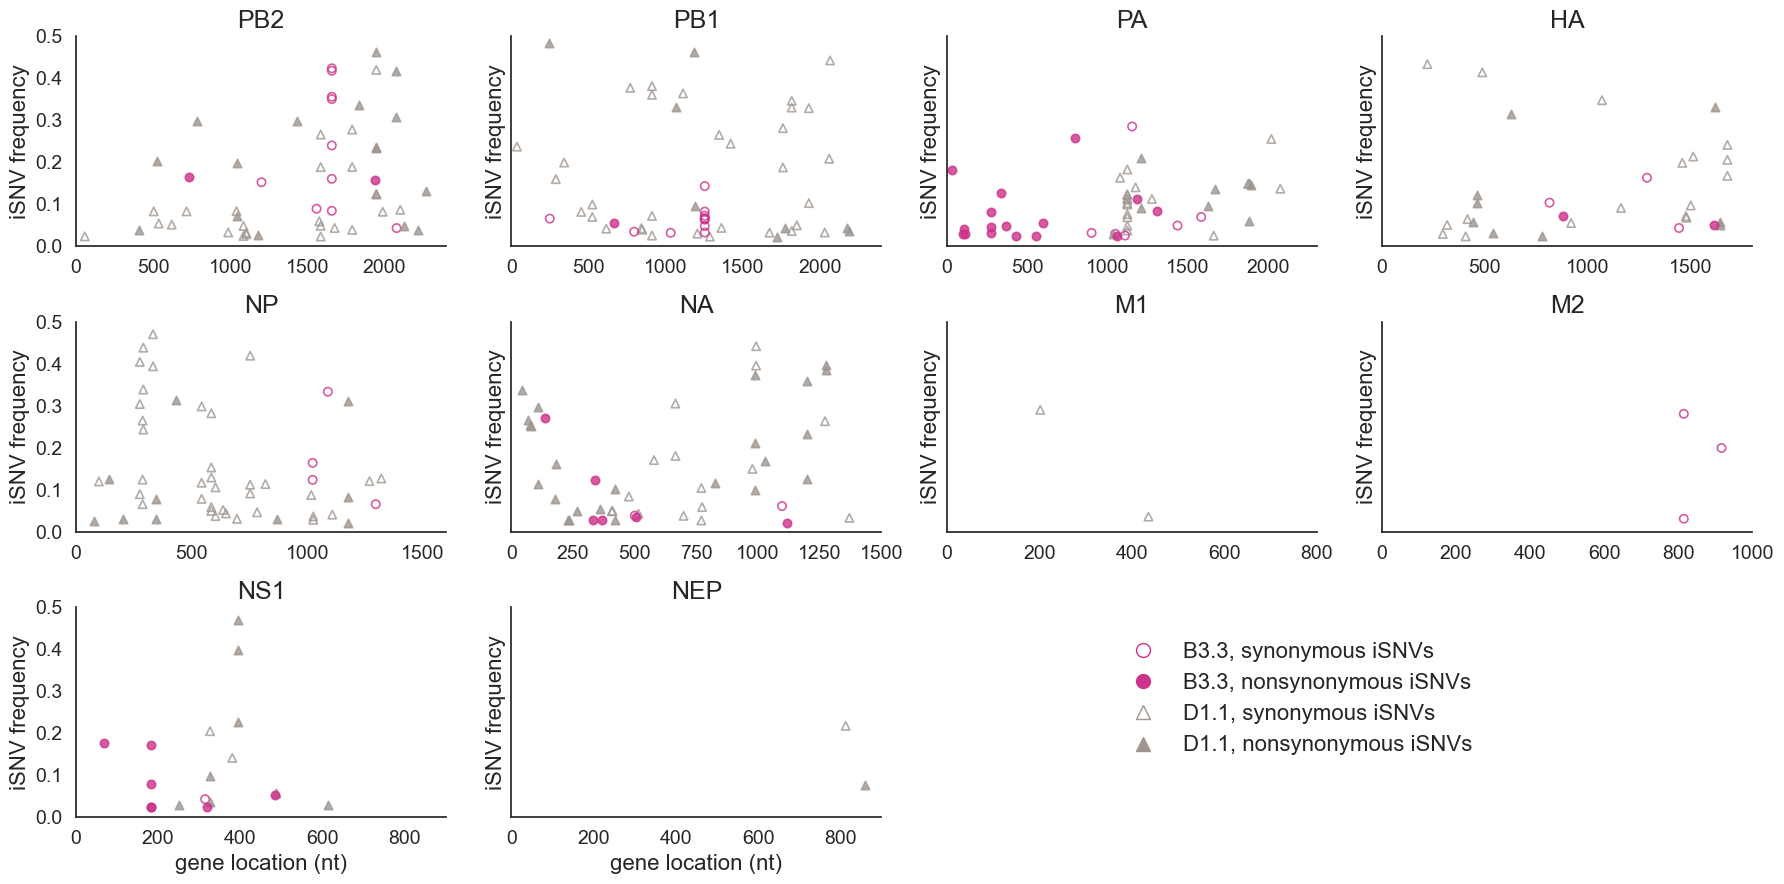

In [104]:
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import numpy as np

# Define colors and markers
gtype_colors = {
    # 'B3.3': '#5B1166',  # prev (purple)
    'B3.3': '#CC338B',  # prev (purple)
    'D1.1': '#9f9690'  # d11 (blue)
}
gtype_markers = {
    'B3.3': 'o',
    'D1.1': '^'
}

# Gene order and x-limits
gene_order = ["PB2", "PB1", "PA", "HA", "NP", "NA", "M1", "M2", "NS1", "NEP"]
gene_xlimits = {
    "PB2": (0, 2400), "PB1": (0, 2400), "PA": (0, 2300), "HA": (0, 1800),
    "NP": (0, 1600), "NA": (0, 1500), "M1": (0, 800), "M2": (0, 1000),
    "NS1": (0, 900), "NEP": (0, 900)
}

# Filter genes present in data
unique_genes = [g for g in gene_order if g in shared_vars['gene'].values]
n_genes = len(unique_genes)

# Grid size
n_cols = 4
n_rows = int(np.ceil(n_genes / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 3), sharex=False, sharey=True)
axes = axes.flatten()

# Loop through genes
for i, gene in enumerate(unique_genes):
    ax = axes[i]
    gene_df = shared_vars[shared_vars['gene'] == gene]

    ax.set_title(gene, fontsize=18)
    ax.set_facecolor('white')
    ax.set_ylim(0, 0.5)
    ax.set_yticks(np.arange(0, 0.6, 0.1))

    # Gene-specific x-limits
    if gene in gene_xlimits:
        ax.set_xlim(gene_xlimits[gene])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='both', which='major', labelsize=14)

    # X-axis only on bottom row
    if i // n_cols == n_rows - 1:
        ax.set_xlabel('gene location (nt)', fontsize=16)
    ax.set_ylabel('iSNV frequency', fontsize=16)

    # Plot points
    for syn_non in ['synonymous', 'nonsynonymous']:
        for gtype in ['D1.1', 'B3.3']:
            subset = gene_df[(gene_df['genotype'] == gtype) & (gene_df['syn_non'] == syn_non)]
            if not subset.empty:
                ax.scatter(
                    x=subset['position'],
                    y=subset['avg_freq'],
                    marker=gtype_markers[gtype],
                    facecolors='none' if syn_non == 'synonymous' else gtype_colors[gtype],
                    edgecolors=gtype_colors[gtype],
                    alpha=0.8,
                    linewidth=1.2
                )

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

# Legend
l_syn = mlines.Line2D([], [], marker='o', markerfacecolor='None', markeredgecolor=gtype_colors['B3.3'],
                      linestyle='None', markersize=10, label='B3.3, synonymous iSNVs')
l_nonsyn = mlines.Line2D([], [], marker='o', markerfacecolor=gtype_colors['B3.3'], markeredgecolor=gtype_colors['B3.3'],
                         linestyle='None', markersize=10, label='B3.3, nonsynonymous iSNVs')
c_syn = mlines.Line2D([], [], marker='^', markerfacecolor='None', markeredgecolor=gtype_colors['D1.1'],
                      linestyle='None', markersize=10, label='D1.1, synonymous iSNVs')
c_nonsyn = mlines.Line2D([], [], marker='^', markerfacecolor=gtype_colors['D1.1'], markeredgecolor=gtype_colors['D1.1'],
                         linestyle='None', markersize=10, label='D1.1, nonsynonymous iSNVs')

fig.legend(handles=[l_syn, l_nonsyn, c_syn, c_nonsyn],
           frameon=False,
           fontsize=16,
           bbox_to_anchor=(0.75, 0.3))

fig.tight_layout(rect=[0, 0, 0.9, 1])

filename = "../output_plots/"+todays_date+"-allsnvs-comm-genotype.pdf"
plt.savefig(filename, format='pdf', bbox_inches='tight', dpi=300)
plt.show()


In [52]:
shared_vars.groupby('genotype').nunique()##n=17 LBM, n=6 commercial
# shared_vars.groupby('order').nunique()##n=17 LBM, n=6 commercial

#17 anserifrormes, 19 galliformes
#17 LBM, 19 commercial


,segment,position,allele,coding_region_change,gene,Frequency_1,Frequency_2,sample,amino_acid,gene_pos,...,ct_value,rep_shared,order,county,date,species,species_group,color,avg_freq,order_domstat
genotype,,,,,,,,,,,,,,,,,,,,,
B3.3,8,52,4,54,8,71,72,12,54,54,...,12,1,2,2,2,3,2,2,74,2
D1.1,8,159,4,174,9,219,216,24,146,162,...,23,1,2,3,5,0,2,4,229,4


In [53]:
sample_counts = pd.merge(sample_counts, shared_vars[['order', 'date', 'domestic_status', 'sample_ID', 'genotype']], on='sample_ID', how='left')
sample_counts.drop_duplicates(subset=['sample_ID'], inplace=True)
sample_counts

,sample_ID,count,order,date,domestic_status,genotype
0,ckr_com1,21,galliformes,2025-07-01,commercial,D1.1
21,ckr_com3,18,galliformes,2025-07-01,commercial,D1.1
39,c_lbm5,16,galliformes,2025-03-10,LBM,D1.1
55,ckr_com2,15,galliformes,2025-07-01,commercial,D1.1
70,kc_com6,13,anseriformes,2023-02-23,commercial,B3.3
83,kc_com3,13,anseriformes,2023-02-23,commercial,B3.3
96,gn_lbm1,13,galliformes,2025-02-20,LBM,D1.1
109,d_lbm2,13,anseriformes,2025-02-20,LBM,D1.1
122,d_lbm3,12,anseriformes,2025-03-10,LBM,D1.1
134,d_com2,12,anseriformes,2025-07-01,commercial,D1.1


/var/folders/8h/zkgpnzwj7f9d82wldp_d4h_w0000gs/T/ipykernel_96433/3781450260.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


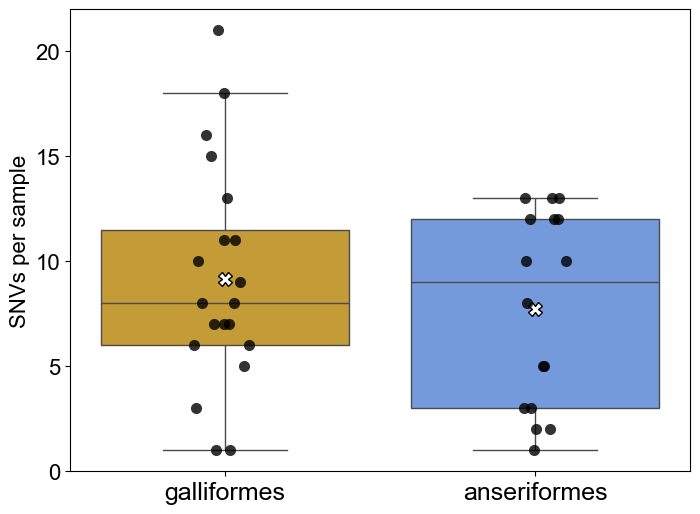

In [54]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=sample_counts,
    x='order',
    y='count',
    palette=['#daa520', '#6495ED'],
    showmeans=True,          # draws mean marker
    showfliers=False,
    meanprops={"marker":"X",
               "markerfacecolor":"white",
               "markeredgecolor":"black",
               "markersize":10}
)

sns.stripplot(
    data=sample_counts,
    x='order',
    y='count',
    color='black',       # color of points
    size=8,              # marker size
    jitter=True,         # spread points horizontally
    alpha=0.8
)

# Labels and title
plt.yticks(fontsize=16)
plt.xticks(fontsize=18)

plt.ylabel('SNVs per sample', fontsize=16)
plt.xlabel('')

# plt.title('Mean counts by host order', fontsize=16)

# plt.savefig('../../seq/analysis/figures/2026-02-20-snvs-by-order-comms.pdf', format='pdf')
plt.show()


/var/folders/8h/zkgpnzwj7f9d82wldp_d4h_w0000gs/T/ipykernel_96433/772750903.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


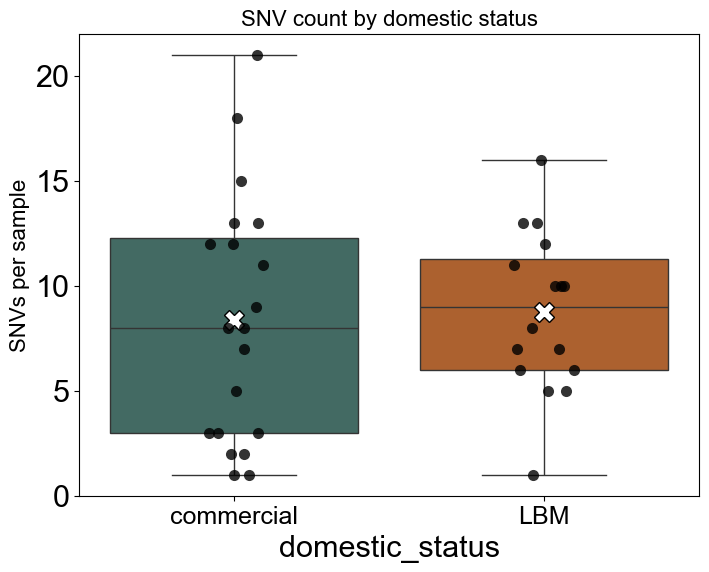

In [55]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=sample_counts,
    x='domestic_status',
    y='count',
    palette=['#3C7067', '#C15D1A'],
    showmeans=True,          # draws mean marker
    showfliers=False,
    meanprops={"marker":"X",
               "markerfacecolor":"white",
               "markeredgecolor":"black",
               "markersize":15}
)

sns.stripplot(
    data=sample_counts,
    x='domestic_status',
    y='count',
    color='black',       # color of points
    size=8,              # marker size
    jitter=True,         # spread points horizontally
    alpha=0.8
)

# Labels and title
# plt.xlabel('Order', fontsize=16)
plt.ylabel('SNVs per sample', fontsize=16)
plt.title('SNV count by domestic status', fontsize=16)
plt.xticks(fontsize=18)

# plt.savefig('../../seq/analysis/figures/2026-02-20-snvs-by-domstat-comms.pdf', format='pdf')

plt.show()


/var/folders/8h/zkgpnzwj7f9d82wldp_d4h_w0000gs/T/ipykernel_96433/302148237.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


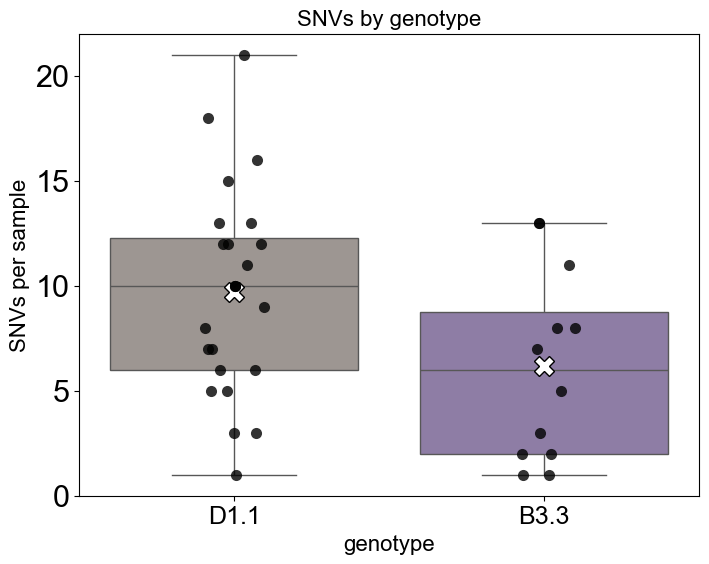

In [56]:
sample_counts['date'] = pd.to_datetime(sample_counts['date'])

sample_counts['genotype'] = sample_counts['date'].dt.year.apply(lambda y: 'D1.1' if y == 2025 else 'B3.3')

plt.figure(figsize=(8,6))

sns.boxplot(
    data=sample_counts,
    x='genotype',
    y='count',
    palette=['#9f9690', '#8d77ab'],
    showmeans=True,          # draws mean marker
    showfliers=False,
    meanprops={"marker":"X",
               "markerfacecolor":"white",
               "markeredgecolor":"black",
               "markersize":15}
)

sns.stripplot(
    data=sample_counts,
    x='genotype',
    y='count',
    color='black',       # color of points
    size=8,              # marker size
    jitter=True,         # spread points horizontally
    alpha=0.8
)

# Labels and title
plt.xlabel('genotype', fontsize=16)
plt.ylabel('SNVs per sample', fontsize=16)
plt.title('SNVs by genotype', fontsize=16)
plt.xticks(fontsize=18)

# plt.savefig('../../seq/analysis/figures/2026-02-20-snvs-by-genotype-comms.pdf', format='pdf')

plt.show()

In [57]:
sample_counts = pd.merge(sample_counts, shared_vars[['ct_value', 'sample_ID']], on='sample_ID', how='left')
sample_counts.drop_duplicates(subset=['sample_ID'], inplace=True)
sample_counts

,sample_ID,count,order,date,domestic_status,genotype,ct_value
0,ckr_com1,21,galliformes,2025-07-01,commercial,D1.1,21.40
21,ckr_com3,18,galliformes,2025-07-01,commercial,D1.1,21.11
39,c_lbm5,16,galliformes,2025-03-10,LBM,D1.1,20.58
55,ckr_com2,15,galliformes,2025-07-01,commercial,D1.1,21.36
70,kc_com6,13,anseriformes,2023-02-23,commercial,B3.3,21.93
83,kc_com3,13,anseriformes,2023-02-23,commercial,B3.3,20.74
96,gn_lbm1,13,galliformes,2025-02-20,LBM,D1.1,20.41
109,d_lbm2,13,anseriformes,2025-02-20,LBM,D1.1,27.40
122,d_lbm3,12,anseriformes,2025-03-10,LBM,D1.1,26.43
134,d_com2,12,anseriformes,2025-07-01,commercial,D1.1,22.99


In [58]:
sample_counts['sample_ID'].nunique()

36

/var/folders/8h/zkgpnzwj7f9d82wldp_d4h_w0000gs/T/ipykernel_96433/4213473917.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


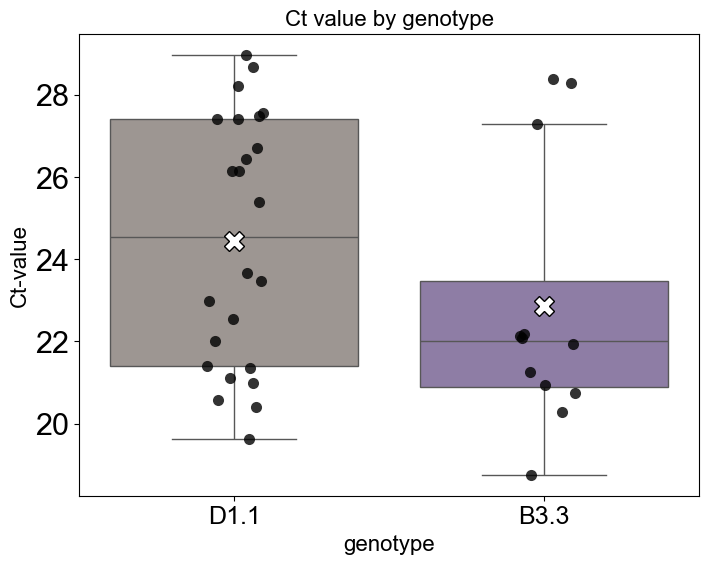

In [59]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=sample_counts,
    x='genotype',
    y='ct_value',
    palette=['#9f9690', '#8d77ab'],
    showmeans=True,          # draws mean marker
    showfliers=False,
    meanprops={"marker":"X",
               "markerfacecolor":"white",
               "markeredgecolor":"black",
               "markersize":15}
)

sns.stripplot(
    data=sample_counts,
    x='genotype',
    y='ct_value',
    color='black',       # color of points
    size=8,              # marker size
    jitter=True,         # spread points horizontally
    alpha=0.8
)

# Labels and title
plt.xlabel('genotype', fontsize=16)
plt.ylabel('Ct-value', fontsize=16)
plt.title('Ct value by genotype', fontsize=16)
plt.xticks(fontsize=18)


# plt.savefig('../../seq/analysis/figures/2026-02-05-ct-by-genotype-comms.pdf', format='pdf')

plt.show()


D1.1
  Slope: -0.6805
  Intercept: 26.3414
  R²: 0.1774
  p-value: 4.0398e-02

B3.3
  Slope: -0.8881
  Intercept: 26.4644
  R²: 0.4096
  p-value: 2.4989e-02



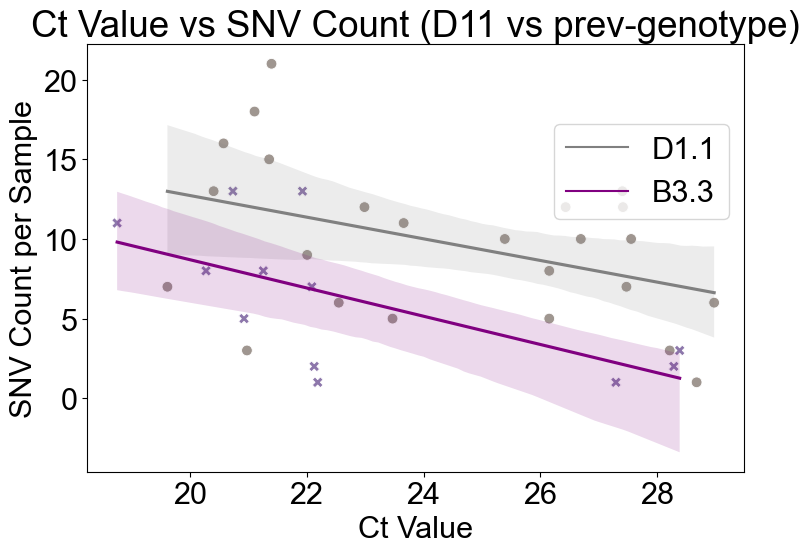

In [61]:
# sns.scatterplot(data=sample_counts, x='ct_value', y='count', hue='genotype', palette=['#9f9690', '#8d77ab'], s=45)


palette=['#9f9690', '#8d77ab']

# Group by sample_ID and rep_shared to count SNVs
rep_counts = shared_vars.groupby(['sample_ID', 'genotype']).size().reset_index(name='count')

# Merge in Ct values (assuming unique per sample_ID)
sample_metadata = shared_vars[['sample_ID', 'ct_value']].drop_duplicates()
rep_counts = rep_counts.merge(sample_metadata, on='sample_ID')


plt.figure(figsize=(8, 6))

# Scatterplot and regression per group
sns.scatterplot(data=rep_counts, x='ct_value', y='count', hue='genotype', style='genotype', s=60, palette=palette)
sns.regplot(data=rep_counts[rep_counts['genotype'] == 'D1.1'], 
            x='ct_value', y='count', scatter=False, label='D1.1, linear reg', color='gray')
sns.regplot(data=rep_counts[rep_counts['genotype'] == 'B3.3'], 
            x='ct_value', y='count', scatter=False, label='B3.3, linear reg', color='purple')

# Labels and formatting
plt.xlabel('Ct Value')
plt.ylabel('SNV Count per Sample')
plt.title('Ct Value vs SNV Count (D11 vs prev-genotype)')
# plt.ylim(1,325)
# plt.yscale('log')

legend_elements = [Line2D([0], [0], color='gray', label='D1.1'),
                   Line2D([0], [0], color='purple', label='B3.3')]
plt.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1, .85))

plt.tight_layout()


from scipy.stats import linregress

for group in rep_counts['genotype'].unique():
    subset = rep_counts[rep_counts['genotype'] == group]
    
    slope, intercept, r_value, p_value, std_err = linregress(
        subset['ct_value'],
        subset['count']
    )
    
    print(f"{group}")
    print(f"  Slope: {slope:.4f}")
    print(f"  Intercept: {intercept:.4f}")
    print(f"  R²: {r_value**2:.4f}")
    print(f"  p-value: {p_value:.4e}")
    print()

# plt.savefig("seq/analysis/figures/ctval_snvcount_regress.pdf", bbox_inches='tight', dpi=300)
plt.show()


In [62]:
rep_counts

,sample_ID,genotype,count,ct_value
0,c_com5,D1.1,9,22.01
1,c_com6,D1.1,3,20.98
2,c_lbm1,D1.1,5,23.47
3,c_lbm10,D1.1,7,19.62
4,c_lbm11,D1.1,6,28.97
5,c_lbm2,D1.1,8,26.15
6,c_lbm3,D1.1,1,28.67
7,c_lbm5,D1.1,16,20.58
8,c_lbm6,D1.1,7,27.47
9,c_lbm7,D1.1,11,23.66


In [100]:
sample_counts

,sample_ID,count,order,date,domestic_status,ct_value
0,ckr_com1,21,galliformes,2025-07-01,commercial,21.40
21,ckr_com3,18,galliformes,2025-07-01,commercial,21.11
39,c_lbm5,16,galliformes,2025-03-10,LBM,20.58
55,ckr_com2,15,galliformes,2025-07-01,commercial,21.36
70,kc_com6,13,anseriformes,2023-02-23,commercial,21.93
83,kc_com3,13,anseriformes,2023-02-23,commercial,20.74
96,gn_lbm1,13,galliformes,2025-02-20,LBM,20.41
109,d_lbm2,13,anseriformes,2025-02-20,LBM,27.40
122,d_lbm3,12,anseriformes,2025-03-10,LBM,26.43
134,d_com2,12,anseriformes,2025-07-01,commercial,22.99


In [ ]:
###need to update this if i'm changing my calling depth!!

In [63]:
# depth = pd.read_csv('../../seq/analysis/output_dfs/snps-per-1kb-allcomm.tsv', sep = '\t')
depth = pd.read_csv('../output_dfs/2026-05-05-snps-per-1kb-allcomm.tsv', sep = '\t')

depth

,Unnamed: 0,sample_id,total_nts,total_snps,snps_per_1kb
0,0,d_lbm2,10213,13.0,1.272887
1,1,d_lbm3,11623,12.0,1.032436
2,2,d_lbm4,13576,10.0,0.736594
3,3,kc_com3,13535,13.0,0.960473
4,4,kc_com4,13513,5.0,0.370014
5,5,d_com3,9116,3.0,0.329092
6,6,kc_com5,13544,8.0,0.590667
7,7,kc_com2,12715,0.0,0.000000
8,8,d_com2,12491,12.0,0.960692
9,9,cb_com1,13582,11.0,0.809895


In [64]:
snvs_depth = sample_counts.merge(depth[['sample_id', 'snps_per_1kb']], left_on='sample_ID', right_on='sample_id', how='left')
snvs_depth

,sample_ID,count,order,date,domestic_status,genotype,ct_value,sample_id,snps_per_1kb
0,ckr_com1,21,galliformes,2025-07-01,commercial,D1.1,21.40,ckr_com1,1.486768
1,ckr_com3,18,galliformes,2025-07-01,commercial,D1.1,21.11,ckr_com3,1.269889
2,c_lbm5,16,galliformes,2025-03-10,LBM,D1.1,20.58,c_lbm5,1.179245
3,ckr_com2,15,galliformes,2025-07-01,commercial,D1.1,21.36,ckr_com2,1.035503
4,kc_com6,13,anseriformes,2023-02-23,commercial,B3.3,21.93,kc_com6,1.115114
5,kc_com3,13,anseriformes,2023-02-23,commercial,B3.3,20.74,kc_com3,0.960473
6,gn_lbm1,13,galliformes,2025-02-20,LBM,D1.1,20.41,gn_lbm1,0.959905
7,d_lbm2,13,anseriformes,2025-02-20,LBM,D1.1,27.40,d_lbm2,1.272887
8,d_lbm3,12,anseriformes,2025-03-10,LBM,D1.1,26.43,d_lbm3,1.032436
9,d_com2,12,anseriformes,2025-07-01,commercial,D1.1,22.99,d_com2,0.960692


/var/folders/8h/zkgpnzwj7f9d82wldp_d4h_w0000gs/T/ipykernel_96433/3446926661.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


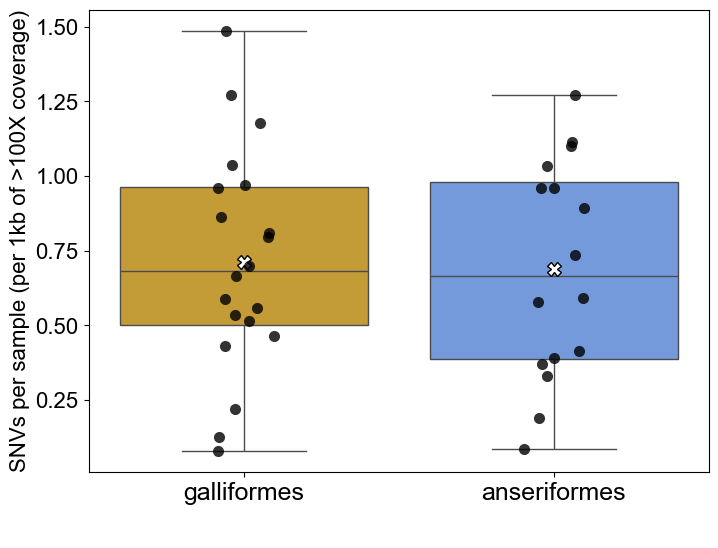

In [65]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=snvs_depth,
    x='order',
    y='snps_per_1kb',
    palette=['#daa520', '#6495ED'],
    showmeans=True,          # draws mean marker
    meanprops={"marker":"X",
               "markerfacecolor":"white",
               "markeredgecolor":"black",
               "markersize":10}
)

sns.stripplot(
    data=snvs_depth,
    x='order',
    y='snps_per_1kb',
    color='black',       # color of points
    size=8,              # marker size
    jitter=True,         # spread points horizontally
    alpha=0.8
)

# Labels and title
plt.xticks(fontsize=18)
plt.yticks(fontsize=16)

plt.ylabel('SNVs per sample (per 1kb of >100X coverage)', fontsize=16)
plt.xlabel(' ')
# plt.title('Mean counts by host order', fontsize=16)

filename = "../output_plots/snvs_per_samp_order_depth_2pct_"+todays_date+".pdf"
plt.savefig(filename, format='pdf', bbox_inches='tight', dpi=300)
plt.show()


/var/folders/8h/zkgpnzwj7f9d82wldp_d4h_w0000gs/T/ipykernel_96433/3187409218.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


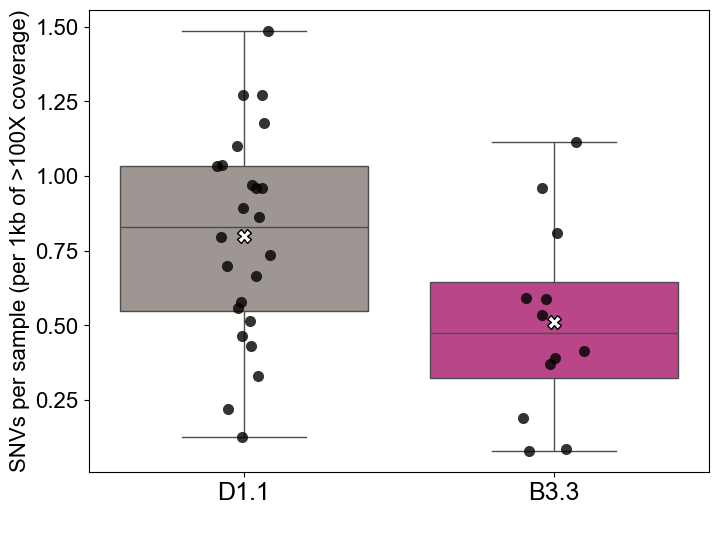

In [66]:
plt.figure(figsize=(8,6))
palette=['#9f9690', '#CC338B'] #gtype palette

sns.boxplot(
    data=snvs_depth,
    x='genotype',
    y='snps_per_1kb',
    palette=palette,
    showmeans=True,          # draws mean marker
    meanprops={"marker":"X",
               "markerfacecolor":"white",
               "markeredgecolor":"black",
               "markersize":10}
)

sns.stripplot(
    data=snvs_depth,
    x='genotype',
    y='snps_per_1kb',
    color='black',       # color of points
    size=8,              # marker size
    jitter=True,         # spread points horizontally
    alpha=0.8
)

# Labels and title
# Labels and title
plt.xticks(fontsize=18)
plt.yticks(fontsize=16)

plt.ylabel('SNVs per sample (per 1kb of >100X coverage)', fontsize=16)
plt.xlabel(' ')

# plt.title('Mean counts by genotype', fontsize=16)

filename = "../output_plots/snvs_per_samp_genotype_depth_2pct_"+todays_date+".pdf"
plt.savefig(filename, format='pdf', bbox_inches='tight', dpi=300)
plt.show()


/var/folders/8h/zkgpnzwj7f9d82wldp_d4h_w0000gs/T/ipykernel_96433/1687951745.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


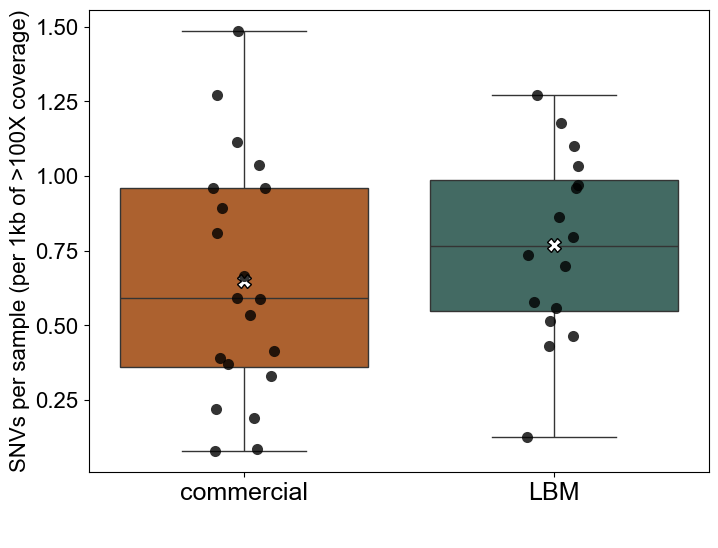

In [67]:
plt.figure(figsize=(8,6))
palette=['#C15D1A', '#3C7067'] #comm/lbm palette

sns.boxplot(
    data=snvs_depth,
    x='domestic_status',
    y='snps_per_1kb',
    palette=palette,
    showmeans=True,          # draws mean marker
    meanprops={"marker":"X",
               "markerfacecolor":"white",
               "markeredgecolor":"black",
               "markersize":10}
)

sns.stripplot(
    data=snvs_depth,
    x='domestic_status',
    y='snps_per_1kb',
    color='black',       # color of points
    size=8,              # marker size
    jitter=True,         # spread points horizontally
    alpha=0.8
)

# Labels and title
# Labels and title
plt.xticks(fontsize=18)
plt.yticks(fontsize=16)

plt.ylabel('SNVs per sample (per 1kb of >100X coverage)', fontsize=16)
plt.xlabel(' ')

filename = "../output_plots/snvs_per_samp_domstat_depth_2pct_"+todays_date+".pdf"
plt.savefig(filename, format='pdf', bbox_inches='tight', dpi=300)
plt.show()


In [68]:
snvs_depth

,sample_ID,count,order,date,domestic_status,genotype,ct_value,sample_id,snps_per_1kb
0,ckr_com1,21,galliformes,2025-07-01,commercial,D1.1,21.40,ckr_com1,1.486768
1,ckr_com3,18,galliformes,2025-07-01,commercial,D1.1,21.11,ckr_com3,1.269889
2,c_lbm5,16,galliformes,2025-03-10,LBM,D1.1,20.58,c_lbm5,1.179245
3,ckr_com2,15,galliformes,2025-07-01,commercial,D1.1,21.36,ckr_com2,1.035503
4,kc_com6,13,anseriformes,2023-02-23,commercial,B3.3,21.93,kc_com6,1.115114
5,kc_com3,13,anseriformes,2023-02-23,commercial,B3.3,20.74,kc_com3,0.960473
6,gn_lbm1,13,galliformes,2025-02-20,LBM,D1.1,20.41,gn_lbm1,0.959905
7,d_lbm2,13,anseriformes,2025-02-20,LBM,D1.1,27.40,d_lbm2,1.272887
8,d_lbm3,12,anseriformes,2025-03-10,LBM,D1.1,26.43,d_lbm3,1.032436
9,d_com2,12,anseriformes,2025-07-01,commercial,D1.1,22.99,d_com2,0.960692


D1.1
  Slope: -0.6805
  Intercept: 26.3414
  R²: 0.1774
  p-value: 4.0398e-02

B3.3
  Slope: -0.8881
  Intercept: 26.4644
  R²: 0.4096
  p-value: 2.4989e-02

 overall R²: 0.1343
 overall slope: -0.5818
 pvalue overall: 0.0279


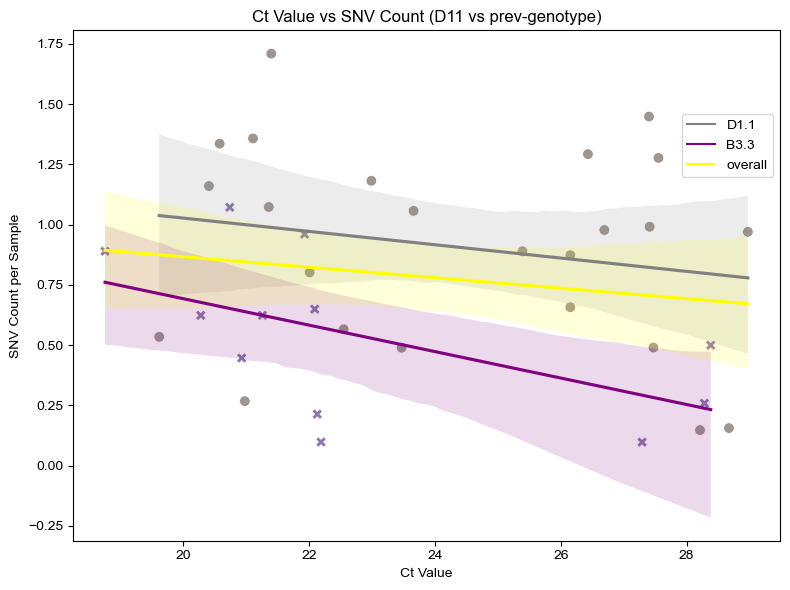

In [288]:
# sns.scatterplot(data=sample_counts, x='ct_value', y='count', hue='genotype', palette=['#9f9690', '#8d77ab'], s=45)


palette=['#9f9690', '#8d77ab']

# # Group by sample_ID and rep_shared to count SNVs
# rep_counts = shared_vars.groupby(['sample_ID', 'genotype']).size().reset_index(name='count')

# # Merge in Ct values (assuming unique per sample_ID)
# sample_metadata = shared_vars[['sample_ID', 'ct_value']].drop_duplicates()
# rep_counts = rep_counts.merge(sample_metadata, on='sample_ID')


plt.figure(figsize=(8, 6))

# Scatterplot and regression per group
sns.scatterplot(data=snvs_depth, x='ct_value', y='snps_per_1kb', hue='genotype', style='genotype', s=60, palette=palette)
sns.regplot(data=snvs_depth[snvs_depth['genotype'] == 'D1.1'], 
            x='ct_value', y='snps_per_1kb', scatter=False, label='D1.1, linear reg', color='gray')
sns.regplot(data=snvs_depth[snvs_depth['genotype'] == 'B3.3'], 
            x='ct_value', y='snps_per_1kb', scatter=False, label='B3.3, linear reg', color='purple')
##overall
sns.regplot(data=snvs_depth,  x='ct_value', y='snps_per_1kb', scatter=False, label='all samps, linear reg', color='yellow')

# Labels and formatting
plt.xlabel('Ct Value')
plt.ylabel('SNV Count per Sample')
plt.title('Ct Value vs SNV Count (D11 vs prev-genotype)')
# plt.ylim(1,325)
# plt.yscale('log')

legend_elements = [Line2D([0], [0], color='gray', label='D1.1'),
                   Line2D([0], [0], color='purple', label='B3.3'),
                  Line2D([0], [0], color='yellow', label='overall')]
plt.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1, .85))

plt.tight_layout()


from scipy.stats import linregress

for group in snvs_depth['genotype'].unique():
    subset = snvs_depth[snvs_depth['genotype'] == group]
    
    slope, intercept, r_value, p_value, std_err = linregress(
        subset['ct_value'],
        subset['count']
    )
    
    print(f"{group}")
    print(f"  Slope: {slope:.4f}")
    print(f"  Intercept: {intercept:.4f}")
    print(f"  R²: {r_value**2:.4f}")
    print(f"  p-value: {p_value:.4e}")
    print()

slope_overall, intercept, r_value_overall, p_value_overall, std_err = linregress(
        snvs_depth['ct_value'],
        snvs_depth['count'])
r2 = r_value_overall**2
# print(r2)
print(f" overall R²: {r2:.4f}")
print(f" overall slope: {slope_overall:.4f}")
print(f" pvalue overall: {p_value_overall:.4f}")

# plt.savefig("seq/analysis/figures/ctval_snvcount_regress.pdf", bbox_inches='tight', dpi=300)
plt.show()


In [69]:
from scipy import stats
# Split into groups
groups = snvs_depth['genotype'].unique()  # auto-detects your two categories
group1 = snvs_depth.loc[snvs_depth['genotype'] == groups[0], 'snps_per_1kb']
group2 = snvs_depth.loc[snvs_depth['genotype'] == groups[1], 'snps_per_1kb']

# T-test
t_stat, p_value = stats.ttest_ind(group1, group2, equal_var=False)  # Welch's

print(f"=== T-test: {groups[0]} vs {groups[1]} ===")
print(f"{groups[0]}  — mean: {group1.mean():.3f}, n={len(group1)}")
print(f"{groups[1]}  — mean: {group2.mean():.3f}, n={len(group2)}")
print(f"T-statistic : {t_stat:.4f}")
print(f"P-value     : {p_value:.4f}")

=== T-test: D1.1 vs B3.3 ===
D1.1  — mean: 0.798, n=24
B3.3  — mean: 0.511, n=12
T-statistic : 2.4148
P-value     : 0.0239


In [70]:
# Split into groups
groups = snvs_depth['domestic_status'].unique()  # auto-detects your two categories
group1 = snvs_depth.loc[snvs_depth['domestic_status'] == groups[0], 'snps_per_1kb']
group2 = snvs_depth.loc[snvs_depth['domestic_status'] == groups[1], 'snps_per_1kb']

# T-test
t_stat, p_value = stats.ttest_ind(group1, group2, equal_var=False)  # Welch's

print(f"=== T-test: {groups[0]} vs {groups[1]} ===")
print(f"{groups[0]}  — mean: {group1.mean():.3f}, n={len(group1)}")
print(f"{groups[1]}  — mean: {group2.mean():.3f}, n={len(group2)}")
print(f"T-statistic : {t_stat:.4f}")
print(f"P-value     : {p_value:.4f}")

=== T-test: commercial vs LBM ===
commercial  — mean: 0.650, n=20
LBM  — mean: 0.768, n=16
T-statistic : -0.9904
P-value     : 0.3290


In [71]:
# Split into groups
groups = snvs_depth['order'].unique()  # auto-detects your two categories
group1 = snvs_depth.loc[snvs_depth['order'] == groups[0], 'snps_per_1kb']
group2 = snvs_depth.loc[snvs_depth['order'] == groups[1], 'snps_per_1kb']

# T-test
t_stat, p_value = stats.ttest_ind(group1, group2, equal_var=False)  # Welch's

print(f"=== T-test: {groups[0]} vs {groups[1]} ===")
print(f"{groups[0]}  — mean: {group1.mean():.3f}, n={len(group1)}")
print(f"{groups[1]}  — mean: {group2.mean():.3f}, n={len(group2)}")
print(f"T-statistic : {t_stat:.4f}")
print(f"P-value     : {p_value:.4f}")

=== T-test: galliformes vs anseriformes ===
galliformes  — mean: 0.713, n=20
anseriformes  — mean: 0.689, n=16
T-statistic : 0.1918
P-value     : 0.8491


In [72]:
snvs_depth.groupby(['order'])['snps_per_1kb'].mean()


order
anseriformes    0.688832
galliformes     0.712635
Name: snps_per_1kb, dtype: float64

In [73]:
df = snvs_depth.copy()
df["order_gall"]          = (df["order"]           == "galliformes").astype(int)
df["domstat_comm"] = (df["domestic_status"]  == "commercial").astype(int)
df["gtype_d11"]           = (df["genotype"]         == "D1.1").astype(int)
df

,sample_ID,count,order,date,domestic_status,genotype,ct_value,sample_id,snps_per_1kb,order_gall,domstat_comm,gtype_d11
0,ckr_com1,21,galliformes,2025-07-01,commercial,D1.1,21.40,ckr_com1,1.486768,1,1,1
1,ckr_com3,18,galliformes,2025-07-01,commercial,D1.1,21.11,ckr_com3,1.269889,1,1,1
2,c_lbm5,16,galliformes,2025-03-10,LBM,D1.1,20.58,c_lbm5,1.179245,1,0,1
3,ckr_com2,15,galliformes,2025-07-01,commercial,D1.1,21.36,ckr_com2,1.035503,1,1,1
4,kc_com6,13,anseriformes,2023-02-23,commercial,B3.3,21.93,kc_com6,1.115114,0,1,0
5,kc_com3,13,anseriformes,2023-02-23,commercial,B3.3,20.74,kc_com3,0.960473,0,1,0
6,gn_lbm1,13,galliformes,2025-02-20,LBM,D1.1,20.41,gn_lbm1,0.959905,1,0,1
7,d_lbm2,13,anseriformes,2025-02-20,LBM,D1.1,27.40,d_lbm2,1.272887,0,0,1
8,d_lbm3,12,anseriformes,2025-03-10,LBM,D1.1,26.43,d_lbm3,1.032436,0,0,1
9,d_com2,12,anseriformes,2025-07-01,commercial,D1.1,22.99,d_com2,0.960692,0,1,1


In [74]:
##for multiple regression- need to turn everything to binary??
# df = pd.get_dummies(snvs_depth, columns=['order', 'domestic_status', 'genotype'], drop_first=True)
# df.rename(columns={"genotype_D1.1":"genotype_D11"}, inplace=True)
# df

import statsmodels.formula.api as smf

# model = smf.ols("snps_per_1kb ~ order_galliformes + domestic_status_commercial + genotype_D11 + ct_value", data=df).fit()
model = smf.ols("snps_per_1kb ~ order_gall + domstat_comm + gtype_d11 + ct_value", data=df).fit()

model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           snps_per_1kb   R-squared:                       0.253
Model:                            OLS   Adj. R-squared:                  0.157
Method:                 Least Squares   F-statistic:                     2.631
Date:                Tue, 14 Jul 2026   Prob (F-statistic):             0.0531
Time:                        11:05:04   Log-Likelihood:                -9.0744
No. Observations:                  36   AIC:                             28.15
Df Residuals:                      31   BIC:                             36.07
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        1.5838      0.597      2.654      0.012       0.367       2.801
order_gall      -0.2011      0.137     -1.470      0.152      -0.480       0.078
domstat_comm    -0.0054      0.152     -0.035      0.972      -0.316       0.306
gtype_d11        0.4196      0.159      2.634      0.013       0.095       0.745
ct_value        -0.0438      0.022     -1.999      0.054      -0.088       0.001
==============================================================================
Omnibus:                        1.541   Durbin-Watson:                   1.088
Prob(Omnibus):                  0.463   Jarque-Bera (JB):                1.049
Skew:                          -0.060   Prob(JB):                        0.592
Kurtosis:                       2.172   Cond. No.                         262.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [75]:
##for multiple regression- need to turn everything to binary??
df_test = df.copy()
print(df_test['ct_value'].mean())
print(df_test['ct_value'].std())
df_test['ct_value_norm'] = df_test['ct_value'] - (23.913611111/3.164328096)
df_test['ct_value_ln'] = np.log(df_test['ct_value'])
print(df_test['ct_value_norm'].mean())
print(df_test['ct_value_norm'].std())
print(df_test['ct_value_ln'].mean())
print(df_test['ct_value_ln'].std())


#df = pd.get_dummies(snvs_depth, columns=['order', 'domestic_status', 'genotype'], drop_first=True)
#df.rename(columns={"genotype_D1.1":"genotype_D11"}, inplace=True)
#df

import statsmodels.formula.api as smf

# model = smf.ols("snps_per_1kb ~ order_galliformes + domestic_status_commercial + genotype_D11 + ct_value", data=df).fit()
model = smf.ols("snps_per_1kb ~ order_gall + domstat_comm + gtype_d11 + ct_value_norm", data=df_test).fit()

model.summary()

23.91361111111111
3.164328096387494
16.3563634473088
3.164328096387494
3.1659848424635744
0.1317588464497496


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           snps_per_1kb   R-squared:                       0.253
Model:                            OLS   Adj. R-squared:                  0.157
Method:                 Least Squares   F-statistic:                     2.631
Date:                Tue, 14 Jul 2026   Prob (F-statistic):             0.0531
Time:                        11:05:09   Log-Likelihood:                -9.0744
No. Observations:                  36   AIC:                             28.15
Df Residuals:                      31   BIC:                             36.07
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
=================================================================================
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         1.2530      0.442      2.835      0.008       0.352       2.154
order_gall       -0.2011      0.137     -1.470      0.152      -0.480       0.078
domstat_comm     -0.0054      0.152     -0.035      0.972      -0.316       0.306
gtype_d11         0.4196      0.159      2.634      0.013       0.095       0.745
ct_value_norm    -0.0438      0.022     -1.999      0.054      -0.088       0.001
==============================================================================
Omnibus:                        1.541   Durbin-Watson:                   1.088
Prob(Omnibus):                  0.463   Jarque-Bera (JB):                1.049
Skew:                          -0.060   Prob(JB):                        0.592
Kurtosis:                       2.172   Cond. No.                         137.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [76]:
coef_df = model.summary2().tables[1].reset_index().rename(columns={"index": "variable"})
coef_df

,variable,Coef.,Std.Err.,t,P>|t|,[0.025,0.975]
0,Intercept,1.253031,0.441932,2.835349,0.007990,0.351705,2.154356
1,order_gall,-0.201126,0.136783,-1.470400,0.151531,-0.480098,0.077845
2,domstat_comm,-0.005395,0.152450,-0.035392,0.971994,-0.316320,0.305529
3,gtype_d11,0.419614,0.159310,2.633943,0.013051,0.094699,0.744530
4,ct_value_norm,-0.043774,0.021900,-1.998773,0.054467,-0.088440,0.000892


/var/folders/8h/zkgpnzwj7f9d82wldp_d4h_w0000gs/T/ipykernel_96433/2635979312.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


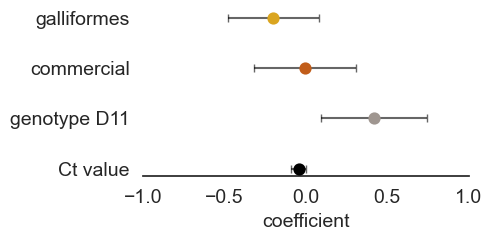

In [77]:
sns.set_theme(style="white", palette=None)

palette=['#daa520', '#C15D1A', '#9f9690', '#000']


plot_df = coef_df[coef_df['variable']!='Intercept']
# Draw a nested barplot by species and sex
g = sns.catplot(
    data=plot_df, kind="point",
    x="Coef.", y="variable",
    palette=palette, height=2.5, aspect=2, zorder=3
)


plt.errorbar(
    x=plot_df["Coef."],
    y=plot_df["variable"],
    xerr=[plot_df["Coef."] - plot_df["[0.025"], plot_df["0.975]"] - plot_df["Coef."]],
    fmt="none", color="black", alpha=0.6, capsize=3, linewidth=1.5, zorder=2
)

##renaming cleaner variable labels:
label_map = {
    "order_gall":          "galliformes",
    "domstat_comm": "commercial",
    "gtype_d11":           "genotype D11",
    "ct_value_norm":    "Ct value"
    # add the rest of your variables...
}

current_labels = [t.get_text() for t in plt.gca().get_yticklabels()]
plt.yticks(ticks=range(len(current_labels)),
           labels=[label_map.get(l, l) for l in current_labels],
           fontsize=14)


# plt.xticks([0, .1, .2], fontsize=12)
plt.xticks([-1.0, -0.5, 0.0, 0.5, 1.0], fontsize=14)

plt.yticks(fontsize=14)

g.despine(left=True)
g.set_axis_labels("coefficient", "", fontsize=14)

filename=('../output_plots/linreg-snvs-per-samp.pdf')
plt.savefig(filename, format='pdf', dpi=300)

In [272]:
##high probs omnibuus and JB = we dont reject the null hypothesis
##high condition number = multicollinearity- taking CT value out reduces Condition No. significantly- so suggests that Ct and genotype are 
##highly correlated?

In [267]:
# df

,sample_ID,count,date,ct_value,sample_id,snps_per_1kb,order_galliformes,domestic_status_commercial,genotype_D1.1
0,ckr_com1,21,2025-07-01,21.40,ckr_com1,1.709863,True,True,True
1,ckr_com3,18,2025-07-01,21.11,ckr_com3,1.357835,True,True,True
2,c_lbm5,16,2025-03-10,20.58,c_lbm5,1.336065,True,False,True
3,ckr_com2,15,2025-07-01,21.36,ckr_com2,1.073345,True,True,True
4,kc_com6,13,2023-02-23,21.93,kc_com6,0.960523,False,True,False
5,kc_com3,13,2023-02-23,20.74,kc_com3,1.072003,False,True,False
6,gn_lbm1,13,2025-02-20,20.41,gn_lbm1,1.160403,True,False,True
7,d_lbm2,13,2025-02-20,27.40,d_lbm2,1.448791,False,False,True
8,d_lbm3,12,2025-03-10,26.43,d_lbm3,1.292825,False,False,True
9,d_com2,12,2025-07-01,22.99,d_com2,1.182150,False,True,True


In [335]:
# df.to_csv('../../seq/analysis/output_dfs/sample_counts_dummy_norm.csv')

In [125]:
# model = smf.ols(
#     "count ~ order_galliformes * domestic_status_commercial * genotype_prev_genotype",
#     data=df
# ).fit()

# model.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  count   R-squared:                       0.245
Model:                            OLS   Adj. R-squared:                  0.115
Method:                 Least Squares   F-statistic:                     1.886
Date:                Fri, 27 Mar 2026   Prob (F-statistic):              0.128
Time:                        15:11:19   Log-Likelihood:                -94.367
No. Observations:                  35   AIC:                             200.7
Df Residuals:                      29   BIC:                             210.1
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
=================================================================================================================================================================
                                                                                                    coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------------------------------------------------------------
Intercept                                                                                         9.0000      1.762      5.107      0.000       5.396      12.604
order_galliformes[T.True]                                                                        -2.5455      2.125     -1.198      0.241      -6.892       1.801
domestic_status_commercial[T.True]                                                               -1.0000      2.878     -0.348      0.731      -6.885       4.885
year_group_prev_genotype[T.True]                                                                 -1.5000      1.360     -1.103      0.279      -4.281       1.281
order_galliformes[T.True]:domestic_status_commercial[T.True]                                      5.7455      3.577      1.606      0.119      -1.571      13.062
order_galliformes[T.True]:year_group_prev_genotype[T.True]                                       -1.2250      1.896     -0.646      0.523      -5.103       2.653
domestic_status_commercial[T.True]:year_group_prev_genotype[T.True]                              -1.5000      1.360     -1.103      0.279      -4.281       1.281
order_galliformes[T.True]:domestic_status_commercial[T.True]:year_group_prev_genotype[T.True]    -1.2250      1.896     -0.646      0.523      -5.103       2.653
==============================================================================
Omnibus:                        0.174   Durbin-Watson:                   0.452
Prob(Omnibus):                  0.917   Jarque-Bera (JB):                0.385
Skew:                          -0.021   Prob(JB):                        0.825
Kurtosis:                       2.488   Cond. No.                     7.26e+16
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The smallest eigenvalue is 1.44e-32. This might indicate that there are
strong multicollinearity problems or that the design matrix is singular.
"""

<Axes: >

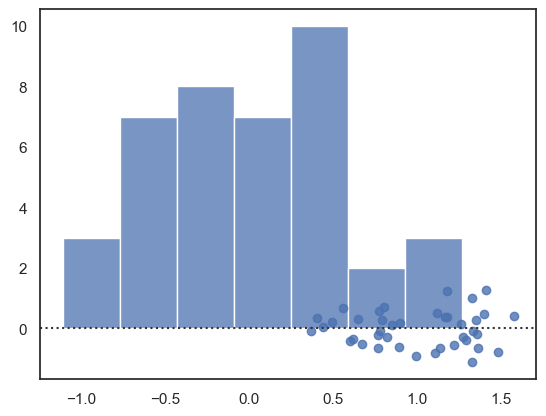

In [313]:
# sns.histplot(model.resid)
# sns.residplot(x=model.fittedvalues, y=model.resid)

In [137]:
print(f"Number of samples in pb2: {pb2['sample_ID'].nunique()}")
print(f"Number of samples in pb1: {pb1['sample_ID'].nunique()}")
print(f"Number of samples in pa: {pa['sample_ID'].nunique()}")
print(f"Number of samples in ha: {ha['sample_ID'].nunique()}")
print(f"Number of samples in np: {np['sample_ID'].nunique()}")
print(f"Number of samples in na: {na['sample_ID'].nunique()}")
print(f"Number of samples in ns1: {ns1['sample_ID'].nunique()}")
print(f"Number of samples in m1: {m1['sample_ID'].nunique()}")
print(f"Number of samples in m2: {m2['sample_ID'].nunique()}")
print(f"Number of samples in nep: {nep['sample_ID'].nunique()}")


Number of samples in pb2: 26
Number of samples in pb1: 27
Number of samples in pa: 23
Number of samples in ha: 18


TypeError: 'module' object is not subscriptable

In [72]:
print(shared_vars.columns)


Index(['segment', 'position', 'allele', 'coding_region_change', 'gene',
       'Frequency_1', 'Frequency_2', 'sample', 'amino_acid', 'gene_pos',
       'sample_var', 'syn_non', 'rep_shared', 'sample_ID', 'domestic_status',
       'ct_value', 'order', 'county', 'date', 'sample_species',
       'species_group', 'color', 'avg_freq', 'order_domstat', 'gene_pos_nt'],
      dtype='object')


In [5]:

# shared_vars = pd.read_csv('../output_dfs/2026-05-13_repshared_SNVs_allcom_lbm_2pct.tsv', sep='\t')

In [112]:
# Group by 'sample_ID' and 'gene' and count unique values in 'synonymous/nonsynonymous'
syn_nonsyn_counts = shared_vars.groupby(['sample_ID', 'gene'])['syn_non'].value_counts().unstack(fill_value=0)

# Optionally, reset index to make it easier to work with
syn_nonsyn_counts = syn_nonsyn_counts.reset_index()

# Print or export the result
syn_nonsyn_counts


syn_non,sample_ID,gene,nonsynonymous,synonymous
0,c_com5,NA,4,0
1,c_com5,PA,0,2
2,c_com5,PB1,1,2
3,c_com6,NA,0,1
4,c_com6,NP,0,1
...,...,...,...,...
153,kc_com6,PB1,0,2
154,kc_com6,PB2,0,2
155,kc_com7,NP,0,1
156,kc_com7,PB2,0,1


In [113]:
# Group by 'sample_ID' and 'gene' and count unique values in 'synonymous/nonsynonymous'
syn_nonsyn_counts = shared_vars.groupby(['sample_ID'])['syn_non'].value_counts().unstack(fill_value=0)

# Optionally, reset index to make it easier to work with
total_syn_nonsyn_counts = syn_nonsyn_counts.reset_index()
total_syn_nonsyn_counts = total_syn_nonsyn_counts.rename_axis(None, axis=1).reset_index()

total_syn_nonsyn_counts = total_syn_nonsyn_counts.drop(columns=['index'])

# Print or export the result
total_syn_nonsyn_counts.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   sample_ID      36 non-null     object
 1   nonsynonymous  36 non-null     int64 
 2   synonymous     36 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 996.0+ bytes


In [114]:
total_syn_nonsyn_counts

,sample_ID,nonsynonymous,synonymous
0,c_com5,5,4
1,c_com6,0,3
2,c_lbm1,1,4
3,c_lbm10,2,5
4,c_lbm11,2,4
5,c_lbm2,3,5
6,c_lbm3,0,1
7,c_lbm5,10,6
8,c_lbm6,4,3
9,c_lbm7,6,5


In [115]:
##pulling out variants that appear in more than one sample

# Assuming your dataframe is named 'df'
duplicated_gene_pos = shared_vars[shared_vars['gene_pos'].duplicated()]

# To get just the duplicated values in the 'gene_pos' column
duplicated_values = shared_vars[shared_vars['gene_pos'].duplicated()]['gene_pos'].unique()

# Print the duplicated values
print(duplicated_values)

['HA_551' 'PA_366' 'NP_186' 'NS1_101' 'NA_71' 'NA_322' 'NA_393' 'PA_394'
 'PB2_339' 'NP_82' 'NP_236' 'NS1_53' 'PB1_410' 'PB2_544' 'NP_180'
 'PB2_640' 'HA_538' 'NP_81' 'NS1_123' 'PB1_167' 'NA_215' 'NP_327'
 'PB1_635' 'PB2_353' 'NP_77' 'NP_166' 'NP_377' 'PA_618' 'PB1_296'
 'PB2_520' 'PB2_588' 'NP_96' 'PB1_598' 'HA_145' 'PB1_579' 'NA_324'
 'NA_418' 'PB2_682' 'NA_29' 'NA_134' 'NA_250' 'PB2_359' 'PA_84' 'M2_33'
 'PB1_75' 'NP_326']


In [116]:
duplicated_values.tolist()

['HA_551',
 'PA_366',
 'NP_186',
 'NS1_101',
 'NA_71',
 'NA_322',
 'NA_393',
 'PA_394',
 'PB2_339',
 'NP_82',
 'NP_236',
 'NS1_53',
 'PB1_410',
 'PB2_544',
 'NP_180',
 'PB2_640',
 'HA_538',
 'NP_81',
 'NS1_123',
 'PB1_167',
 'NA_215',
 'NP_327',
 'PB1_635',
 'PB2_353',
 'NP_77',
 'NP_166',
 'NP_377',
 'PA_618',
 'PB1_296',
 'PB2_520',
 'PB2_588',
 'NP_96',
 'PB1_598',
 'HA_145',
 'PB1_579',
 'NA_324',
 'NA_418',
 'PB2_682',
 'NA_29',
 'NA_134',
 'NA_250',
 'PB2_359',
 'PA_84',
 'M2_33',
 'PB1_75',
 'NP_326']

In [117]:
# Assuming your dataframe is named 'df' and the list of values is 'specific_values'

# Filter the rows where 'gene_pos' is in the specific list of values
filtered_rows = shared_vars[shared_vars['gene_pos'].isin(duplicated_values)]

# Print the filtered rows
print(filtered_rows)


     segment  position allele coding_region_change gene  Frequency_1  \
128       ha      1679      C            Leu551Leu   HA       0.2365   
129       np       291      C             His82His   NP       0.2385   
130       np       753      A            Arg236Arg   NP       0.1059   
134       pa      1122      A            Leu366Leu   PA       0.1072   
135      pb1       247      A             Lys75Glu  PB1       0.4841   
...      ...       ...    ...                  ...  ...          ...   
1055     pb1      1254      T            Gly410Gly  PB1       0.0715   
1058     pb2      1659      A            Ser544Ser  PB2       0.4205   
1067      np      1023      T            Ser326Ser   NP       0.1652   
1081     pb2      1659      A            Ser544Ser  PB2       0.3472   
1115     pb1      1254      T            Gly410Gly  PB1       0.0299   

      Frequency_2   sample amino_acid gene_pos  ...         order  \
128        0.2464  c_lbm10        551   HA_551  ...   galliformes 

In [118]:
filtered_rows['gene_pos'].nunique

<bound method IndexOpsMixin.nunique of 128      HA_551
129       NP_82
130      NP_236
134      PA_366
135      PB1_75
         ...   
1055    PB1_410
1058    PB2_544
1067     NP_326
1081    PB2_544
1115    PB1_410
Name: gene_pos, Length: 138, dtype: object>

In [119]:
filtered_rows = filtered_rows.sort_values(by=["gene", "position"], ascending=[False, True])
filtered_rows

,segment,position,allele,coding_region_change,gene,Frequency_1,Frequency_2,sample,amino_acid,gene_pos,...,order,county,date,species,species_group,color,avg_freq,order_domstat,gene_pos_nt,genotype
256,pb2,1043,A,Lys339Thr,PB2,0.0716,0.0741,c_lbm5,339,PB2_339,...,galliformes,Philadelphia,2025-03-10,NaN,Galliformes,LBM_nonsynonymous,0.07285,galliformes_LBM,PB2_1043,D1.1
333,pb2,1043,A,Lys339Thr,PB2,0.2067,0.1916,c_lbm8,339,PB2_339,...,galliformes,Philadelphia,2025-03-10,NaN,Galliformes,LBM_nonsynonymous,0.19915,galliformes_LBM,PB2_1043,D1.1
469,pb2,1086,A,Lys353Lys,PB2,0.0244,0.0243,ckr_com1,353,PB2_353,...,galliformes,Lancaster,2025-07-01,NaN,Galliformes,commercial_synonymous,0.02435,galliformes_commercial,PB2_1086,D1.1
509,pb2,1086,A,Lys353Lys,PB2,0.0445,0.0521,ckr_com3,353,PB2_353,...,galliformes,Lancaster,2025-07-01,NaN,Galliformes,commercial_synonymous,0.04830,galliformes_commercial,PB2_1086,D1.1
487,pb2,1104,G,Gly359Gly,PB2,0.0279,0.0291,ckr_com2,359,PB2_359,...,galliformes,Lancaster,2025-07-01,NaN,Galliformes,commercial_synonymous,0.02850,galliformes_commercial,PB2_1104,D1.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
451,ha,1641,C,Ala538Val,HA,0.0553,0.0471,ckr_com1,538,HA_538,...,galliformes,Lancaster,2025-07-01,NaN,Galliformes,commercial_nonsynonymous,0.05120,galliformes_commercial,HA_1641,D1.1
475,ha,1641,C,Ala538Val,HA,0.0610,0.0556,ckr_com2,538,HA_538,...,galliformes,Lancaster,2025-07-01,NaN,Galliformes,commercial_nonsynonymous,0.05830,galliformes_commercial,HA_1641,D1.1
128,ha,1679,C,Leu551Leu,HA,0.2365,0.2464,c_lbm10,551,HA_551,...,galliformes,Philadelphia,2025-03-11,NaN,Galliformes,LBM_synonymous,0.24145,galliformes_LBM,HA_1679,D1.1
140,ha,1679,C,Leu551Leu,HA,0.2067,0.1290,c_lbm11,551,HA_551,...,galliformes,Philadelphia,2025-03-11,NaN,Galliformes,LBM_synonymous,0.16785,galliformes_LBM,HA_1679,D1.1


In [120]:
filtered_rows['gene'].value_counts()

gene
NP     31
PB2    28
PB1    23
NA     20
PA     18
NS1     9
HA      7
M2      2
Name: count, dtype: int64

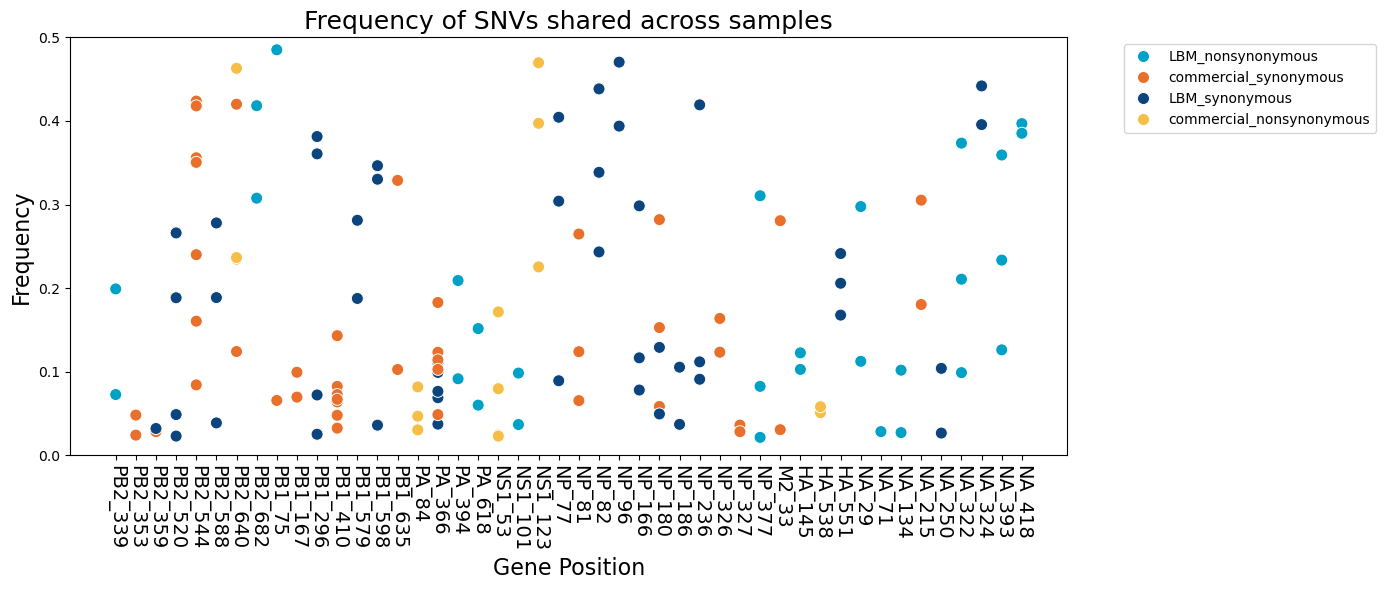

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# # Filter the dataframe
# pb1_shared = filtered_rows[filtered_rows["gene"] == "PB1"]

# Create the plot
plt.figure(figsize=(14, 6))
sns.scatterplot(data=filtered_rows, x="gene_pos", y="avg_freq", hue="color", palette=["#00A1C6", "#e8702a","#0c457d","#F5BF47"],
               s=75)

# Formatting
plt.xlabel("Gene Position", fontsize=16)
plt.ylabel("Frequency", fontsize=16)
plt.title("Frequency of SNVs shared across samples", fontsize=18)
plt.xticks(rotation=270, fontsize=14)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.ylim(0,0.5)
# plt.yscale('log')

# Show the plot
plt.tight_layout()

# plt.savefig('seq/analysis/figures/SNVs_shared_across_samples.pdf', dpi=300)
plt.show()


In [129]:
filtered_rows['gene_pos'].nunique()

46

In [150]:
filename = "../output_dfs/"+todays_date+"_shared_vars_between_samples_geneposAA-allcom.tsv"
filtered_rows.to_csv(filename, sep='\t', index=False)

In [55]:
###READ THIS FILE BACK IN TO RERUN FROM HERE
filtered_rows = pd.read_csv('../output_dfs/2026-05-05_shared_vars_between_samples_geneposAA-allcom.tsv', sep='\t')
filtered_rows

,segment,position,allele,coding_region_change,gene,Frequency_1,Frequency_2,sample,amino_acid,gene_pos,...,order,county,date,species,species_group,color,avg_freq,order_domstat,year_group,genotype
0,pb2,1043,A,Lys339Thr,PB2,0.0716,0.0741,c_lbm5,339,PB2_339,...,galliformes,Philadelphia,2025-03-10,NaN,Galliformes,LBM_nonsynonymous,0.07285,NaN,D1.1,D1.1
1,pb2,1043,A,Lys339Thr,PB2,0.2067,0.1916,c_lbm8,339,PB2_339,...,galliformes,Philadelphia,2025-03-10,NaN,Galliformes,LBM_nonsynonymous,0.19915,NaN,D1.1,D1.1
2,pb2,1086,A,Lys353Lys,PB2,0.0244,0.0243,ckr_com1,353,PB2_353,...,galliformes,Lancaster,2025-07-01,NaN,Galliformes,commercial_synonymous,0.02435,galliformes_commercial,D1.1,D1.1
3,pb2,1086,A,Lys353Lys,PB2,0.0445,0.0521,ckr_com3,353,PB2_353,...,galliformes,Lancaster,2025-07-01,NaN,Galliformes,commercial_synonymous,0.04830,galliformes_commercial,D1.1,D1.1
4,pb2,1104,G,Gly359Gly,PB2,0.0279,0.0291,ckr_com2,359,PB2_359,...,galliformes,Lancaster,2025-07-01,NaN,Galliformes,commercial_synonymous,0.02850,galliformes_commercial,D1.1,D1.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
133,ha,1641,C,Ala538Val,HA,0.0553,0.0471,ckr_com1,538,HA_538,...,galliformes,Lancaster,2025-07-01,NaN,Galliformes,commercial_nonsynonymous,0.05120,galliformes_commercial,D1.1,D1.1
134,ha,1641,C,Ala538Val,HA,0.0610,0.0556,ckr_com2,538,HA_538,...,galliformes,Lancaster,2025-07-01,NaN,Galliformes,commercial_nonsynonymous,0.05830,galliformes_commercial,D1.1,D1.1
135,ha,1679,C,Leu551Leu,HA,0.2365,0.2464,c_lbm10,551,HA_551,...,galliformes,Philadelphia,2025-03-11,NaN,Galliformes,LBM_synonymous,0.24145,NaN,D1.1,D1.1
136,ha,1679,C,Leu551Leu,HA,0.2067,0.1290,c_lbm11,551,HA_551,...,galliformes,Philadelphia,2025-03-11,NaN,Galliformes,LBM_synonymous,0.16785,NaN,D1.1,D1.1


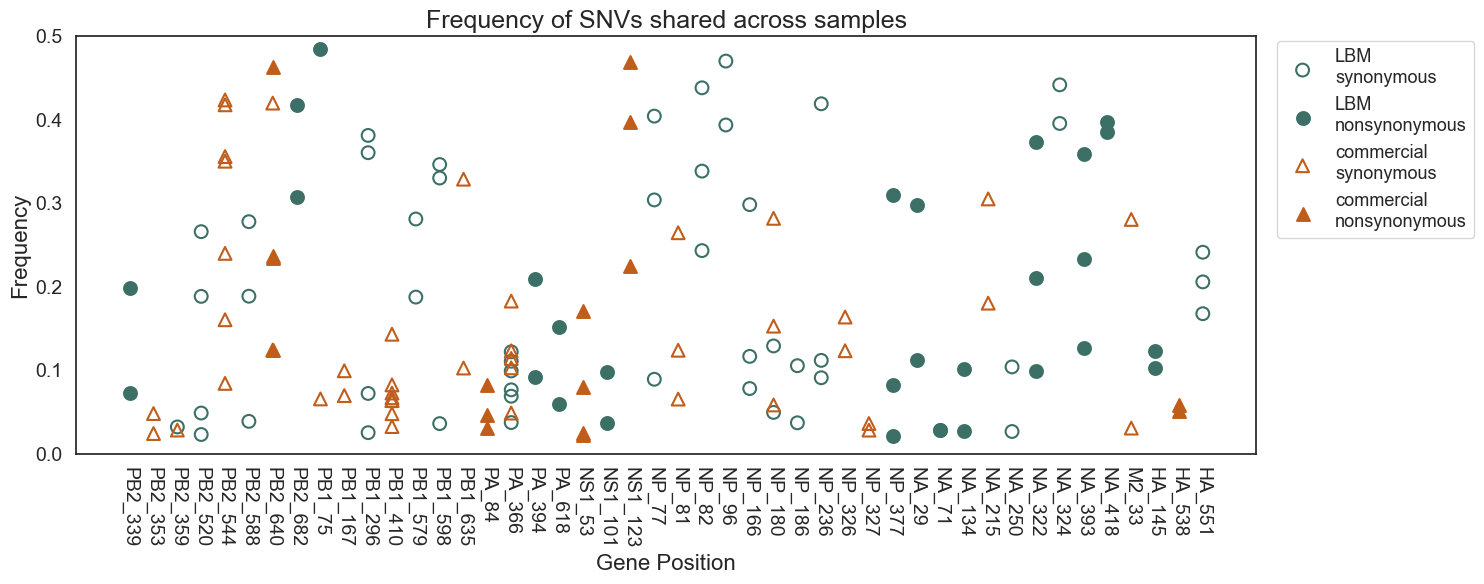

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Set style
sns.set(style="white")

# Define marker and style mappings
style_map = {
    "LBM_synonymous":            {"color": "#3C7067", "marker": "o", "fillstyle": "none"},
    "LBM_nonsynonymous":         {"color": "#3C7067", "marker": "o", "fillstyle": "full"},
    "commercial_synonymous":      {"color": "#C15D1A", "marker": "^", "fillstyle": "none"},
    "commercial_nonsynonymous":   {"color": "#C15D1A", "marker": "^", "fillstyle": "full"},
}


# # Ensure gene_pos is ordered categorically
filtered_rows['gene_pos'] = pd.Categorical(
    filtered_rows['gene_pos'],
    categories=filtered_rows['gene_pos'].unique(),
    ordered=True
)

# Create a figure
plt.figure(figsize=(15, 6))

# Plot each group with custom style
for category, specs in style_map.items():
    subset = filtered_rows[filtered_rows['color'] == category]
    sns.scatterplot(
        data=subset,
        x='gene_pos',
        y='avg_freq',
        marker=specs['marker'],
        edgecolor=specs['color'],
        facecolor='none' if specs['fillstyle'] == 'none' else specs['color'],
        linewidth=1.5,
        s=85,
        label=category.replace("_", "\n")
    )

# Axis formatting
plt.xlabel("Gene Position", fontsize=16)
plt.ylabel("Frequency", fontsize=16)
plt.title("Frequency of SNVs shared across samples", fontsize=18)
plt.xticks(rotation=270, fontsize=14)

plt.yticks(fontsize=14)
plt.tick_params(axis='both', direction='out', length=6, width=2)

plt.ylim(0, 0.5)
plt.legend(bbox_to_anchor=(1.01, 1.01), loc='upper left', fontsize=13)

plt.tight_layout()


filename = "../output_plots/shared_vars_across_samples_comm_lbm_"+todays_date+".pdf"
# plt.savefig(filename, format='pdf', bbox_inches='tight', dpi=300)

plt.show()


In [70]:
lbm_share = filtered_rows[filtered_rows['domestic_status'] == 'LBM']

lbm_share['gene_pos'].nunique()

31

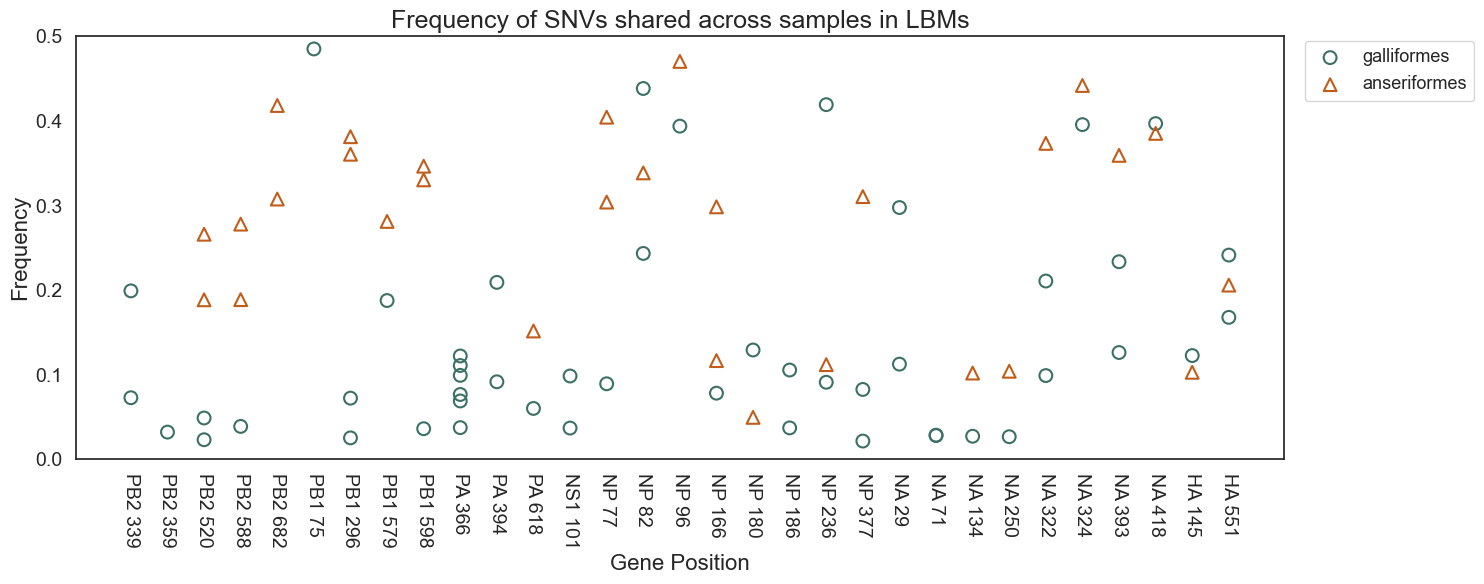

In [74]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Set style
sns.set(style="white")

##looking at sharing between host orders in just LBMs- so gonna filter df to just that
# lbm_share = filtered_rows[filtered_rows['domestic_status'] == 'LBM']

lbm_share = filtered_rows[filtered_rows['domestic_status'] == 'LBM'].copy()   # .copy() avoids SettingWithCopyWarning

# rebuild from only the values actually present
present = lbm_share['gene_pos'].astype(str).unique()
lbm_share['gene_pos'] = pd.Categorical(
    lbm_share['gene_pos'].astype(str),
    categories=present,
    ordered=True
)

# belt and suspenders, in case the dtype was already categorical
lbm_share['gene_pos'] = lbm_share['gene_pos'].cat.remove_unused_categories()

# Define marker and style mappings
# style_map = {
#     "LBM_synonymous":            {"color": "#3C7067", "marker": "o", "fillstyle": "none"},
#     "LBM_nonsynonymous":         {"color": "#3C7067", "marker": "o", "fillstyle": "full"},
#     "commercial_synonymous":      {"color": "#C15D1A", "marker": "^", "fillstyle": "none"},
#     "commercial_nonsynonymous":   {"color": "#C15D1A", "marker": "^", "fillstyle": "full"},
# }
style_map = {
    "galliformes":            {"color": "#3C7067", "marker": "o", "fillstyle": "none"},
    # "LBM_nonsynonymous":         {"color": "#3C7067", "marker": "o", "fillstyle": "full"},
    "anseriformes":      {"color": "#C15D1A", "marker": "^", "fillstyle": "none"}
    # "commercial_nonsynonymous":   {"color": "#C15D1A", "marker": "^", "fillstyle": "full"},
}

# # Ensure gene_pos is ordered categorically
# lbm_share['gene_pos'] = pd.Categorical(
#     lbm_share['gene_pos'],
#     categories=lbm_share['gene_pos'].unique(),
#     ordered=True
# )

# Create a figure
plt.figure(figsize=(15, 6))

# Plot each group with custom style
for category, specs in style_map.items():
    subset = lbm_share[lbm_share['order'] == category]
    sns.scatterplot(
        data=subset,
        x='gene_pos',
        y='avg_freq',
        marker=specs['marker'],
        edgecolor=specs['color'],
        facecolor='none' if specs['fillstyle'] == 'none' else specs['color'],
        linewidth=1.5,
        s=85,
        label=category.replace("_", "\n")
    )

# Axis formatting
plt.xlabel("Gene Position", fontsize=16)
plt.ylabel("Frequency", fontsize=16)
plt.title("Frequency of SNVs shared across samples in LBMs", fontsize=18)
plt.xticks(rotation=270, fontsize=14)

plt.yticks(fontsize=14)
plt.tick_params(axis='both', direction='out', length=6, width=2)

plt.ylim(0, 0.5)
plt.legend(bbox_to_anchor=(1.01, 1.01), loc='upper left', fontsize=13)

plt.tight_layout()


filename = "../output_plots/shared_vars_across_lbms_bw_hosts_"+todays_date+".pdf"
plt.savefig(filename, format='pdf', bbox_inches='tight', dpi=300)

plt.show()


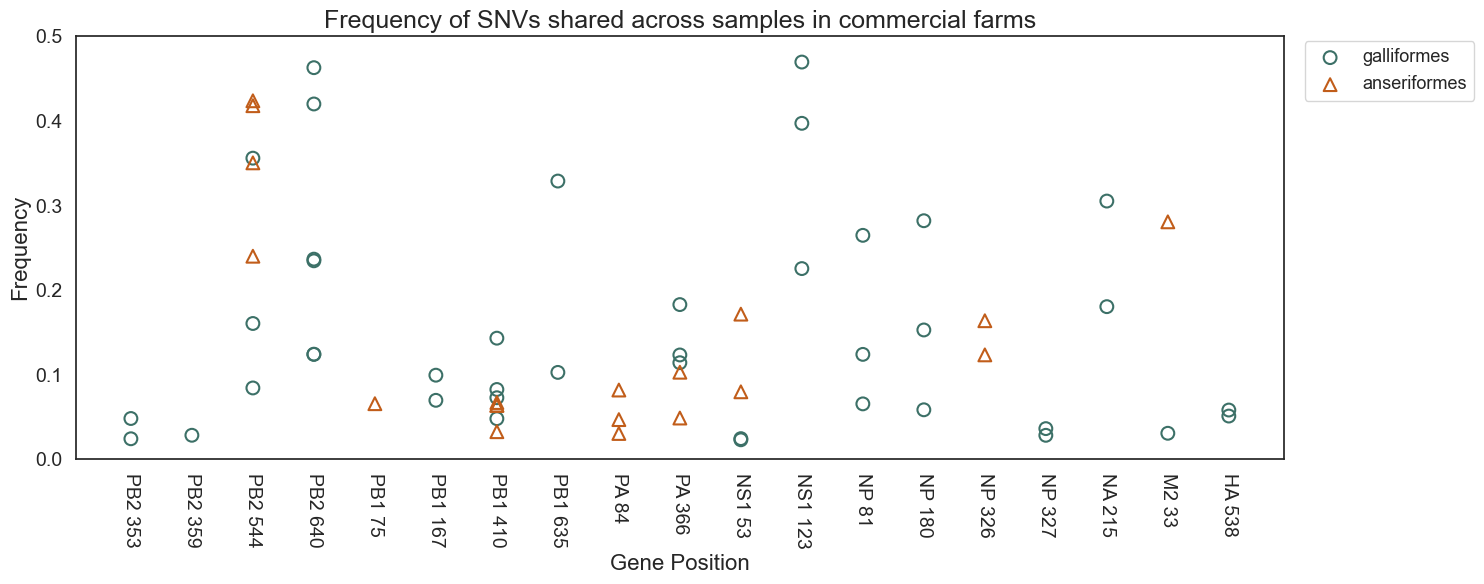

In [76]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Set style
sns.set(style="white")

##looking at sharing between host orders in just LBMs- so gonna filter df to just that
# lbm_share = filtered_rows[filtered_rows['domestic_status'] == 'LBM']

com_share = filtered_rows[filtered_rows['domestic_status'] == 'commercial'].copy()   # .copy() avoids SettingWithCopyWarning

# rebuild from only the values actually present
present = com_share['gene_pos'].astype(str).unique()
com_share['gene_pos'] = pd.Categorical(
    com_share['gene_pos'].astype(str),
    categories=present,
    ordered=True
)

# belt and suspenders, in case the dtype was already categorical
com_share['gene_pos'] = com_share['gene_pos'].cat.remove_unused_categories()

# Define marker and style mappings
# style_map = {
#     "LBM_synonymous":            {"color": "#3C7067", "marker": "o", "fillstyle": "none"},
#     "LBM_nonsynonymous":         {"color": "#3C7067", "marker": "o", "fillstyle": "full"},
#     "commercial_synonymous":      {"color": "#C15D1A", "marker": "^", "fillstyle": "none"},
#     "commercial_nonsynonymous":   {"color": "#C15D1A", "marker": "^", "fillstyle": "full"},
# }
style_map = {
    "galliformes":            {"color": "#3C7067", "marker": "o", "fillstyle": "none"},
    # "LBM_nonsynonymous":         {"color": "#3C7067", "marker": "o", "fillstyle": "full"},
    "anseriformes":      {"color": "#C15D1A", "marker": "^", "fillstyle": "none"}
    # "commercial_nonsynonymous":   {"color": "#C15D1A", "marker": "^", "fillstyle": "full"},
}

# # Ensure gene_pos is ordered categorically
# lbm_share['gene_pos'] = pd.Categorical(
#     lbm_share['gene_pos'],
#     categories=lbm_share['gene_pos'].unique(),
#     ordered=True
# )

# Create a figure
plt.figure(figsize=(15, 6))

# Plot each group with custom style
for category, specs in style_map.items():
    subset = com_share[com_share['order'] == category]
    sns.scatterplot(
        data=subset,
        x='gene_pos',
        y='avg_freq',
        marker=specs['marker'],
        edgecolor=specs['color'],
        facecolor='none' if specs['fillstyle'] == 'none' else specs['color'],
        linewidth=1.5,
        s=85,
        label=category.replace("_", "\n")
    )

# Axis formatting
plt.xlabel("Gene Position", fontsize=16)
plt.ylabel("Frequency", fontsize=16)
plt.title("Frequency of SNVs shared across samples in commercial farms", fontsize=18)
plt.xticks(rotation=270, fontsize=14)

plt.yticks(fontsize=14)
plt.tick_params(axis='both', direction='out', length=6, width=2)

plt.ylim(0, 0.5)
plt.legend(bbox_to_anchor=(1.01, 1.01), loc='upper left', fontsize=13)

plt.tight_layout()


filename = "../output_plots/shared_vars_across_comms_bw_hosts_"+todays_date+".pdf"
plt.savefig(filename, format='pdf', bbox_inches='tight', dpi=300)

plt.show()


In [57]:
filtered_rows['date'] = pd.to_datetime(filtered_rows['date'])
cluster_map = {
    pd.Timestamp("2023-02-23"): "cluster_1",
    pd.Timestamp("2023-02-24"): "cluster_2",
    pd.Timestamp("2025-01-26"): "cluster_3",
    pd.Timestamp("2025-02-20"): "cluster_4",
    pd.Timestamp("2025-03-10"): "cluster_5",
    pd.Timestamp("2025-03-11"): "cluster_5",
    pd.Timestamp("2025-07-01"): "cluster_6"
}

filtered_rows["outbreak"] = filtered_rows["date"].map(cluster_map)
filtered_rows

,segment,position,allele,coding_region_change,gene,Frequency_1,Frequency_2,sample,amino_acid,gene_pos,...,county,date,species,species_group,color,avg_freq,order_domstat,year_group,genotype,outbreak
0,pb2,1043,A,Lys339Thr,PB2,0.0716,0.0741,c_lbm5,339,PB2_339,...,Philadelphia,2025-03-10,NaN,Galliformes,LBM_nonsynonymous,0.07285,NaN,D1.1,D1.1,cluster_5
1,pb2,1043,A,Lys339Thr,PB2,0.2067,0.1916,c_lbm8,339,PB2_339,...,Philadelphia,2025-03-10,NaN,Galliformes,LBM_nonsynonymous,0.19915,NaN,D1.1,D1.1,cluster_5
2,pb2,1086,A,Lys353Lys,PB2,0.0244,0.0243,ckr_com1,353,PB2_353,...,Lancaster,2025-07-01,NaN,Galliformes,commercial_synonymous,0.02435,galliformes_commercial,D1.1,D1.1,cluster_6
3,pb2,1086,A,Lys353Lys,PB2,0.0445,0.0521,ckr_com3,353,PB2_353,...,Lancaster,2025-07-01,NaN,Galliformes,commercial_synonymous,0.04830,galliformes_commercial,D1.1,D1.1,cluster_6
4,pb2,1104,G,Gly359Gly,PB2,0.0279,0.0291,ckr_com2,359,PB2_359,...,Lancaster,2025-07-01,NaN,Galliformes,commercial_synonymous,0.02850,galliformes_commercial,D1.1,D1.1,cluster_6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
133,ha,1641,C,Ala538Val,HA,0.0553,0.0471,ckr_com1,538,HA_538,...,Lancaster,2025-07-01,NaN,Galliformes,commercial_nonsynonymous,0.05120,galliformes_commercial,D1.1,D1.1,cluster_6
134,ha,1641,C,Ala538Val,HA,0.0610,0.0556,ckr_com2,538,HA_538,...,Lancaster,2025-07-01,NaN,Galliformes,commercial_nonsynonymous,0.05830,galliformes_commercial,D1.1,D1.1,cluster_6
135,ha,1679,C,Leu551Leu,HA,0.2365,0.2464,c_lbm10,551,HA_551,...,Philadelphia,2025-03-11,NaN,Galliformes,LBM_synonymous,0.24145,NaN,D1.1,D1.1,cluster_5
136,ha,1679,C,Leu551Leu,HA,0.2067,0.1290,c_lbm11,551,HA_551,...,Philadelphia,2025-03-11,NaN,Galliformes,LBM_synonymous,0.16785,NaN,D1.1,D1.1,cluster_5


In [58]:
filtered_rows["clust_syn_non"] = filtered_rows["outbreak"] + "_" + filtered_rows["syn_non"]

filtered_rows

,segment,position,allele,coding_region_change,gene,Frequency_1,Frequency_2,sample,amino_acid,gene_pos,...,date,species,species_group,color,avg_freq,order_domstat,year_group,genotype,outbreak,clust_syn_non
0,pb2,1043,A,Lys339Thr,PB2,0.0716,0.0741,c_lbm5,339,PB2_339,...,2025-03-10,NaN,Galliformes,LBM_nonsynonymous,0.07285,NaN,D1.1,D1.1,cluster_5,cluster_5_nonsynonymous
1,pb2,1043,A,Lys339Thr,PB2,0.2067,0.1916,c_lbm8,339,PB2_339,...,2025-03-10,NaN,Galliformes,LBM_nonsynonymous,0.19915,NaN,D1.1,D1.1,cluster_5,cluster_5_nonsynonymous
2,pb2,1086,A,Lys353Lys,PB2,0.0244,0.0243,ckr_com1,353,PB2_353,...,2025-07-01,NaN,Galliformes,commercial_synonymous,0.02435,galliformes_commercial,D1.1,D1.1,cluster_6,cluster_6_synonymous
3,pb2,1086,A,Lys353Lys,PB2,0.0445,0.0521,ckr_com3,353,PB2_353,...,2025-07-01,NaN,Galliformes,commercial_synonymous,0.04830,galliformes_commercial,D1.1,D1.1,cluster_6,cluster_6_synonymous
4,pb2,1104,G,Gly359Gly,PB2,0.0279,0.0291,ckr_com2,359,PB2_359,...,2025-07-01,NaN,Galliformes,commercial_synonymous,0.02850,galliformes_commercial,D1.1,D1.1,cluster_6,cluster_6_synonymous
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
133,ha,1641,C,Ala538Val,HA,0.0553,0.0471,ckr_com1,538,HA_538,...,2025-07-01,NaN,Galliformes,commercial_nonsynonymous,0.05120,galliformes_commercial,D1.1,D1.1,cluster_6,cluster_6_nonsynonymous
134,ha,1641,C,Ala538Val,HA,0.0610,0.0556,ckr_com2,538,HA_538,...,2025-07-01,NaN,Galliformes,commercial_nonsynonymous,0.05830,galliformes_commercial,D1.1,D1.1,cluster_6,cluster_6_nonsynonymous
135,ha,1679,C,Leu551Leu,HA,0.2365,0.2464,c_lbm10,551,HA_551,...,2025-03-11,NaN,Galliformes,LBM_synonymous,0.24145,NaN,D1.1,D1.1,cluster_5,cluster_5_synonymous
136,ha,1679,C,Leu551Leu,HA,0.2067,0.1290,c_lbm11,551,HA_551,...,2025-03-11,NaN,Galliformes,LBM_synonymous,0.16785,NaN,D1.1,D1.1,cluster_5,cluster_5_synonymous


In [59]:
filtered_rows['gene_pos'] = filtered_rows['gene_pos'].str.replace('_', ' ', regex=False)
filtered_rows

,segment,position,allele,coding_region_change,gene,Frequency_1,Frequency_2,sample,amino_acid,gene_pos,...,date,species,species_group,color,avg_freq,order_domstat,year_group,genotype,outbreak,clust_syn_non
0,pb2,1043,A,Lys339Thr,PB2,0.0716,0.0741,c_lbm5,339,PB2 339,...,2025-03-10,NaN,Galliformes,LBM_nonsynonymous,0.07285,NaN,D1.1,D1.1,cluster_5,cluster_5_nonsynonymous
1,pb2,1043,A,Lys339Thr,PB2,0.2067,0.1916,c_lbm8,339,PB2 339,...,2025-03-10,NaN,Galliformes,LBM_nonsynonymous,0.19915,NaN,D1.1,D1.1,cluster_5,cluster_5_nonsynonymous
2,pb2,1086,A,Lys353Lys,PB2,0.0244,0.0243,ckr_com1,353,PB2 353,...,2025-07-01,NaN,Galliformes,commercial_synonymous,0.02435,galliformes_commercial,D1.1,D1.1,cluster_6,cluster_6_synonymous
3,pb2,1086,A,Lys353Lys,PB2,0.0445,0.0521,ckr_com3,353,PB2 353,...,2025-07-01,NaN,Galliformes,commercial_synonymous,0.04830,galliformes_commercial,D1.1,D1.1,cluster_6,cluster_6_synonymous
4,pb2,1104,G,Gly359Gly,PB2,0.0279,0.0291,ckr_com2,359,PB2 359,...,2025-07-01,NaN,Galliformes,commercial_synonymous,0.02850,galliformes_commercial,D1.1,D1.1,cluster_6,cluster_6_synonymous
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
133,ha,1641,C,Ala538Val,HA,0.0553,0.0471,ckr_com1,538,HA 538,...,2025-07-01,NaN,Galliformes,commercial_nonsynonymous,0.05120,galliformes_commercial,D1.1,D1.1,cluster_6,cluster_6_nonsynonymous
134,ha,1641,C,Ala538Val,HA,0.0610,0.0556,ckr_com2,538,HA 538,...,2025-07-01,NaN,Galliformes,commercial_nonsynonymous,0.05830,galliformes_commercial,D1.1,D1.1,cluster_6,cluster_6_nonsynonymous
135,ha,1679,C,Leu551Leu,HA,0.2365,0.2464,c_lbm10,551,HA 551,...,2025-03-11,NaN,Galliformes,LBM_synonymous,0.24145,NaN,D1.1,D1.1,cluster_5,cluster_5_synonymous
136,ha,1679,C,Leu551Leu,HA,0.2067,0.1290,c_lbm11,551,HA 551,...,2025-03-11,NaN,Galliformes,LBM_synonymous,0.16785,NaN,D1.1,D1.1,cluster_5,cluster_5_synonymous


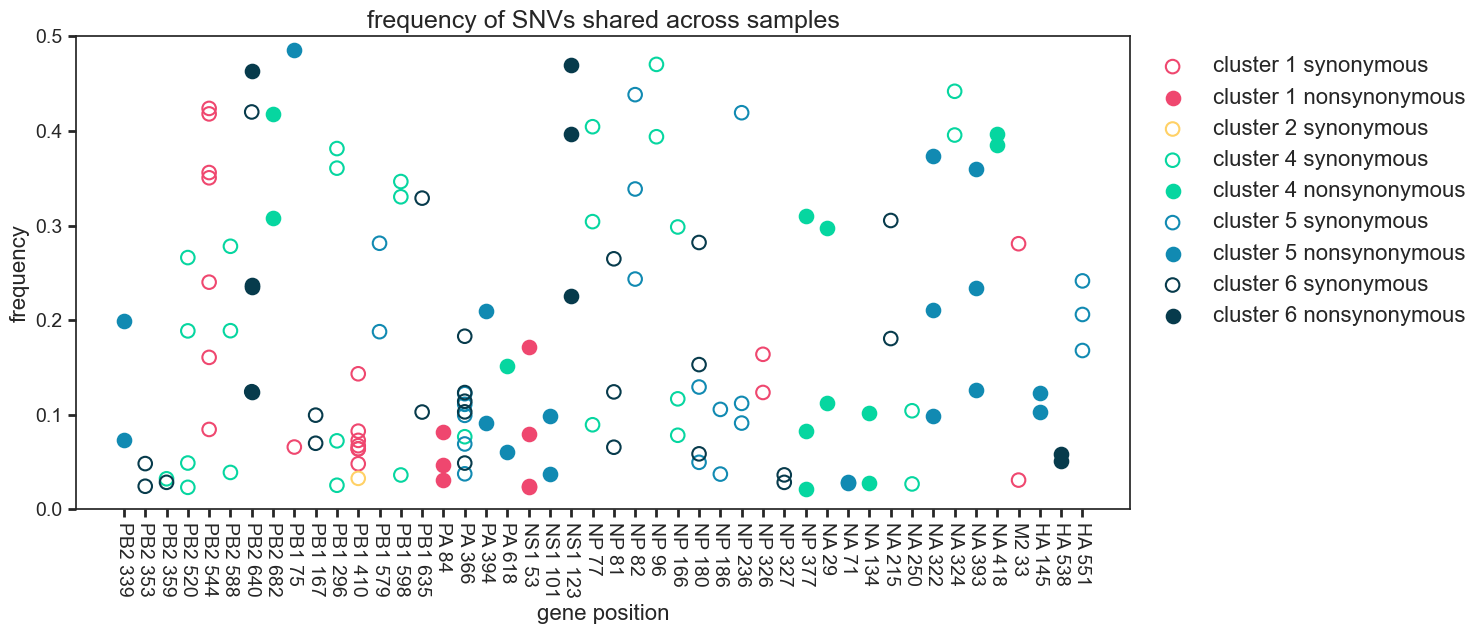

In [64]:
##for when i update with outbreak cluster and try coloring by that

# style_map = {
#     # Cluster 1 - bubblegum pink
#     # "clust1_synonymous":      {"color": "#ef476f", "marker": "o", "fillstyle": "none"},
#     "cluster_1":   {"color": "#ffd166", "marker": "o", "fillstyle": "full"},

#     # Cluster 2 - royal gold
#     # "clust2_synonymous":      {"color": "#ffd166", "marker": "^", "fillstyle": "none"},
#     "cluster_2":   {"color": "#ffd166", "marker": "o", "fillstyle": "full"},

#     # Cluster 3 - emerald
#     # "clust3_synonymous":      {"color": "#06d6a0", "marker": "s", "fillstyle": "none"},
#     "cluster_3":   {"color": "#06d6a0", "marker": "o", "fillstyle": "full"},

#     # Cluster 4 - ocean blue
#     # "clust4_synonymous":      {"color": "#118ab2", "marker": "D", "fillstyle": "none"},
#     "cluster_4":   {"color": "#118ab2", "marker": "o", "fillstyle": "full"},

#     # Cluster 5 - dark teal
#     # "clust5_synonymous":      {"color": "#073b4c", "marker": "v", "fillstyle": "none"},
#     "cluster_5":   {"color": "#073b4c", "marker": "o", "fillstyle": "full"},
# }

style_map = {
    # Cluster 1 - bubblegum pink
    "cluster_1_synonymous":      {"color": "#ef476f", "marker": "o", "fillstyle": "none"},
    "cluster_1_nonsynonymous":   {"color": "#ef476f", "marker": "o", "fillstyle": "full"},

    # Cluster 2 - royal gold
    "cluster_2_synonymous":      {"color": "#ffd166", "marker": "o", "fillstyle": "none"},
    "cluster_2_nonsynonymous":   {"color": "#ffd166", "marker": "o", "fillstyle": "full"},

    # Cluster 3 - orange
    "cluster_3_synonymous":      {"color": "#FF7518", "marker": "o", "fillstyle": "none"},
    "cluster_3_nonsynonymous":   {"color": "#FF7518", "marker": "o", "fillstyle": "full"},

    # Cluster 4 - ocean blue
    "cluster_4_synonymous":      {"color": "#06d6a0", "marker": "o", "fillstyle": "none"},
    "cluster_4_nonsynonymous":   {"color": "#06d6a0", "marker": "o", "fillstyle": "full"},

    # Cluster 5 - dark teal
    "cluster_5_synonymous":      {"color": "#118ab2", "marker": "o", "fillstyle": "none"},
    "cluster_5_nonsynonymous":   {"color": "#118ab2", "marker": "o", "fillstyle": "full"},


    # Cluster 6 - darkblue teal
    "cluster_6_synonymous":      {"color": "#073b4c", "marker": "o", "fillstyle": "none"},
    "cluster_6_nonsynonymous":   {"color": "#073b4c", "marker": "o", "fillstyle": "full"}
}



segment_order = ["PB2", "PB1", "PA", "HA", "NP", "NA", "M1", "M2", "NS1", "NEP"]
segment_rank = {seg: i for i, seg in enumerate(segment_order)}

def sort_key(gene_pos):
    # Split "PB2_1045" → segment="PB2", position=1045
    parts = str(gene_pos).split("_")
    segment = parts[0]
    position = int(parts[1]) if len(parts) > 1 and parts[1].isdigit() else 0
    return (segment_rank.get(segment, 999), position)

sorted_categories = sorted(
    filtered_rows['gene_pos'].unique(),
    key=sort_key
)


# # Ensure gene_pos is ordered categorically
filtered_rows['gene_pos'] = pd.Categorical(
    filtered_rows['gene_pos'],
    categories=filtered_rows['gene_pos'].unique(),
    ordered=True
)

filtered_rows = filtered_rows.sort_values('gene_pos')

##add so the axis ticks will show up
sns.set_style("ticks")

# Create a figure
plt.figure(figsize=(15, 6.5))

# Plot each group with custom style
for category, specs in style_map.items():
    subset = filtered_rows[filtered_rows['clust_syn_non'] == category]
    sns.scatterplot(
        data=subset,
        x='gene_pos',
        y='avg_freq',
        marker=specs['marker'],
        edgecolor=specs['color'],
        facecolor='none' if specs['fillstyle'] == 'none' else specs['color'],
        # alpha=0.8,
        linewidth=1.5,
        s=95,
        label=category.replace("_", " "),

    )

# Axis formatting
plt.xlabel("gene position", fontsize=16)
plt.ylabel("frequency", fontsize=16)
plt.title("frequency of SNVs shared across samples", fontsize=18)
plt.xticks(rotation=270, fontsize=14)


# Force x-axis to respect sorted order
plt.xticks(
    ticks=range(len(sorted_categories)),
    labels=sorted_categories,
    rotation=270,
    fontsize=14
)


plt.yticks(fontsize=14)
plt.tick_params(axis='both', direction='out', length=6, width=2)

plt.ylim(0, 0.5)
plt.legend(bbox_to_anchor=(1.0, 1.0), loc='upper left', fontsize=16, frameon=False)

plt.tight_layout()

filename = "../output_plots/shared_vars_across_clusters_"+todays_date+".png"
plt.savefig(filename, format='png', bbox_inches='tight', dpi=300)

plt.show()

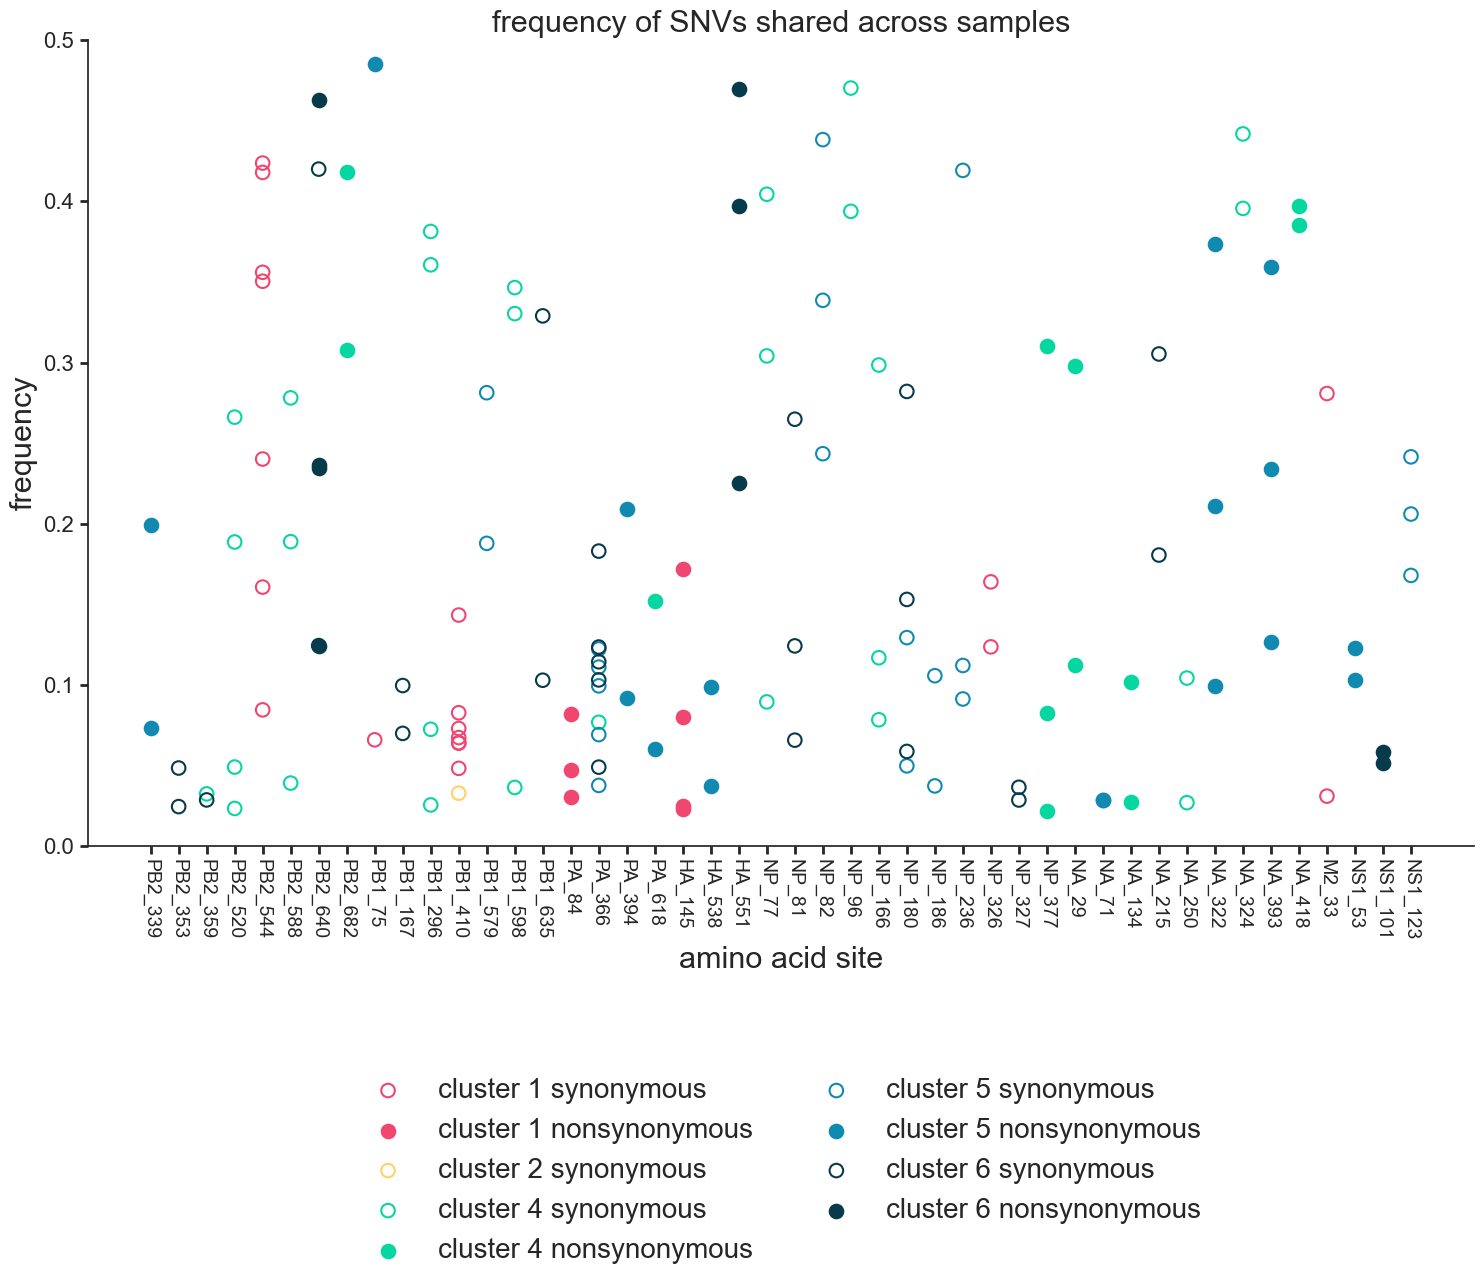

In [138]:
##for when i update with outbreak cluster and try coloring by that

# style_map = {
#     # Cluster 1 - bubblegum pink
#     # "clust1_synonymous":      {"color": "#ef476f", "marker": "o", "fillstyle": "none"},
#     "cluster_1":   {"color": "#ffd166", "marker": "o", "fillstyle": "full"},

#     # Cluster 2 - royal gold
#     # "clust2_synonymous":      {"color": "#ffd166", "marker": "^", "fillstyle": "none"},
#     "cluster_2":   {"color": "#ffd166", "marker": "o", "fillstyle": "full"},

#     # Cluster 3 - emerald
#     # "clust3_synonymous":      {"color": "#06d6a0", "marker": "s", "fillstyle": "none"},
#     "cluster_3":   {"color": "#06d6a0", "marker": "o", "fillstyle": "full"},

#     # Cluster 4 - ocean blue
#     # "clust4_synonymous":      {"color": "#118ab2", "marker": "D", "fillstyle": "none"},
#     "cluster_4":   {"color": "#118ab2", "marker": "o", "fillstyle": "full"},

#     # Cluster 5 - dark teal
#     # "clust5_synonymous":      {"color": "#073b4c", "marker": "v", "fillstyle": "none"},
#     "cluster_5":   {"color": "#073b4c", "marker": "o", "fillstyle": "full"},
# }

style_map = {
    # Cluster 1 - bubblegum pink
    "cluster_1_synonymous":      {"color": "#ef476f", "marker": "o", "fillstyle": "none"},
    "cluster_1_nonsynonymous":   {"color": "#ef476f", "marker": "o", "fillstyle": "full"},

    # Cluster 2 - royal gold
    "cluster_2_synonymous":      {"color": "#ffd166", "marker": "o", "fillstyle": "none"},
    "cluster_2_nonsynonymous":   {"color": "#ffd166", "marker": "o", "fillstyle": "full"},

    # Cluster 3 - orange
    "cluster_3_synonymous":      {"color": "#FF7518", "marker": "o", "fillstyle": "none"},
    "cluster_3_nonsynonymous":   {"color": "#FF7518", "marker": "o", "fillstyle": "full"},

    # Cluster 4 - ocean blue
    "cluster_4_synonymous":      {"color": "#06d6a0", "marker": "o", "fillstyle": "none"},
    "cluster_4_nonsynonymous":   {"color": "#06d6a0", "marker": "o", "fillstyle": "full"},

    # Cluster 5 - dark teal
    "cluster_5_synonymous":      {"color": "#118ab2", "marker": "o", "fillstyle": "none"},
    "cluster_5_nonsynonymous":   {"color": "#118ab2", "marker": "o", "fillstyle": "full"},


    # Cluster 6 - darkblue teal
    "cluster_6_synonymous":      {"color": "#073b4c", "marker": "o", "fillstyle": "none"},
    "cluster_6_nonsynonymous":   {"color": "#073b4c", "marker": "o", "fillstyle": "full"}
}




segment_order = ["PB2", "PB1", "PA", "HA", "NP", "NA", "M1", "M2", "NS1", "NEP"]
segment_rank = {seg: i for i, seg in enumerate(segment_order)}

def sort_key(gene_pos):
    # Split "PB2_1045" → segment="PB2", position=1045
    parts = str(gene_pos).split("_")
    segment = parts[0]
    position = int(parts[1]) if len(parts) > 1 and parts[1].isdigit() else 0
    return (segment_rank.get(segment, 999), position)

sorted_categories = sorted(
    filtered_rows['gene_pos'].unique(),
    key=sort_key
)


# # Ensure gene_pos is ordered categorically
filtered_rows['gene_pos'] = pd.Categorical(
    filtered_rows['gene_pos'],
    categories=filtered_rows['gene_pos'].unique(),
    ordered=True
)

filtered_rows = filtered_rows.sort_values('gene_pos')

##add so the axis ticks will show up
sns.set_style("ticks")

# Create a figure
plt.figure(figsize=(15, 10))

# Plot each group with custom style
for category, specs in style_map.items():
    subset = filtered_rows[filtered_rows['clust_syn_non'] == category]
    sns.scatterplot(
        data=subset,
        x='gene_pos',
        y='avg_freq',
        marker=specs['marker'],
        edgecolor=specs['color'],
        facecolor='none' if specs['fillstyle'] == 'none' else specs['color'],
        # alpha=0.8,
        linewidth=1.5,
        s=95,
        label=category.replace("_", " "),

    )

# Axis formatting
plt.xlabel("amino acid site", fontsize=22)
plt.ylabel("frequency", fontsize=22)
plt.title("frequency of SNVs shared across samples", fontsize=22)
plt.xticks(rotation=270, fontsize=15)


# Force x-axis to respect sorted order
plt.xticks(
    ticks=range(len(sorted_categories)),
    labels=sorted_categories,
    rotation=270,
    fontsize=14
)


plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.yticks(fontsize=16)
plt.tick_params(axis='both', direction='out', length=6, width=2)

plt.ylim(0, 0.5)
plt.tight_layout()


plt.legend(bbox_to_anchor=(0.5, -.55), loc='lower center', fontsize=20, ncol=2, frameon=False)

# plt.tight_layout()

filename = "../output_plots/shared_vars_across_clusters_legendfmt_poster"+todays_date+".png"
# plt.savefig(filename, format='png', bbox_inches='tight', dpi=300)

plt.show()

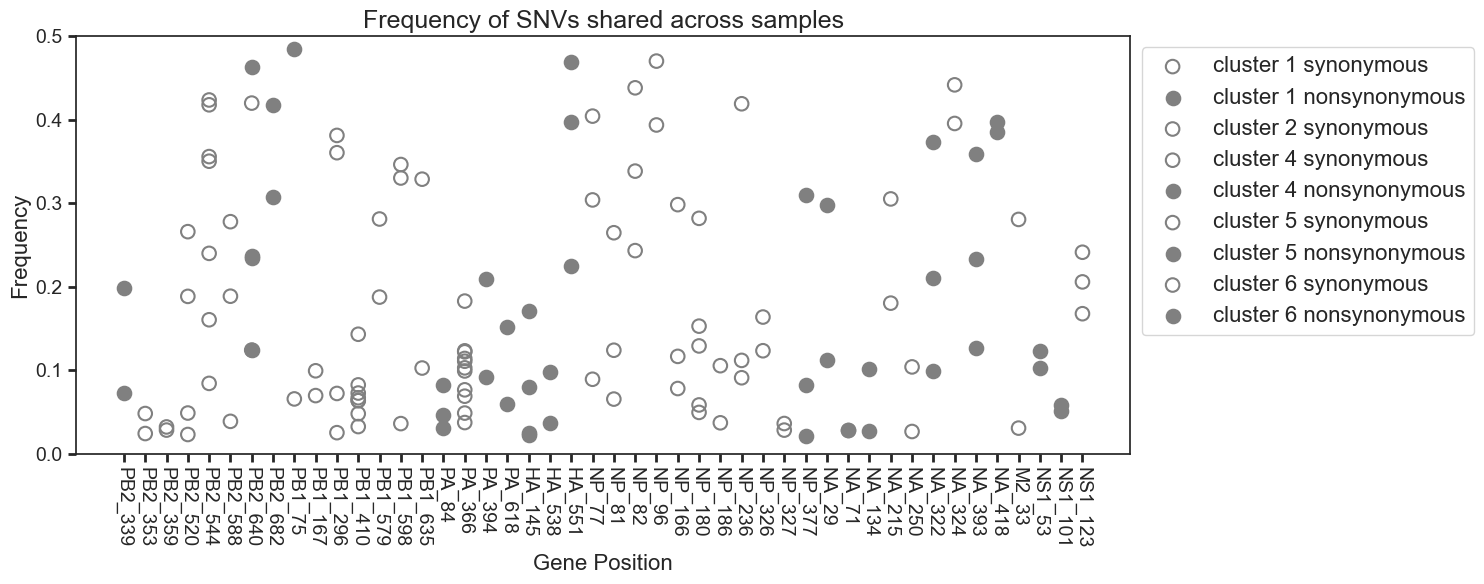

In [139]:
##for when i update with outbreak cluster and try coloring by that

# style_map = {
#     # Cluster 1 - bubblegum pink
#     # "clust1_synonymous":      {"color": "#ef476f", "marker": "o", "fillstyle": "none"},
#     "cluster_1":   {"color": "#ffd166", "marker": "o", "fillstyle": "full"},

#     # Cluster 2 - royal gold
#     # "clust2_synonymous":      {"color": "#ffd166", "marker": "^", "fillstyle": "none"},
#     "cluster_2":   {"color": "#ffd166", "marker": "o", "fillstyle": "full"},

#     # Cluster 3 - emerald
#     # "clust3_synonymous":      {"color": "#06d6a0", "marker": "s", "fillstyle": "none"},
#     "cluster_3":   {"color": "#06d6a0", "marker": "o", "fillstyle": "full"},

#     # Cluster 4 - ocean blue
#     # "clust4_synonymous":      {"color": "#118ab2", "marker": "D", "fillstyle": "none"},
#     "cluster_4":   {"color": "#118ab2", "marker": "o", "fillstyle": "full"},

#     # Cluster 5 - dark teal
#     # "clust5_synonymous":      {"color": "#073b4c", "marker": "v", "fillstyle": "none"},
#     "cluster_5":   {"color": "#073b4c", "marker": "o", "fillstyle": "full"},
# }

style_map = {
    # Cluster 1 - bubblegum pink
    "cluster_1_synonymous":      {"color": "gray", "marker": "o", "fillstyle": "none"},
    "cluster_1_nonsynonymous":   {"color": "gray", "marker": "o", "fillstyle": "full"},

    # Cluster 2 - royal gold
    "cluster_2_synonymous":      {"color": "gray", "marker": "o", "fillstyle": "none"},
    "cluster_2_nonsynonymous":   {"color": "gray", "marker": "o", "fillstyle": "full"},

    # Cluster 3 - emerald
    "cluster_3_synonymous":      {"color": "gray", "marker": "o", "fillstyle": "none"},
    "cluster_3_nonsynonymous":   {"color": "gray", "marker": "o", "fillstyle": "full"},

    # Cluster 4 - ocean blue
    "cluster_4_synonymous":      {"color": "gray", "marker": "o", "fillstyle": "none"},
    "cluster_4_nonsynonymous":   {"color": "gray", "marker": "o", "fillstyle": "full"},

    # Cluster 5 - dark teal
    "cluster_5_synonymous":      {"color": "gray", "marker": "o", "fillstyle": "none"},
    "cluster_5_nonsynonymous":   {"color": "gray", "marker": "o", "fillstyle": "full"},
    # Cluster 5 - dark teal
    "cluster_6_synonymous":      {"color": "gray", "marker": "o", "fillstyle": "none"},
    "cluster_6_nonsynonymous":   {"color": "gray", "marker": "o", "fillstyle": "full"},
}



segment_order = ["PB2", "PB1", "PA", "HA", "NP", "NA", "M1", "M2", "NS1", "NEP"]
segment_rank = {seg: i for i, seg in enumerate(segment_order)}

def sort_key(gene_pos):
    # Split "PB2_1045" → segment="PB2", position=1045
    parts = str(gene_pos).split("_")
    segment = parts[0]
    position = int(parts[1]) if len(parts) > 1 and parts[1].isdigit() else 0
    return (segment_rank.get(segment, 999), position)

sorted_categories = sorted(
    filtered_rows['gene_pos'].unique(),
    key=sort_key
)


# # Ensure gene_pos is ordered categorically
filtered_rows['gene_pos'] = pd.Categorical(
    filtered_rows['gene_pos'],
    categories=filtered_rows['gene_pos'].unique(),
    ordered=True
)

filtered_rows = filtered_rows.sort_values('gene_pos')

##add so the axis ticks will show up
sns.set_style("ticks")

# Create a figure
plt.figure(figsize=(15, 6))

# Plot each group with custom style
for category, specs in style_map.items():
    subset = filtered_rows[filtered_rows['clust_syn_non'] == category]
    sns.scatterplot(
        data=subset,
        x='gene_pos',
        y='avg_freq',
        marker=specs['marker'],
        edgecolor=specs['color'],
        facecolor='none' if specs['fillstyle'] == 'none' else specs['color'],
        # alpha=0.8,
        linewidth=1.5,
        s=95,
        label=category.replace("_", " "),

    )

# Axis formatting
plt.xlabel("Gene Position", fontsize=16)
plt.ylabel("Frequency", fontsize=16)
plt.title("Frequency of SNVs shared across samples", fontsize=18)
plt.xticks(rotation=270, fontsize=14)


# Force x-axis to respect sorted order
plt.xticks(
    ticks=range(len(sorted_categories)),
    labels=sorted_categories,
    rotation=270,
    fontsize=14
)


plt.yticks(fontsize=14)
plt.tick_params(axis='both', direction='out', length=6, width=2)

plt.ylim(0, 0.5)
plt.legend(bbox_to_anchor=(1.0, 1.0), loc='upper left', fontsize=16)

plt.tight_layout()

filename = "../output_plots/gray_pts_shared_vars_across_clusters_"+todays_date+".png"
# plt.savefig(filename, format='png', bbox_inches='tight', dpi=300)

plt.show()

In [140]:
# filtered_rows['gene_pos'].nunique()
filtered_rows['gene_pos'].nunique()
##30 lbm
##18 commercial

46

In [141]:
filtered_rows.head(45)

,segment,position,allele,coding_region_change,gene,Frequency_1,Frequency_2,sample,amino_acid,gene_pos,...,date,species,species_group,color,avg_freq,order_domstat,year_group,genotype,outbreak,clust_syn_non
0,pb2,1043,A,Lys339Thr,PB2,0.0716,0.0741,c_lbm5,339,PB2_339,...,2025-03-10,NaN,Galliformes,LBM_nonsynonymous,0.07285,NaN,D1.1,D1.1,cluster_5,cluster_5_nonsynonymous
1,pb2,1043,A,Lys339Thr,PB2,0.2067,0.1916,c_lbm8,339,PB2_339,...,2025-03-10,NaN,Galliformes,LBM_nonsynonymous,0.19915,NaN,D1.1,D1.1,cluster_5,cluster_5_nonsynonymous
2,pb2,1086,A,Lys353Lys,PB2,0.0244,0.0243,ckr_com1,353,PB2_353,...,2025-07-01,NaN,Galliformes,commercial_synonymous,0.02435,galliformes_commercial,D1.1,D1.1,cluster_6,cluster_6_synonymous
3,pb2,1086,A,Lys353Lys,PB2,0.0445,0.0521,ckr_com3,353,PB2_353,...,2025-07-01,NaN,Galliformes,commercial_synonymous,0.04830,galliformes_commercial,D1.1,D1.1,cluster_6,cluster_6_synonymous
4,pb2,1104,G,Gly359Gly,PB2,0.0279,0.0291,ckr_com2,359,PB2_359,...,2025-07-01,NaN,Galliformes,commercial_synonymous,0.02850,galliformes_commercial,D1.1,D1.1,cluster_6,cluster_6_synonymous
5,pb2,1104,G,Gly359Gly,PB2,0.0348,0.0297,gn_lbm1,359,PB2_359,...,2025-02-20,NaN,Galliformes,LBM_synonymous,0.03225,NaN,D1.1,D1.1,cluster_4,cluster_4_synonymous
6,pb2,1587,A,Glu520Glu,PB2,0.0521,0.0457,c_lbm2,520,PB2_520,...,2025-02-20,NaN,Galliformes,LBM_synonymous,0.04890,NaN,D1.1,D1.1,cluster_4,cluster_4_synonymous
7,pb2,1587,G,Glu520Glu,PB2,0.2941,0.2381,d_lbm1,520,PB2_520,...,2025-02-20,NaN,Anseriformes,LBM_synonymous,0.26610,NaN,D1.1,D1.1,cluster_4,cluster_4_synonymous
8,pb2,1587,A,Glu520Glu,PB2,0.2392,0.1380,d_lbm2,520,PB2_520,...,2025-02-20,NaN,Anseriformes,LBM_synonymous,0.18860,NaN,D1.1,D1.1,cluster_4,cluster_4_synonymous
9,pb2,1587,A,Glu520Glu,PB2,0.0228,0.0236,gn_lbm1,520,PB2_520,...,2025-02-20,NaN,Galliformes,LBM_synonymous,0.02320,NaN,D1.1,D1.1,cluster_4,cluster_4_synonymous


In [142]:
filename = "../output_dfs/"+todays_date+"shared_vars_across_clusters.tsv"
 
filtered_rows.to_csv(filename, sep='\t', index=False)

In [22]:
shared_vars.columns

Index(['segment', 'position', 'allele', 'coding_region_change', 'gene',
       'Frequency_1', 'Frequency_2', 'sample', 'amino_acid', 'gene_pos',
       'sample_var', 'syn_non', 'sample_ID', 'domestic_status', 'ct_value',
       'rep_shared', 'order', 'county', 'date', 'species', 'species_group',
       'color', 'avg_freq', 'order_domstat', 'gene_pos_nt', 'genotype'],
      dtype='object')

In [341]:
# ##looking at proportion of shared variants now
# # Step 1: Find which variants appear in more than one sample
# variant_sample_counts = shared_vars.groupby('gene_pos')['sample_ID'].nunique()
# shared_variants = set(variant_sample_counts[variant_sample_counts > 1].index)

# # Step 2: For each sample, calculate the proportion of its variants that are shared
# def shared_proportion(variants):
#     return variants.isin(shared_variants).mean()

# result = (
#     shared_vars.groupby('sample_ID')['gene_pos']
#     .agg(
#         total_variants='count',
#         shared_variants=lambda v: v.isin(shared_variants).sum(),
#         proportion_shared=shared_proportion
#     )
#     .reset_index()
# )

# print(result)

   sample_ID  total_variants  shared_variants  proportion_shared
0     c_com5               9                0           0.000000
1     c_com6               3                0           0.000000
2     c_lbm1               5                3           0.600000
3    c_lbm10               7                5           0.714286
4    c_lbm11               6                1           0.166667
5     c_lbm2               8                7           0.875000
6     c_lbm3               1                0           0.000000
7     c_lbm5              16                8           0.500000
8     c_lbm6               7                4           0.571429
9     c_lbm7              11                7           0.636364
10    c_lbm8              10                2           0.200000
11    c_lbm9               6                3           0.500000
12   cb_com1              11                4           0.363636
13   cb_com2               8                3           0.375000
14   cb_com3             

In [26]:
# db = pd.read_csv('../../seq/analysis/merged_flumina_2019_1aa.tsv', sep='\t')
db = pd.read_csv('../sample_data/2026-05-11-functional-db-fullmerge.tsv', sep='\t')

db.tail(10)

,Gene,Amino_Acid,Type,gene_pos,gene,change_info
740,NS,16.0,H5N1_nan,NS_16,8,H5N1_nan
741,NS,47.0,H5N1_nan,NS_47,8,H5N1_nan
742,NS,48.0,Wei et al. J. Virol. 2014,NS_48,8,Wei et al. J. Virol. 2014
743,NS,51.0,H5N1_nan,NS_51,8,H5N1_nan
744,NS,67.0,H9N2_nan,NS_67,8,H9N2_nan
745,NS,69.0,H5N2_nan,NS_69,8,H5N2_nan
746,NS,75.0,Mänz et al. Nat. Commun. 2012,NS_75,8,Mänz et al. Nat. Commun. 2012
747,NS,88.0,H3N2_nan,NS_88,8,H3N2_nan
748,NS,110.0,H9N2_nan,NS_110,8,H9N2_nan
749,NS,NaN,NaN,NS_nan,8,NaN


In [27]:
db.drop(columns=['gene'], inplace=True)
db

,Gene,Amino_Acid,Type,gene_pos,change_info
0,HA,91.0,human-adaptation,HA_91,NaN
1,HA,154.0,pathogenicity,HA_154,NaN
2,HA,158.0,host-adaptation,HA_158,NaN
3,HA,192.0,human-adaptation,HA_192,NaN
4,HA,228.0,human-adaptation,HA_228,NaN
...,...,...,...,...,...
745,NS,69.0,H5N2_nan,NS_69,H5N2_nan
746,NS,75.0,Mänz et al. Nat. Commun. 2012,NS_75,Mänz et al. Nat. Commun. 2012
747,NS,88.0,H3N2_nan,NS_88,H3N2_nan
748,NS,110.0,H9N2_nan,NS_110,H9N2_nan


In [28]:
db['Gene'] = db['Gene'].fillna("NA")
db = db.rename(columns={'Gene': 'gene'})
db = db.rename(columns={'Amino_Acid': 'amino_acid'})

db

,gene,amino_acid,Type,gene_pos,change_info
0,HA,91.0,human-adaptation,HA_91,NaN
1,HA,154.0,pathogenicity,HA_154,NaN
2,HA,158.0,host-adaptation,HA_158,NaN
3,HA,192.0,human-adaptation,HA_192,NaN
4,HA,228.0,human-adaptation,HA_228,NaN
...,...,...,...,...,...
745,NS,69.0,H5N2_nan,NS_69,H5N2_nan
746,NS,75.0,Mänz et al. Nat. Commun. 2012,NS_75,Mänz et al. Nat. Commun. 2012
747,NS,88.0,H3N2_nan,NS_88,H3N2_nan
748,NS,110.0,H9N2_nan,NS_110,H9N2_nan


In [29]:
db["change_info"] = db["change_info"].replace("", pd.NA).fillna("none_specified")

In [30]:
db.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750 entries, 0 to 749
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   gene         750 non-null    object 
 1   amino_acid   744 non-null    float64
 2   Type         745 non-null    object 
 3   gene_pos     750 non-null    object 
 4   change_info  750 non-null    object 
dtypes: float64(1), object(4)
memory usage: 29.4+ KB


In [125]:
# shared_vars['Amino_Acid'] = shared_vars['coding_region_change'].str.extract('(\d+)')
shared_vars['amino_acid'] = pd.to_numeric(shared_vars['amino_acid'], errors='coerce').astype('int64')


/var/folders/8h/zkgpnzwj7f9d82wldp_d4h_w0000gs/T/ipykernel_74939/3091982564.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [126]:
df_merged = shared_vars.merge(db, on=['amino_acid', 'gene', 'gene_pos'], how='left')
df_merged

,segment,position,allele,coding_region_change,gene,Frequency_1,Frequency_2,sample,amino_acid,gene_pos,...,date,species,species_group,color,avg_freq,order_domstat,gene_pos_nt,genotype,Type,change_info
0,na,43,T,Ile8Thr,NA,0.3326,0.3412,c_com5,8,NA_8,...,2025-01-26,NaN,Galliformes,commercial_nonsynonymous,0.33690,galliformes_commercial,NA_43,D1.1,NaN,NaN
1,na,67,T,Val16Ala,NA,0.2439,0.2890,c_com5,16,NA_16,...,2025-01-26,NaN,Galliformes,commercial_nonsynonymous,0.26645,galliformes_commercial,NA_67,D1.1,NaN,NaN
2,na,76,T,Ile19Thr,NA,0.2454,0.2615,c_com5,19,NA_19,...,2025-01-26,NaN,Galliformes,commercial_nonsynonymous,0.25345,galliformes_commercial,NA_76,D1.1,NaN,NaN
3,na,79,T,Ile20Thr,NA,0.2392,0.2624,c_com5,20,NA_20,...,2025-01-26,NaN,Galliformes,commercial_nonsynonymous,0.25080,galliformes_commercial,NA_79,D1.1,NaN,NaN
4,pa,1173,C,Asp383Asp,PA,0.1338,0.1468,c_com5,383,PA_383,...,2025-01-26,NaN,Galliformes,commercial_synonymous,0.14030,galliformes_commercial,PA_1173,D1.1,mammal-adaptation,none_specified
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
302,pb2,1560,A,Val511Val,PB2,0.0869,0.0918,kc_com6,511,PB2_511,...,2023-02-23,duck,Anseriformes,commercial_synonymous,0.08935,anseriformes_commercial,PB2_1560,B3.3,NaN,NaN
303,pb2,1659,A,Ser544Ser,PB2,0.4205,0.4155,kc_com6,544,PB2_544,...,2023-02-23,duck,Anseriformes,commercial_synonymous,0.41800,anseriformes_commercial,PB2_1659,B3.3,NaN,NaN
304,np,1023,T,Ser326Ser,NP,0.1652,0.0818,kc_com7,326,NP_326,...,2023-02-23,duck,Anseriformes,commercial_synonymous,0.12350,anseriformes_commercial,NP_1023,B3.3,NaN,NaN
305,pb2,1659,A,Ser544Ser,PB2,0.3472,0.3537,kc_com7,544,PB2_544,...,2023-02-23,duck,Anseriformes,commercial_synonymous,0.35045,anseriformes_commercial,PB2_1659,B3.3,NaN,NaN


In [127]:
df_merged.head(25)

,segment,position,allele,coding_region_change,gene,Frequency_1,Frequency_2,sample,amino_acid,gene_pos,...,date,species,species_group,color,avg_freq,order_domstat,gene_pos_nt,genotype,Type,change_info
0,na,43,T,Ile8Thr,NA,0.3326,0.3412,c_com5,8,NA_8,...,2025-01-26,NaN,Galliformes,commercial_nonsynonymous,0.33690,galliformes_commercial,NA_43,D1.1,NaN,NaN
1,na,67,T,Val16Ala,NA,0.2439,0.2890,c_com5,16,NA_16,...,2025-01-26,NaN,Galliformes,commercial_nonsynonymous,0.26645,galliformes_commercial,NA_67,D1.1,NaN,NaN
2,na,76,T,Ile19Thr,NA,0.2454,0.2615,c_com5,19,NA_19,...,2025-01-26,NaN,Galliformes,commercial_nonsynonymous,0.25345,galliformes_commercial,NA_76,D1.1,NaN,NaN
3,na,79,T,Ile20Thr,NA,0.2392,0.2624,c_com5,20,NA_20,...,2025-01-26,NaN,Galliformes,commercial_nonsynonymous,0.25080,galliformes_commercial,NA_79,D1.1,NaN,NaN
4,pa,1173,C,Asp383Asp,PA,0.1338,0.1468,c_com5,383,PA_383,...,2025-01-26,NaN,Galliformes,commercial_synonymous,0.14030,galliformes_commercial,PA_1173,D1.1,mammal-adaptation,none_specified
5,pa,1275,G,Leu417Leu,PA,0.1101,0.1151,c_com5,417,PA_417,...,2025-01-26,NaN,Galliformes,commercial_synonymous,0.11260,galliformes_commercial,PA_1275,D1.1,NaN,NaN
6,pb1,843,T,Val273Val,PB1,0.0413,0.0444,c_com5,273,PB1_273,...,2025-01-26,NaN,Galliformes,commercial_synonymous,0.04285,galliformes_commercial,PB1_843,D1.1,NaN,NaN
7,pb1,1724,A,Gln567Leu,PB1,0.0249,0.0215,c_com5,567,PB1_567,...,2025-01-26,NaN,Galliformes,commercial_nonsynonymous,0.02320,galliformes_commercial,PB1_1724,D1.1,NaN,NaN
8,pb1,1851,C,Val609Val,PB1,0.0439,0.0556,c_com5,609,PB1_609,...,2025-01-26,NaN,Galliformes,commercial_synonymous,0.04975,galliformes_commercial,PB1_1851,D1.1,NaN,NaN
9,na,476,A,Arg152Arg,NA,0.0914,0.0764,c_com6,152,NA_152,...,2025-01-26,NaN,Galliformes,commercial_synonymous,0.08390,galliformes_commercial,NA_476,D1.1,NaN,NaN


In [128]:
##wait why is this here??- bc that would indicate something was merged on, but now that's not necessarily true...
functional_snvs = df_merged[df_merged['change_info'].notna()]
functional_snvs

,segment,position,allele,coding_region_change,gene,Frequency_1,Frequency_2,sample,amino_acid,gene_pos,...,date,species,species_group,color,avg_freq,order_domstat,gene_pos_nt,genotype,Type,change_info
4,pa,1173,C,Asp383Asp,PA,0.1338,0.1468,c_com5,383,PA_383,...,2025-01-26,NaN,Galliformes,commercial_synonymous,0.14030,galliformes_commercial,PA_1173,D1.1,mammal-adaptation,none_specified
12,ha,1679,C,Leu551Leu,HA,0.2365,0.2464,c_lbm10,551,HA_551,...,2025-03-11,NaN,Galliformes,LBM_synonymous,0.24145,galliformes_LBM,HA_1679,D1.1,H5N1_I551W,H5N1_I551W
20,ha,1679,C,Leu551Leu,HA,0.2067,0.1290,c_lbm11,551,HA_551,...,2025-03-11,NaN,Galliformes,LBM_synonymous,0.16785,galliformes_LBM,HA_1679,D1.1,H5N1_I551W,H5N1_I551W
26,na,992,C,Asp324Asp,NA,0.4163,0.3750,c_lbm1,324,NA_324,...,2025-02-20,NaN,Galliformes,LBM_synonymous,0.39565,galliformes_LBM,NA_992,D1.1,functional,calcium-binding-and-protein-stabilizing-site
34,pb1,912,A,Thr296Thr,PB1,0.0896,0.0551,c_lbm2,296,PB1_296,...,2025-02-20,NaN,Galliformes,LBM_synonymous,0.07235,galliformes_LBM,PB1_912,D1.1,pdmH1N1_nan,pdmH1N1_nan
36,pb2,1791,C,Ala588Ala,PB2,0.0434,0.0345,c_lbm2,588,PB2_588,...,2025-02-20,NaN,Galliformes,LBM_synonymous,0.03895,galliformes_LBM,PB2_1791,D1.1,H3N2; H1N1;_nan,H3N2; H1N1;_nan
37,pb2,2128,G,Asp701Asn,PB2,0.0254,0.0699,c_lbm2,701,PB2_701,...,2025-02-20,NaN,Galliformes,LBM_nonsynonymous,0.04765,galliformes_LBM,PB2_2128,D1.1,sequence alteration,determinant-of-transmission
39,ha,462,T,Leu145Arg,HA,0.1189,0.1265,c_lbm5,145,HA_145,...,2025-03-10,NaN,Galliformes,LBM_nonsynonymous,0.12270,galliformes_LBM,HA_462,D1.1,H5N1_R145I,H5N1_R145I
42,na,231,A,Asn71Asp,NA,0.0312,0.0252,c_lbm5,71,NA_71,...,2025-03-10,NaN,Galliformes,LBM_nonsynonymous,0.02820,galliformes_LBM,NA_231,D1.1,host-adaptation,none_specified
45,np,348,T,Asp101Glu,NP,0.0818,0.0763,c_lbm5,101,NP_101,...,2025-03-10,NaN,Galliformes,LBM_nonsynonymous,0.07905,galliformes_LBM,NP_348,D1.1,Ilyushina et al. J. Virol. 2010,Ilyushina et al. J. Virol. 2010


In [129]:
functional_snvs['domestic_status'].value_counts()

domestic_status
LBM           35
commercial    15
Name: count, dtype: int64

In [130]:
functional_snvs['order'].value_counts()

order
galliformes     29
anseriformes    21
Name: count, dtype: int64

In [131]:
functional_snvs['syn_non'].value_counts()

syn_non
synonymous       28
nonsynonymous    22
Name: count, dtype: int64

In [132]:
print(functional_snvs[functional_snvs['order'] == 'galliformes']['gene_pos'].nunique())
print(functional_snvs[functional_snvs['order'] == 'anseriformes']['gene_pos'].nunique())
print(functional_snvs[functional_snvs['domestic_status'] == 'LBM']['gene_pos'].nunique())
print(functional_snvs[functional_snvs['domestic_status'] == 'commercial']['gene_pos'].nunique())


24
17
20
15


In [7]:
##reading in functional snvs to remake this plot
functional_snvs = pd.read_csv('../output_dfs/2026-05-21functionalSNVS-allrepshared-2pct-allcom-fulldb.tsv', sep='\t')
functional_snvs['syn_non'].value_counts()
functional_snvs['gene'] = functional_snvs['gene'].fillna("NA")


In [8]:
nonsyn_func = functional_snvs[functional_snvs['syn_non'] == 'nonsynonymous']
nonsyn_func

,segment,position,allele,coding_region_change,gene,Frequency_1,Frequency_2,sample,amino_acid,gene_pos,...,date,species,species_group,color,avg_freq,order_domstat,gene_pos_nt,genotype,Type,change_info
6,pb2,2128,G,Asp701Asn,PB2,0.0254,0.0699,c_lbm2,701,PB2_701,...,2025-02-20,NaN,Galliformes,LBM_nonsynonymous,0.04765,galliformes_LBM,PB2_2128,D1.1,sequence alteration,determinant-of-transmission
7,ha,462,T,Leu145Arg,HA,0.1189,0.1265,c_lbm5,145,HA_145,...,2025-03-10,NaN,Galliformes,LBM_nonsynonymous,0.12270,galliformes_LBM,HA_462,D1.1,H5N1_R145I,H5N1_R145I
8,na,231,A,Asn71Asp,NA,0.0312,0.0252,c_lbm5,71,NA_71,...,2025-03-10,NaN,Galliformes,LBM_nonsynonymous,0.02820,galliformes_LBM,NA_231,D1.1,host-adaptation,none_specified
9,np,348,T,Asp101Glu,NP,0.0818,0.0763,c_lbm5,101,NP_101,...,2025-03-10,NaN,Galliformes,LBM_nonsynonymous,0.07905,galliformes_LBM,NP_348,D1.1,Ilyushina et al. J. Virol. 2010,Ilyushina et al. J. Virol. 2010
10,ns,327,A,Asn101Asp,NS1,0.1026,0.0945,c_lbm5,101,NS1_101,...,2025-03-10,NaN,Galliformes,LBM_nonsynonymous,0.09855,galliformes_LBM,NS1_327,D1.1,functional,determinant-of-virulence
11,pb2,1043,A,Lys339Thr,PB2,0.0716,0.0741,c_lbm5,339,PB2_339,...,2025-03-10,NaN,Galliformes,LBM_nonsynonymous,0.07285,galliformes_LBM,PB2_1043,D1.1,H5N1_nan,H5N1_nan
12,ha,443,C,Pro139Thr,HA,0.0664,0.0498,c_lbm6,139,HA_139,...,2025-03-10,NaN,Galliformes,LBM_nonsynonymous,0.05810,galliformes_LBM,HA_443,D1.1,H5N1_G139R,H5N1_G139R
13,ns,327,G,Asp101Asn,NS1,0.0432,0.0308,c_lbm6,101,NS1_101,...,2025-03-10,NaN,Galliformes,LBM_nonsynonymous,0.03700,galliformes_LBM,NS1_327,D1.1,functional,determinant-of-virulence
15,na,232,A,Asn71Ser,NA,0.0272,0.0299,c_lbm7,71,NA_71,...,2025-03-10,NaN,Galliformes,LBM_nonsynonymous,0.02855,galliformes_LBM,NA_232,D1.1,host-adaptation,none_specified
17,pb2,1043,A,Lys339Thr,PB2,0.2067,0.1916,c_lbm8,339,PB2_339,...,2025-03-10,NaN,Galliformes,LBM_nonsynonymous,0.19915,galliformes_LBM,PB2_1043,D1.1,H5N1_nan,H5N1_nan


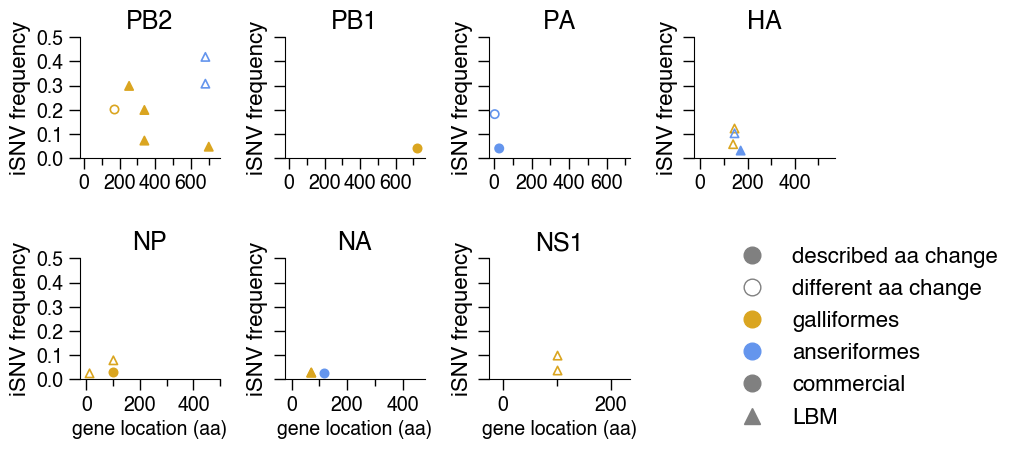

In [12]:
##gonna try to plot these now using the functional_snvs df and color by synonymous/nonsyn

import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import numpy as np
from matplotlib.ticker import AutoMinorLocator, MultipleLocator

##filtered to nonsynonymous only 

# Define colors and markers
order_colors = {
    'galliformes': '#daa520',  # chicken
    'anseriformes': '#6495ED'  # duck
}
domstat_markers = {
    'commercial': 'o',
    'LBM': '^'
}

# Define aa_changes that get filled/closed shapes
# highlighted_aa = {'Asp701Asn', 'Lys339Thr', 'Asn71Ser', 'Lys339Thr', 'Arg100Ile', 'Asp171Asn', 'Val116Ala', 'Asp253Asn', 'Asp27Gly'}
highlighted_aa = {'Asp701Asn', 'Lys339Thr', 'Asn71Ser', 'Lys339Thr', 'Arg100Ile', 'Asp171Asn', 'Val116Ala', 'Asp253Asn', 'Asp27Gly', 'Val719Met'}

##mapping the aa change to the labels i want (which are the 1 letter AA change version)
aa_labels = {
    'Asp701Asn': 'D701N',
    'Lys339Thr': 'K339T',
    'Asn71Ser':  'N71S',
    # etc.
}

# Gene order and x-limits
gene_order = ["PB2", "PB1", "PA", "HA", "NP", "NA", "M1", "M2", "NS1", "NEP"]
gene_xlimits = {
    "PB2": (-25, 765), "PB1": (-25, 765), "PA": (-25, 725), "HA": (-25, 570),
    "NP": (-25, 500), "NA": (-25, 480), "M1": (-25, 255), "M2": (-25, 300),
    "NS1": (-25, 235), "NEP": (-25, 225)
}

# Filter genes present in data
unique_genes = [g for g in gene_order if g in nonsyn_func['gene'].values]
n_genes = len(unique_genes)

# Grid size
n_cols = 4
n_rows = int(np.ceil(n_genes / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, n_rows * 2.5), sharex=False, sharey=True)
axes = axes.flatten()

# Loop through genes
for i, gene in enumerate(unique_genes):
    ax = axes[i]
    gene_df = nonsyn_func[nonsyn_func['gene'] == gene]

    ax.set_title(gene, fontsize=18)
    ax.set_facecolor('white')
    ax.set_ylim(0, 0.5)
    ax.set_yticks(np.arange(0, 0.6, 0.1))

    # # Gene-specific x-limits
    # if gene in gene_xlimits:
    #     ax.set_xlim(gene_xlimits[gene])
    # ax.spines['top'].set_visible(False)
    # ax.spines['right'].set_visible(False)
    # ax.tick_params(axis='both', which='major', labelsize=14)
    # Loop through each gene and plot
    
for i, gene in enumerate(unique_genes):
    ax = axes[i]
    gene_df = nonsyn_func[nonsyn_func['gene'] == gene]

    ax.set_title(f'{gene}', fontsize=18)
    ax.set_facecolor('white')
    ax.set_ylim(0, 0.5)
    # ax.set_xlim(-50, 2300)
    ax.set_yticks(np.arange(0, 0.6, 0.1))
    ax.set_xticks([0, 200, 400, 600, 800])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Set x-axis limits based on gene-specific dictionary
    if gene in gene_xlimits:
        ax.set_xlim(gene_xlimits[gene])

    # X-axis only on bottom row
    if i // n_cols == n_rows - 1:
        ax.set_xlabel('gene location (aa)', fontsize=14)
    ax.set_ylabel('iSNV frequency', fontsize=16)

    # # Plot points
    # for syn_non in ['synonymous', 'nonsynonymous']:
    #     for order in ['galliformes', 'anseriformes']:
    #         subset = gene_df[(gene_df['order'] == order) & (gene_df['syn_non'] == syn_non)]
    #         if not subset.empty:
    #             ax.scatter(
    #                 x=subset['amino_acid'],
    #                 y=subset['avg_freq'],
    #                 marker=order_markers[order],
    #                 facecolors='none' if syn_non == 'synonymous' else order_colors[order],
    #                 edgecolors=order_colors[order],
    #                 alpha=0.8,
    #                 linewidth=1.2
    #             )
# Plot points now coloring by host order, shaping by domstat, same aa change vs diff will fill vs. open markers
    for order in ['galliformes', 'anseriformes']:
        for dom in domstat_markers:
            subset = gene_df[(gene_df['order'] == order) & (gene_df['domestic_status'] == dom)]
            if not subset.empty:
                # filled if aa_change is in highlighted list, else open
                # facecolors = [
                #     order_colors[order] if aa in highlighted_aa else 'none'
                #     for aa in subset['coding_region_change']
                # ]
                facecolors = [
                    order_colors[order] if aa in highlighted_aa else (0, 0, 0, 0) ##apparently this .8 might fix 2 that are showing up gray
                    for aa in subset['coding_region_change']
                ]
                ax.scatter(
                    x=subset['amino_acid'],
                    y=subset['avg_freq'],
                    marker=domstat_markers[dom],
                    facecolors=facecolors,
                    edgecolors=order_colors[order],
                    # alpha=0.8,
                    linewidth=1.2
                )
# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

# Legend
# l_syn = mlines.Line2D([], [], marker='o', markerfacecolor='None', markeredgecolor=order_colors['galliformes'],
#                       linestyle='None', markersize=12, label='galliformes, synonymous')
l_nonsyn = mlines.Line2D([], [], marker='o', markerfacecolor=order_colors['galliformes'], markeredgecolor=order_colors['galliformes'],
                         linestyle='None', markersize=12, label='galliformes')
# c_syn = mlines.Line2D([], [], marker='^', markerfacecolor='None', markeredgecolor=order_colors['anseriformes'],
#                       linestyle='None', markersize=12, label='anseriformes, synonymous')
c_nonsyn = mlines.Line2D([], [], marker='o', markerfacecolor=order_colors['anseriformes'], markeredgecolor=order_colors['anseriformes'],
                         linestyle='None', markersize=12, label='anseriformes')


# one handle per dom_stat value, shown open (default)
# dom_handles = [
#     mlines.Line2D([], [], marker=domstat_markers[dom], markerfacecolor='None',
#                   markeredgecolor='gray', linestyle='None', markersize=12, label=dom)
#     for dom in domstat_markers
# ]
# one handle showing what filled means
filled_handle = mlines.Line2D([], [], marker='o', markerfacecolor='gray',
                               markeredgecolor='gray', linestyle='None', markersize=12,
                               label='described aa change')
open_handle = mlines.Line2D([], [], marker='o', markerfacecolor='None',
                               markeredgecolor='gray', linestyle='None', markersize=12,
                               label='different aa change')
comm_handle = mlines.Line2D([], [], marker='o', markerfacecolor='gray',
                               markeredgecolor='gray', linestyle='None', markersize=12,
                               label='commercial')
lbm_handle = mlines.Line2D([], [], marker='^', markerfacecolor='gray',
                               markeredgecolor='gray', linestyle='None', markersize=12,
                               label='LBM')

fig.legend(handles=[filled_handle, open_handle, l_nonsyn, c_nonsyn, comm_handle, lbm_handle], frameon=False, fontsize=16, bbox_to_anchor=(1.05, 0.5))



# fig.legend(handles=[l_syn, l_nonsyn, c_syn, c_nonsyn],
#            frameon=False,
#            fontsize=16,
#            bbox_to_anchor=(1.1, 0.5))

fig.tight_layout(rect=[0, 0, .9, 1])

for ax in axes[:n_genes]:
    ax.minorticks_on()
    ax.xaxis.set_minor_locator(AutoMinorLocator(2))
    ax.tick_params(which='minor', length=5, width=1, color='black', bottom=True, left=False)
    ax.tick_params(which='major', length=8, width=1, color='black', bottom=True, left=True, labelsize=14)


filename = "../output_plots/functionalsnvs_order_lbm_nonsyn_"+todays_date+".pdf"
plt.savefig(filename, format='pdf', bbox_inches='tight', dpi=300)

# plt.savefig('../../seq/analysis/figures/2026-02-20-allsnvs-comm-anser-gal.pdf', format='pdf')
plt.show()


In [165]:
dupes = nonsyn_func.groupby(['gene', 'amino_acid', 'avg_freq']).filter(lambda x: len(x) > 1)
print(dupes[['gene', 'amino_acid', 'coding_region_change', 'domestic_status', 'order']])

Empty DataFrame
Columns: [gene, amino_acid, coding_region_change, domestic_status, order]
Index: []


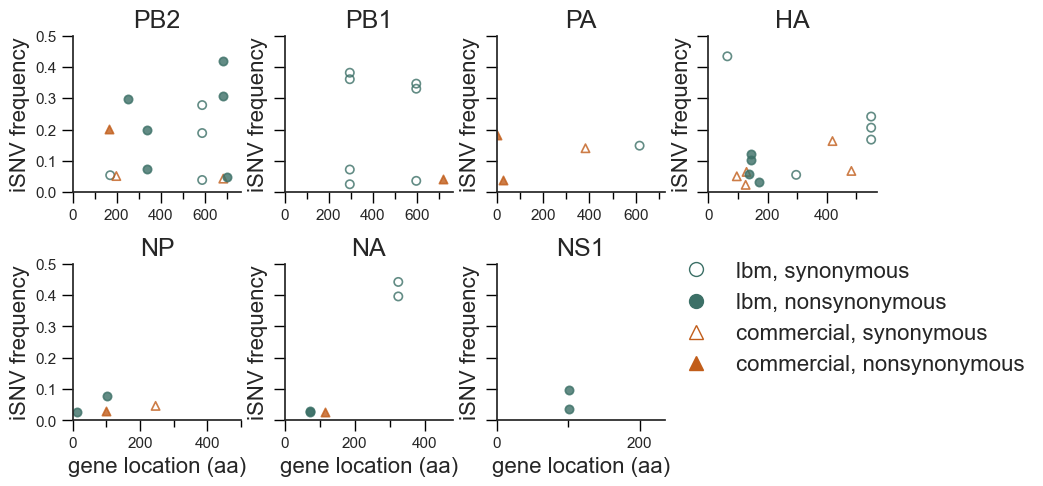

In [378]:
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import numpy as np
from matplotlib.ticker import AutoMinorLocator, MultipleLocator


# Define colors
lbm_clr = '#3C7067'
comm_clr = '#C15D1A'

# Define your sample_colors dictionary
# This must map each sample_ID to either wild_clr or comm_clr
sample_colors = {
    sample: lbm_clr if "lbm" in sample else comm_clr
    for sample in shared_vars['sample'].unique()
}
########
# Define the order you want for genes
gene_order = ["PB2", "PB1", "PA", "HA", "NP", "NA", "M1", "M2", "NS1", "NEP"]  # replace with your desired order

# Example: map each gene to (xmin, xmax)
gene_xlimits = {
    "PB2": (0, 765), "PB1": (0, 765), "PA": (0, 725), "HA": (0, 570),
    "NP": (0, 500), "NA": (0, 480), "M1": (0, 255), "M2": (0, 300),
    "NS1": (0, 235), "NEP": (0, 225)
}

# Filter out genes that aren't in your data (optional)
unique_genes = [g for g in gene_order if g in functional_snvs['gene'].values]
n_genes = len(unique_genes)
#######
# shared_vars['gene'] = shared_vars['gene'].fillna('NA')  # Only if actual NaNs exist
# # Get unique genes
# unique_genes = shared_vars['gene'].dropna().unique()
# n_genes = len(unique_genes)

# Grid size based on number of genes
n_cols = 4
n_rows = int(np.ceil(n_genes / n_cols))

# Create subplots
# fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 2.5), sharex=False, sharey=True)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, n_rows * 2.5), sharex=False, sharey=True)

axes = axes.flatten()

# Loop through each gene and plot
for i, gene in enumerate(unique_genes):
    ax = axes[i]
    gene_df = functional_snvs[functional_snvs['gene'] == gene]

    ax.set_title(f'{gene}', fontsize=18)
    ax.set_facecolor('white')
    ax.set_ylim(0, 0.5)
    # ax.set_xlim(-50, 2300)
    ax.set_yticks(np.arange(0, 0.6, 0.1))
    ax.set_xticks([0, 200, 400, 600, 800])
    
    # Set x-axis limits based on gene-specific dictionary
    if gene in gene_xlimits:
        ax.set_xlim(gene_xlimits[gene])
    # else:
    #     # fallback to dynamic limits if not defined
    #     xmin = gene_df['position'].min()
    #     xmax = gene_df['position'].max()
    #     pad = (xmax - xmin) * 0.05
    #     ax.set_xlim(xmin - pad, xmax + pad)
    # Gene-specific x-limits

##this makes it not a box just an x and y axis:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    # ax.tick_params(axis='both', which='major', labelsize=14)
    # Label only bottom row with x-axis
    if i // n_cols == n_rows - 1:
        ax.set_xlabel('gene location (aa)', fontsize=16)
    ax.set_ylabel('iSNV frequency', fontsize=16)

    for sample_ID, color in sample_colors.items():
        sample_df = gene_df[gene_df['sample_ID'] == sample_ID]
        is_commercial = 'comm' in sample_ID or 'commercial' in sample_ID.lower()  # adjust this logic as needed
        marker_shape = '^' if is_commercial else 'o'  # triangle for commercial, circle for wild
    
    for syn_non in ['synonymous', 'nonsynonymous']:
        for group, clr, marker in [
            ('LBM', lbm_clr, 'o'),
            ('commercial', comm_clr, '^')
        ]:
            subset = gene_df[
                (gene_df['color'].str.contains(group)) &
                (gene_df['syn_non'] == syn_non)
            ]
            if not subset.empty:
                ax.scatter(
                    x=subset['amino_acid'],
                    y=subset['avg_freq'],
                    marker=marker,
                    facecolors='none' if syn_non == 'synonymous' else clr,
                    edgecolors=clr,
                    alpha=0.8,
                    linewidth=1.2
                )


    
# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

# Legend
l_syn = mlines.Line2D([], [], marker='o', markerfacecolor='None', markeredgecolor=lbm_clr, linestyle='None', markersize=10, label='lbm, synonymous')
l_nonsyn = mlines.Line2D([], [], marker='o', markerfacecolor=lbm_clr, markeredgecolor=lbm_clr, linestyle='None', markersize=10, label='lbm, nonsynonymous')
c_syn = mlines.Line2D([], [], marker='^', markerfacecolor='None', markeredgecolor=comm_clr, linestyle='None', markersize=10, label='commercial, synonymous')
c_nonsyn = mlines.Line2D([], [], marker='^', markerfacecolor=comm_clr, markeredgecolor=comm_clr, linestyle='None', markersize=10, label='commercial, nonsynonymous')

fig.legend(
    handles=[l_syn, l_nonsyn, c_syn, c_nonsyn],
    frameon=False,
    fontsize=16,
    # loc='upper right',
           bbox_to_anchor=(1.05, 0.5))

fig.tight_layout(rect=[0, 0, .9, 1])

for ax in axes[:n_genes]:
    ax.minorticks_on()
    ax.xaxis.set_minor_locator(AutoMinorLocator(2))
    ax.tick_params(which='minor', length=5, width=1, color='black', bottom=True, left=False)
    ax.tick_params(which='major', length=8, width=1, color='black', bottom=True, left=True)

filename = "../output_plots/functionalsnvs_lbmcom_"+todays_date+".pdf"
plt.savefig(filename, format='pdf', bbox_inches='tight', dpi=300)

plt.show()


In [178]:
filename = '../output_dfs/'+todays_date+'functionalSNVS-allrepshared-2pct-allcom-fulldb.tsv'
functional_snvs.to_csv(filename, sep='\t', index=False)

In [177]:
# pwd
todays_date

'2026-05-21'

In [131]:
# shared_vars_dedupe.info()

NameError: name 'shared_vars_dedupe' is not defined

In [313]:
# shared_vars.to_csv('2025_01_23_lowfreq_vars_repshared_all_data_bothreps.tsv', sep='\t', index=False)

In [354]:
shared_vars['sample_ID'].unique()

array(['c_com5', 'c_com6', 'c_lbm10', 'c_lbm11', 'c_lbm1', 'c_lbm2',
       'c_lbm3', 'c_lbm5', 'c_lbm6', 'c_lbm7', 'c_lbm8', 'c_lbm9',
       'cb_com1', 'cb_com2', 'cb_com3', 'cb_com4', 'ckr_com1', 'ckr_com2',
       'ckr_com3', 'd_com1', 'd_com2', 'd_com3', 'd_lbm1', 'd_lbm2',
       'd_lbm3', 'd_lbm4', 'g_com1', 'g_com2', 'g_lbm1', 'gn_lbm1',
       'kc_com3', 'kc_com4', 'kc_com5', 'kc_com6', 'kc_com7', 'kc_com8'],
      dtype=object)

In [35]:
# ##updating some figures using shared vars input (6/4/2025)
# merged

,sample_ID,count,order_domstat
0,be_w1,1,acciptriformes_wild
1,be_w3,14,acciptriformes_wild
2,blvu_chester,29,acciptriformes_wild
3,bv_w1,4,acciptriformes_wild
4,bv_w2,12,acciptriformes_wild
5,bv_w3,17,acciptriformes_wild
6,bv_w4,16,acciptriformes_wild
7,bv_w6,18,acciptriformes_wild
8,bv_w7,8,acciptriformes_wild
9,bv_w8,16,acciptriformes_wild


In [355]:
shared_vars['order_domstat'].unique()

array(['galliformes_commercial', 'galliformes_LBM',
       'anseriformes_commercial', 'anseriformes_LBM'], dtype=object)

In [1]:
# ##importing shared vars to remake this plot and sub_dfs
# import pandas as pd
# shared_vars = pd.read_csv('../seq/analysis/output_dfs/2025_06_17_repshared_SNVs_allsamples.tsv', sep='\t')

/var/folders/8h/zkgpnzwj7f9d82wldp_d4h_w0000gs/T/ipykernel_90265/2583906191.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_means = merged.groupby('order_domstat')['count'].mean().reset_index()
/Users/asjaeger/miniconda3/envs/aj_env/lib/python3.12/site-packages/seaborn/relational.py:438: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  points = ax.scatter(x=x, y=y, **kws)


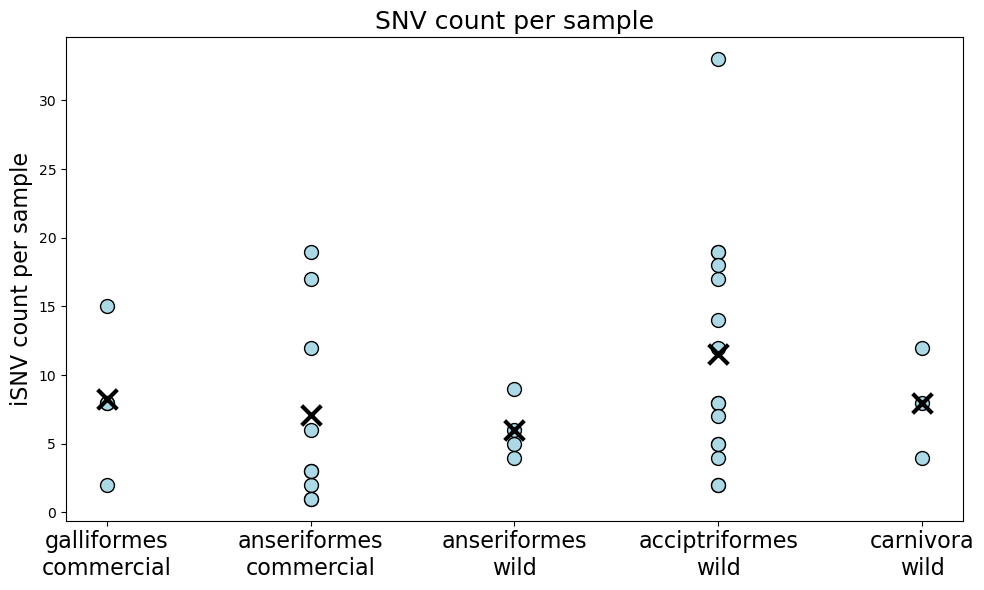

In [33]:
# import pandas as pd
# import seaborn as sns
# import matplotlib.pyplot as plt

# order = ['galliformes_commercial', 'anseriformes_commercial', 'anseriformes_wild', 'acciptriformes_wild', 'carnivora_wild']


# # Step 1: Count number of rows per sample_id
# sample_counts = shared_vars.groupby('sample_ID').size().reset_index(name='count')

# # Step 2: Merge with order_domstat (assuming each sample_id has a unique order_domstat)
# sample_info = shared_vars[['sample_ID', 'order_domstat']].drop_duplicates()
# merged = pd.merge(sample_counts, sample_info, on='sample_ID')
# merged['order_domstat'] = pd.Categorical(merged['order_domstat'], categories=order, ordered=True)
# group_means = merged.groupby('order_domstat')['count'].mean().reset_index()

# plt.figure(figsize=(10, 6))


# # sns.pointplot(data=group_means, x='order_domstat', y='count', color='black', s=15, zorder=2)
# sns.stripplot(data=merged, x='order_domstat', y='count', color='lightblue', s=10, edgecolor='k', linewidth=1, jitter=False, zorder=1)
# sns.scatterplot(data=group_means, x='order_domstat', y='count', color='black', marker='x',s=200, edgecolor='k', linewidth=3, zorder=2)


# new_labels = [label.replace('_', '\n') for label in order]
# plt.xticks(ticks=range(len(order)), labels=new_labels)

# # Optional formatting
# plt.title('SNV count per sample', fontsize=18)
# plt.ylabel('iSNV count per sample', fontsize=16)
# plt.xlabel('')
# plt.xticks(fontsize=16)
# plt.tight_layout()

# # plt.savefig('../hpai_PA/seq/analysis/figures/2025_06_05_allsamps_snv_count_sample_domstat.pdf', format='pdf')

# plt.show()


In [3]:
# import statsmodels.api as sm
# from statsmodels.formula.api import ols
# from statsmodels.stats.multicomp import pairwise_tukeyhsd

# # One-way ANOVA
# model = ols('count ~ C(order_domstat)', data=merged).fit()
# anova_table = sm.stats.anova_lm(model, typ=2)

# print("ANOVA Results:")
# print(anova_table)

# # Tukey HSD post-hoc test
# tukey = pairwise_tukeyhsd(endog=merged['count'],
#                           groups=merged['order_domstat'],
#                           alpha=0.05)

# print("\nTukey HSD Results:")
# print(tukey.summary())


ANOVA Results:
                       sum_sq    df         F    PR(>F)
C(order_domstat)   169.370635   4.0  0.819867  0.522758
Residual          1549.372222  30.0       NaN       NaN

Tukey HSD Results:
                  Multiple Comparison of Means - Tukey HSD, FWER=0.05                  
         group1                  group2         meandiff p-adj   lower    upper  reject
---------------------------------------------------------------------------------------
    acciptriformes_wild anseriformes_commercial  -4.4222 0.5956 -13.2113  4.3669  False
    acciptriformes_wild       anseriformes_wild  -5.5333 0.6519 -17.2636  6.1969  False
    acciptriformes_wild          carnivora_wild  -3.5333 0.9352  -16.717  9.6503  False
    acciptriformes_wild  galliformes_commercial  -3.2833 0.9249 -15.0136  8.4469  False
anseriformes_commercial       anseriformes_wild  -1.1111  0.999 -13.6375 11.4153  False
anseriformes_commercial          carnivora_wild   0.8889 0.9997 -13.0079 14.7857  False
anser

In [35]:
# merged.to_csv('../seq/analysis/output_dfs/2025-11-18-snvs-per-sample.tsv', sep='\t', index=False)

In [6]:
# # Make new column max_count = count
# merged['max_count'] = merged['count']

# # Now create min_count based on group
# merged['min_count'] = merged['max_count']  # default

# merged.loc[merged['order_domstat'] == 'galliformes_commercial', 'min_count'] = merged['max_count'] / 10
# merged.loc[merged['order_domstat'] == 'anseriformes_commercial', 'min_count'] = merged['max_count'] / 5
# merged

/var/folders/8h/zkgpnzwj7f9d82wldp_d4h_w0000gs/T/ipykernel_90265/807894201.py:7: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[1.5 0.8 0.8 0.2]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  merged.loc[merged['order_domstat'] == 'galliformes_commercial', 'min_count'] = merged['max_count'] / 10


,sample_ID,count,order_domstat,max_count,min_count
0,be_w1,2,acciptriformes_wild,2,2.0
1,be_w3,14,acciptriformes_wild,14,14.0
2,blvu_chester,33,acciptriformes_wild,33,33.0
3,bv_w1,5,acciptriformes_wild,5,5.0
4,bv_w2,12,acciptriformes_wild,12,12.0
5,bv_w3,19,acciptriformes_wild,19,19.0
6,bv_w4,17,acciptriformes_wild,17,17.0
7,bv_w6,19,acciptriformes_wild,19,19.0
8,bv_w7,8,acciptriformes_wild,8,8.0
9,bv_w8,18,acciptriformes_wild,18,18.0


In [17]:
# merged['avg'] = (merged['max_count'] + merged['min_count']) / 2
# merged['error'] = (merged['max_count'] - merged['min_count']) / 2
# merged

,sample_ID,count,order_domstat,max_count,min_count,avg,error
0,be_w1,2,acciptriformes_wild,2,2.0,2.00,0.00
1,be_w3,14,acciptriformes_wild,14,14.0,14.00,0.00
2,blvu_chester,33,acciptriformes_wild,33,33.0,33.00,0.00
3,bv_w1,5,acciptriformes_wild,5,5.0,5.00,0.00
4,bv_w2,12,acciptriformes_wild,12,12.0,12.00,0.00
5,bv_w3,19,acciptriformes_wild,19,19.0,19.00,0.00
6,bv_w4,17,acciptriformes_wild,17,17.0,17.00,0.00
7,bv_w6,19,acciptriformes_wild,19,19.0,19.00,0.00
8,bv_w7,8,acciptriformes_wild,8,8.0,8.00,0.00
9,bv_w8,18,acciptriformes_wild,18,18.0,18.00,0.00


In [18]:
# group_means = merged.groupby('order_domstat')['avg'].mean().reset_index()
# group_means

/var/folders/8h/zkgpnzwj7f9d82wldp_d4h_w0000gs/T/ipykernel_90265/1491387147.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_means = merged.groupby('order_domstat')['avg'].mean().reset_index()


,order_domstat,avg
0,galliformes_commercial,4.537500
1,anseriformes_commercial,4.266667
2,anseriformes_wild,6.000000
3,acciptriformes_wild,11.533333
4,carnivora_wild,8.000000


/var/folders/8h/zkgpnzwj7f9d82wldp_d4h_w0000gs/T/ipykernel_90265/3879944448.py:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_means = merged.groupby('order_domstat')['avg'].mean().reset_index()
/var/folders/8h/zkgpnzwj7f9d82wldp_d4h_w0000gs/T/ipykernel_90265/3879944448.py:35: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(


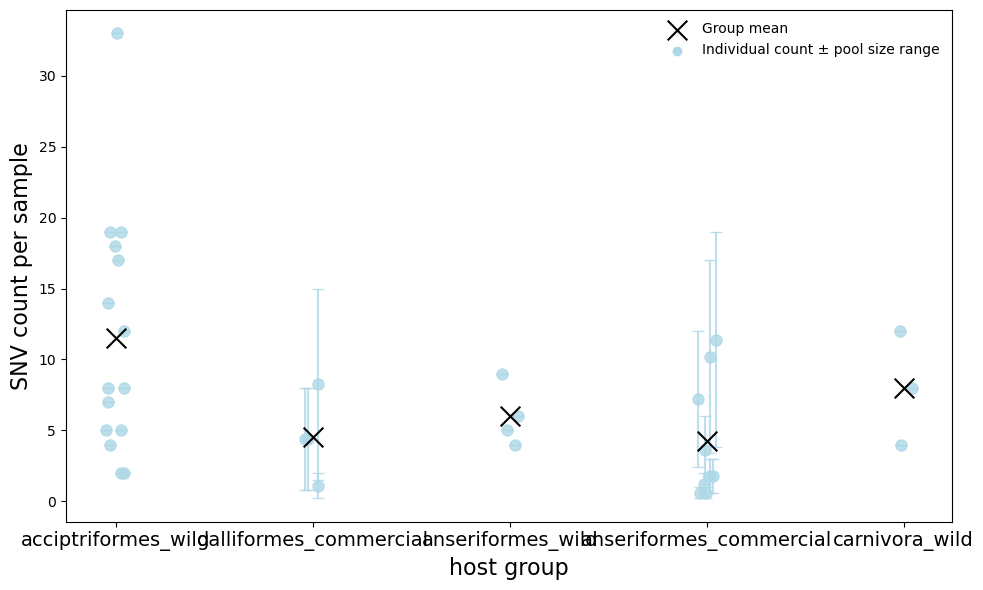

In [26]:
# import matplotlib.pyplot as plt
# import numpy as np

# def plot_avg_with_error_and_group_mean(df):

#     groups = merged['order_domstat'].unique()
#     group_to_x = {g: i for i, g in enumerate(groups)}

#     fig, ax = plt.subplots(figsize=(10, 6))

#     # Plot each individual's avg with error bar
#     for _, row in merged.iterrows():

#         x = group_to_x[row['order_domstat']]
#         jitter = np.random.uniform(-0.05, 0.05)

#         ax.errorbar(
#             x + jitter,
#             row['avg'],
#             yerr=row['error'],
#             fmt='o',
#             color='lightblue',
#             ecolor='lightblue',
#             elinewidth=1.5,
#             capsize=4,
#             markersize=8,
#             alpha=0.8
#         )

#     # Group means
#     group_means = merged.groupby('order_domstat')['avg'].mean().reset_index()

#     for _, row in group_means.iterrows():
#         x = group_to_x[row['order_domstat']]
#         ax.scatter(
#             x, row['avg'],
#             color='black',
#             s=200,
#             marker='x',   # diamond
#             edgecolor='black',
#             zorder=5,
#             label="Group mean" if _ == 0 else None
#         )

#     # X-axis labels
#     ax.set_xticks(range(len(groups)))
#     ax.set_xticklabels(groups, fontsize=14)
#     ax.set_xlabel("host group", fontsize=16)
    
#     ax.set_ylabel("SNV count per sample", fontsize=16)

#     # Legend (build from dummy handles)
#     ax.scatter([], [], color='lightblue', label='Individual count ± pool size range')
#     # ax.scatter([], [], color='red', marker='D', s=150, label='Group mean')
#     ax.legend(frameon=False)

#     plt.tight_layout()
#     plt.show()
# plot_avg_with_error_and_group_mean(merged)


In [27]:
# ##i want to plot the points to be at the sample counts, but the errors to be around the averages so it shows the range for the pooled samps
# merged['avg'] = (merged['max_count'] + merged['min_count']) / 2
# merged['lower_err'] = merged['avg'] - merged['min_count']
# merged['upper_err'] = merged['max_count'] - merged['avg']
# merged

,sample_ID,count,order_domstat,max_count,min_count,avg,error,lower_err,upper_err
0,be_w1,2,acciptriformes_wild,2,2.0,2.00,0.00,0.00,0.00
1,be_w3,14,acciptriformes_wild,14,14.0,14.00,0.00,0.00,0.00
2,blvu_chester,33,acciptriformes_wild,33,33.0,33.00,0.00,0.00,0.00
3,bv_w1,5,acciptriformes_wild,5,5.0,5.00,0.00,0.00,0.00
4,bv_w2,12,acciptriformes_wild,12,12.0,12.00,0.00,0.00,0.00
5,bv_w3,19,acciptriformes_wild,19,19.0,19.00,0.00,0.00,0.00
6,bv_w4,17,acciptriformes_wild,17,17.0,17.00,0.00,0.00,0.00
7,bv_w6,19,acciptriformes_wild,19,19.0,19.00,0.00,0.00,0.00
8,bv_w7,8,acciptriformes_wild,8,8.0,8.00,0.00,0.00,0.00
9,bv_w8,18,acciptriformes_wild,18,18.0,18.00,0.00,0.00,0.00


/var/folders/8h/zkgpnzwj7f9d82wldp_d4h_w0000gs/T/ipykernel_90265/2784228065.py:33: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_means = merged.groupby('order_domstat')['avg'].mean().reset_index()
/var/folders/8h/zkgpnzwj7f9d82wldp_d4h_w0000gs/T/ipykernel_90265/2784228065.py:36: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(


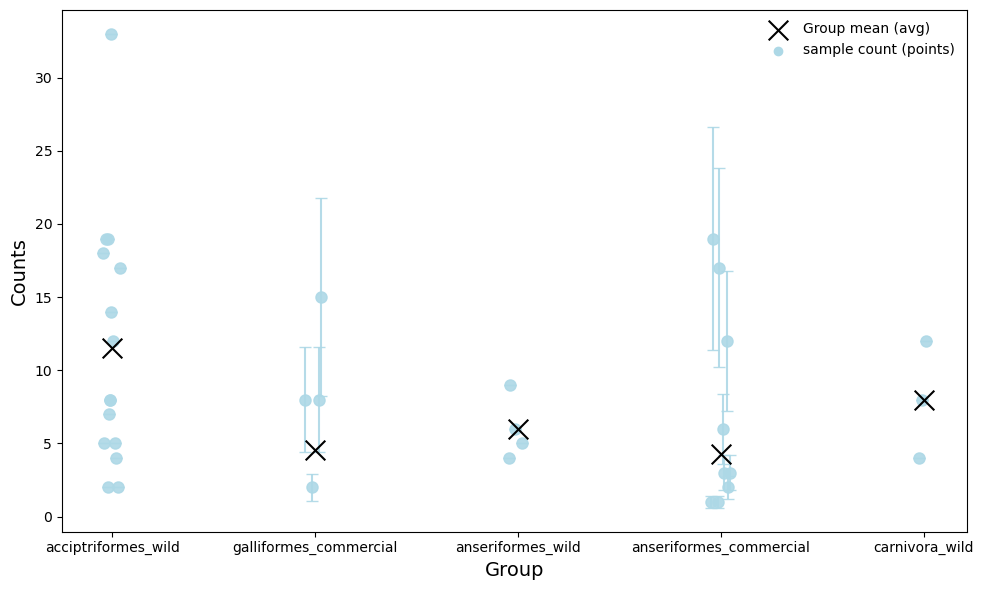

In [32]:
# def plot_min_with_avg_error(df):

#     groups = merged['order_domstat'].unique()
#     group_to_x = {g: i for i, g in enumerate(groups)}

#     fig, ax = plt.subplots(figsize=(10, 6))

#     for _, row in df.iterrows():

#         x = group_to_x[row['order_domstat']]
#         jitter = np.random.uniform(-0.05, 0.05)

#         # POINT plotted at min_count
#         y_point = row['max_count']

#         # ERROR BAR centered at avg
#         yerr = [[row['lower_err']], [row['upper_err']]]

#         ax.errorbar(
#             x + jitter,
#             y_point,
#             yerr=yerr,
#             fmt='o',
#             color='lightblue',
#             ecolor='lightblue',
#             elinewidth=1.5,
#             capsize=4,
#             markersize=8,
#             alpha=0.9
#         )

#     # --- Add group means based on avg ---
#     group_means = merged.groupby('order_domstat')['avg'].mean().reset_index()
#     for _, row in group_means.iterrows():
#         x = group_to_x[row['order_domstat']]
#         ax.scatter(
#             x, row['avg'],
#             color='black',
#             s=200,
#             marker='x',
#             edgecolor='black',
#             label='Group mean (avg)' if _ == 0 else None,
#             zorder=5
#         )

#     ax.set_xticks(range(len(groups)))
#     ax.set_xticklabels(groups)
#     ax.set_xlabel("Group", fontsize=14)
#     ax.set_ylabel("Counts", fontsize=14)

#     ax.scatter([], [], color='lightblue', label='sample count (points)')
#     # ax.scatter([], [], color='black', marker='x', label='Group mean (avg)')
#     ax.legend(frameon=False)

#     plt.tight_layout()
#     plt.show()
# plot_min_with_avg_error(merged)